# **Libraries**

In [ ]:
%%capture

!pip install shap
!pip install optuna
!pip install cmaes

In [ ]:
seed = 7
import pandas as pd
import numpy as np

# Graphs
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix

# Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Optuna
import optuna
from optuna.samplers import RandomSampler, TPESampler, CmaEsSampler
from optuna.visualization import plot_optimization_history

The 'functions_pred_cruzada' file contains the functions that will be used to select, preprocess, train and validate the machine learning models.

In [ ]:
!gdown 1uVoArwRTJmvbyFLyFniwFvWGHMfiNIWO --quiet

from functions_pred_cruzada import *

# **Data**

In [ ]:
%%capture

!gdown 129xV7F8XXr_4PqRtcR-GV7unEgNrL6qW --quiet # Train - Digestive System
!gdown 13aJGpxw_tAhT-44yuD-mRKjDsJcHwynU --quiet # Test - Digestive System

In [ ]:
# Load the training dataset from CSV
df_sist_dig_treino = pd.read_csv('/content/sist_dig_treino.csv')

# Print the shape of the DataFrame (number of rows and columns)
print(df_sist_dig_treino.shape)

# Display the first three rows of the training dataset
df_sist_dig_treino.head(3)

(97924, 25)


,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,EC,CIRURGIA,RADIO,QUIMIO,HORMONIO,...,ANODIAG,DRS,RRAS,IBGEATEN,HABILIT2,ESCOLARI_preench,IBGE_idem_IBGEATEN,presenca_rec,TOPOGRUP,sobrevida_3anos
0,-0.313399,-0.486452,0.889193,-0.855087,-0.933936,-0.777605,-1.053163,-1.057999,-0.846260,-0.052318,...,-0.702199,1.584652,0.669012,0.801956,-1.240717,0.520496,1.131402,2.122043,Boca,1
1,-0.775695,1.028664,0.875829,1.343451,-1.043802,1.054160,0.600930,-0.567847,-1.356322,-0.078540,...,-0.209650,-0.933152,-0.753735,0.794255,-0.968850,0.154944,0.964441,-0.475073,Colorretal,0
2,-0.815064,-0.486452,0.918482,-0.855087,1.070737,1.139022,-1.053163,0.945180,1.181669,-0.052318,...,0.732225,-0.949295,-0.763297,0.830259,0.464651,-1.748979,1.131402,-0.471244,Boca,0


In [ ]:
# Load the testing dataset from CSV
df_sist_dig_teste = pd.read_csv('/content/sist_dig_teste.csv')

# Print the shape of the DataFrame (number of rows and columns)
print(df_sist_dig_teste.shape)

# Display the first three rows of the testing dataset
df_sist_dig_teste.head(3)

(32645, 25)


,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,EC,CIRURGIA,RADIO,QUIMIO,HORMONIO,...,ANODIAG,DRS,RRAS,IBGEATEN,HABILIT2,ESCOLARI_preench,IBGE_idem_IBGEATEN,presenca_rec,TOPOGRUP,sobrevida_3anos
0,0.214492,1.028664,0.916336,1.343451,0.958036,1.054160,-1.664088,-0.567847,0.737288,-0.078540,...,-1.353129,-0.392930,-0.518012,0.692936,-0.968850,-0.870779,-1.036870,-0.475073,Colorretal,0
1,0.765536,-0.438574,0.929651,-0.867646,0.756823,0.008932,-0.545489,-1.026325,-1.178694,-0.053606,...,1.263874,-0.949246,-0.790110,0.836351,-1.175867,-1.674465,1.112286,-0.399978,Esôfago,0
2,0.773540,-0.486452,0.545758,1.148151,1.070737,-0.298449,-1.053163,0.945180,1.181669,-0.052318,...,-1.598714,0.679671,1.146449,-0.486755,-1.240717,-0.614241,-0.883859,-0.471244,Boca,1


In [ ]:
# Topographies in training dataset
df_sist_dig_treino.TOPOGRUP.value_counts()

,count
TOPOGRUP,
Colorretal,42083
Estômago,20827
Boca,17951
Esôfago,10470
Orofaringe,3691
Ânus,1707
Delgado,1195


In [ ]:
# Define the cancer type groups for different training/testing subsets
group1 = ['Boca', 'Estômago', 'Colorretal']         # Group 1: Oral Cavity, Stomach, Colorectal
group2 = ['Esôfago', 'Boca', 'Estômago']            # Group 2: Esophagus, Oral Cavity, Stomach
group3 = ['Estômago', 'Colorretal']                 # Group 3: Stomach, Colorectal
group4 = ['Delgado', 'Boca', 'Estômago']            # Group 4: Small Intestine, Oral Cavity, Stomach

# Create training and testing sets for each defined group by filtering on 'TOPOGRUP'
df1_treino = df_sist_dig_treino[df_sist_dig_treino.TOPOGRUP.isin(group1)]  # Training subset for Group 1
df1_teste  = df_sist_dig_teste[df_sist_dig_teste.TOPOGRUP.isin(group1)]    # Testing  subset for Group 1

df2_treino = df_sist_dig_treino[df_sist_dig_treino.TOPOGRUP.isin(group2)]  # Training subset for Group 2
df2_teste  = df_sist_dig_teste[df_sist_dig_teste.TOPOGRUP.isin(group2)]    # Testing  subset for Group 2

df3_treino = df_sist_dig_treino[df_sist_dig_treino.TOPOGRUP.isin(group3)]  # Training subset for Group 3
df3_teste  = df_sist_dig_teste[df_sist_dig_teste.TOPOGRUP.isin(group3)]    # Testing  subset for Group 3

df4_treino = df_sist_dig_treino[df_sist_dig_treino.TOPOGRUP.isin(group4)]  # Training subset for Group 4
df4_teste  = df_sist_dig_teste[df_sist_dig_teste.TOPOGRUP.isin(group4)]    # Testing  subset for Group 4

# Print the shapes of each training and testing subset to verify the number of samples and features
df1_treino.shape, df1_teste.shape, df2_treino.shape, df2_teste.shape, df3_treino.shape, df3_teste.shape, df4_treino.shape, df4_teste.shape

((80861, 25),
 (26955, 25),
 (49248, 25),
 (16418, 25),
 (62910, 25),
 (20971, 25),
 (39973, 25),
 (13326, 25))

In [ ]:
# Create separate test DataFrames for each cancer type by filtering on the 'TOPOGRUP' column
boca_teste = df_sist_dig_teste[df_sist_dig_teste.TOPOGRUP == 'Boca']  # Oral Cavity cancer test set
eso_teste  = df_sist_dig_teste[df_sist_dig_teste.TOPOGRUP == 'Esôfago']  # Esophagus cancer test set
esto_teste = df_sist_dig_teste[df_sist_dig_teste.TOPOGRUP == 'Estômago']  # Stomach cancer test set
delg_teste = df_sist_dig_teste[df_sist_dig_teste.TOPOGRUP == 'Delgado']  # Small Intestine cancer test set
colo_teste = df_sist_dig_teste[df_sist_dig_teste.TOPOGRUP == 'Colorretal']  # Colorectal cancer test set

# Print the shape (rows, columns) of each filtered test DataFrame
boca_teste.shape, eso_teste.shape, esto_teste.shape, delg_teste.shape, colo_teste.shape

((5984, 25), (3491, 25), (6943, 25), (399, 25), (14028, 25))

In [ ]:
from sklearn.utils import shuffle

# Shuffle each pair of training and testing DataFrames to randomize the sample order
# while ensuring reproducibility with a fixed random seed.

df1_treino = shuffle(df1_treino, random_state=seed)  # Shuffle first training set
df1_teste  = shuffle(df1_teste,  random_state=seed)  # Shuffle first test set

df2_treino = shuffle(df2_treino, random_state=seed)  # Shuffle second training set
df2_teste  = shuffle(df2_teste,  random_state=seed)  # Shuffle second test set

df3_treino = shuffle(df3_treino, random_state=seed)  # Shuffle third training set
df3_teste  = shuffle(df3_teste,  random_state=seed)  # Shuffle third test set

df4_treino = shuffle(df4_treino, random_state=seed)  # Shuffle fourth training set
df4_teste  = shuffle(df4_teste,  random_state=seed)  # Shuffle fourth test set

# **Oral Cavity with Stomach e Colorectal**

In [ ]:
# Topographies for group 1
df1_treino.TOPOGRUP.value_counts()

TOPOGRUP
Colorretal    42083
Estômago      20827
Boca          17951
Name: count, dtype: int64

In [ ]:
# Missing values
df1_treino.isna().sum().sort_values(ascending=False)

IDADE                 0
CONSDIAG              0
TOPOGRUP              0
presenca_rec          0
IBGE_idem_IBGEATEN    0
ESCOLARI_preench      0
HABILIT2              0
IBGEATEN              0
RRAS                  0
DRS                   0
ANODIAG               0
DIAGTRAT              0
OUTROS                0
SEXO                  0
IMUNO                 0
TMO                   0
HORMONIO              0
QUIMIO                0
RADIO                 0
CIRURGIA              0
EC                    0
DIAGPREV              0
CATEATEND             0
IBGE                  0
sobrevida_3anos       0
dtype: int64

In [ ]:
# Count the number of patients in each class of the target variable 'sobrevida_ano3'
df1_treino.sobrevida_3anos.value_counts()

sobrevida_3anos
0    44576
1    36285
Name: count, dtype: int64

## **Preprocessing**

In [ ]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Initialize an OrdinalEncoder to convert categorical 'TOPOGRUP' values to integer codes,
# and assign -1 to any categories not seen during fitting
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit the encoder on the training set and transform its 'TOPOGRUP' column
df1_treino['TOPOGRUP'] = oe.fit_transform(df1_treino[['TOPOGRUP']])

# Transform the test set's 'TOPOGRUP' column using the already-fitted encoder
df1_teste['TOPOGRUP'] = oe.transform(df1_teste[['TOPOGRUP']])

# Initialize a StandardScaler to standardize the feature (zero mean, unit variance)
ss = StandardScaler()

# Fit the scaler on the training set's encoded 'TOPOGRUP' values and apply the transformation
df1_treino['TOPOGRUP'] = ss.fit_transform(df1_treino[['TOPOGRUP']])

# Apply the same scaling transformation to the test set's encoded 'TOPOGRUP' values
df1_teste['TOPOGRUP'] = ss.transform(df1_teste[['TOPOGRUP']])

In [ ]:
# Define the column to drop (the target variable)
list_drop = ['sobrevida_3anos']

# Prepare training features and target
X_train = df1_treino.drop(columns=list_drop).copy()  # Features for the training set
y_train = df1_treino.sobrevida_3anos.copy()          # Target variable for the training set

# Prepare test features and target
X_test = df1_teste.drop(columns=list_drop).copy()    # Features for the test set
y_test = df1_teste.sobrevida_3anos.copy()            # Target variable for the test set

# Display the shapes of the training and test splits
X_train.shape, y_train.shape, X_test.shape, y_test.shape

In [ ]:
# Feature columns
feat_cols = X_train.columns
feat_cols

Index(['IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV', 'EC', 'CIRURGIA',
       'RADIO', 'QUIMIO', 'HORMONIO', 'TMO', 'IMUNO', 'OUTROS', 'CONSDIAG',
       'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'IBGEATEN', 'HABILIT2',
       'ESCOLARI_preench', 'IBGE_idem_IBGEATEN', 'presenca_rec', 'TOPOGRUP'],
      dtype='object')

## **Machine learning models**

### **XGBoost**


#### **Base model**

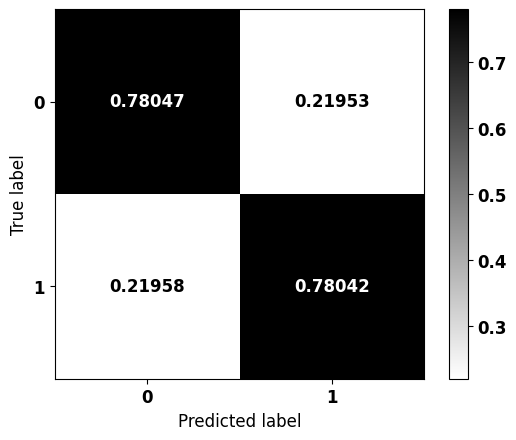


              precision    recall  f1-score   support

           0    0.81365   0.78047   0.79672     14859
           1    0.74319   0.78042   0.76135     12096

    accuracy                        0.78045     26955
   macro avg    0.77842   0.78045   0.77903     26955
weighted avg    0.78203   0.78045   0.78085     26955



In [ ]:
# Create and train the XGBoost classifier
xgb = XGBClassifier(max_depth=5,            # Set maximum tree depth to 5
                    scale_pos_weight=1.075, # Balance positive and negative classes
                    random_state=seed)      # Ensure reproducibility with a fixed random seed

xgb.fit(X_train, y_train)  # Train the model on the training data

# Plot the confusion matrix to evaluate model performance on the test set
plot_confusion_matrix(xgb, X_test, y_test)

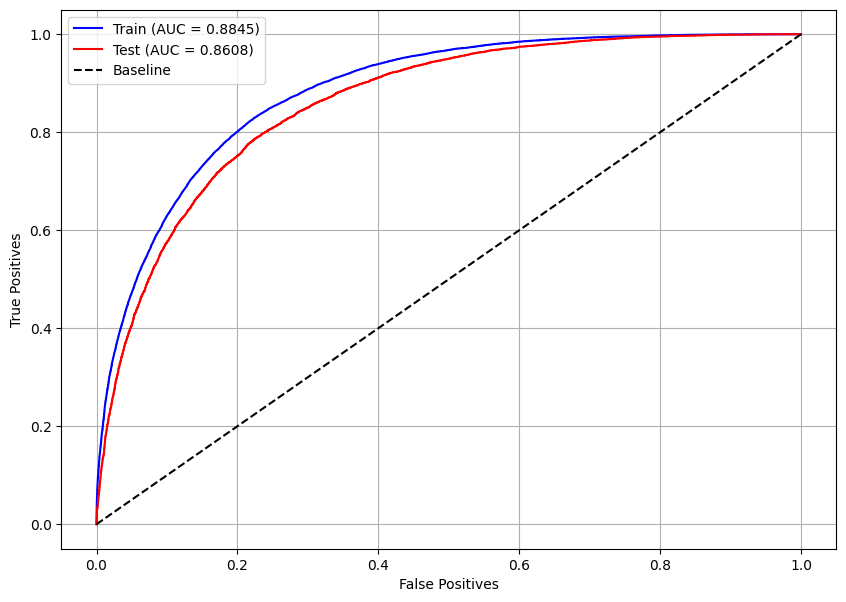

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb, X_train, X_test, y_train, y_test)

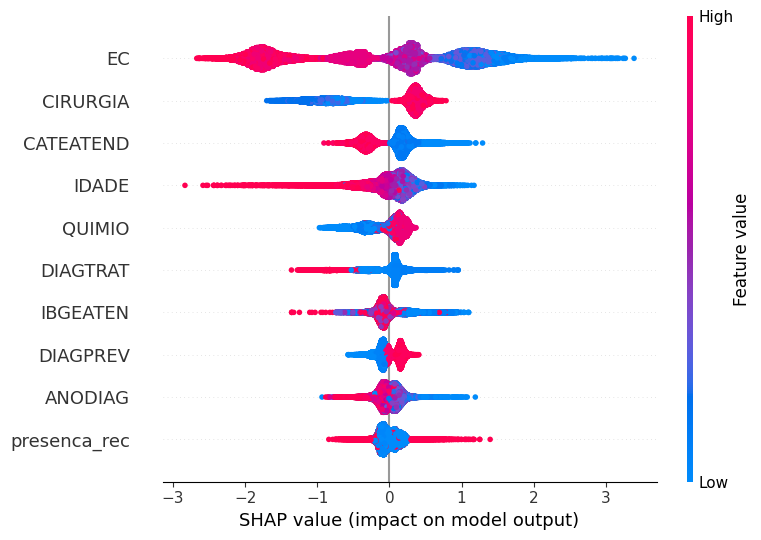

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(xgb, X_train, feat_cols)

#### **Optuna**

In [ ]:
# Create stratified folds to maintain class proportions during cross-validation
skf = StratifiedKFold(10, shuffle=True, random_state=seed)

# Define the objective function for hyperparameter optimization
def objective(trial):
    """
    Objective function for Optuna to optimize an XGBoost classifier.
    Returns the mean accuracy across stratified folds.
    """

    # Suggest values for hyperparameters to be optimized
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Number of boosting rounds
    max_depth = trial.suggest_int('max_depth', 3, 6)  # Maximum tree depth
    learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2, step=0.05)  # Learning rate for updates
    gamma = trial.suggest_float('gamma', 0.0, 0.3, step=0.1)  # Minimum loss reduction for tree splits
    min_child_weight = trial.suggest_int('min_child_weight', 1, 7)  # Minimum sum of instance weight in child nodes
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 0.7, step=0.1)  # Subsample ratio of features per tree

    # Initialize the XGBoost classifier with the suggested hyperparameters
    cls = XGBClassifier(n_estimators=n_estimators,
                        max_depth=max_depth,
                        learning_rate=learning_rate,
                        gamma=gamma,
                        min_child_weight=min_child_weight,
                        colsample_bytree=colsample_bytree,
                        random_state=seed,
                        n_jobs=-1)

    # Perform cross-validation and return the average accuracy
    return cross_val_score(cls, X_train, y_train,
                           cv=skf, scoring='accuracy').mean()

RandomSampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyXGB = optuna.create_study(direction='maximize', sampler=RandomSampler(seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyXGB.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyXGB.best_params

{'n_estimators': 108,
 'max_depth': 6,
 'learning_rate': 0.2,
 'gamma': 0.3,
 'min_child_weight': 5,
 'colsample_bytree': 0.3}

In [ ]:
# Generate a range of candidate scale_pos_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(1.05, 1.1, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyXGB.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['scale_pos_weight'] = i  # Update the class weight parameter

    # Initialize a new XGBoost classifier with the updated hyperparameters
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Train the model on the training set
    xgb_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = xgb_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(xgb_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

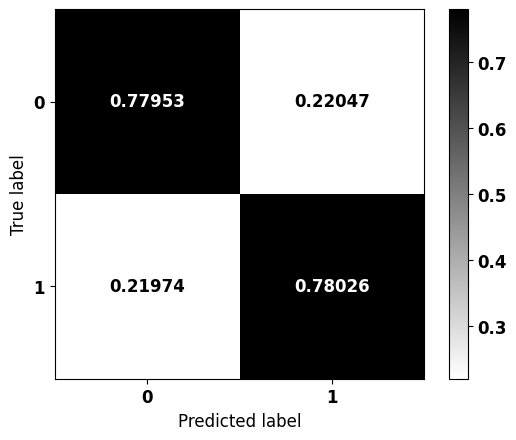


              precision    recall  f1-score   support

           0    0.81336   0.77953   0.79608     14859
           1    0.74233   0.78026   0.76082     12096

    accuracy                        0.77986     26955
   macro avg    0.77784   0.77989   0.77845     26955
weighted avg    0.78148   0.77986   0.78026     26955



In [ ]:
# Configure the final XGBoost model using the best-found hyperparameters
params = studyXGB.best_params           # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed           # Fix the random seed for reproducibility
params['scale_pos_weight'] = 1.082      # Apply the chosen class imbalance weight

# Instantiate and configure the XGBoost classifier
xgb_rand = XGBClassifier()
xgb_rand.set_params(**params)

# Train the optimized model on the training dataset
xgb_rand.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(xgb_rand, X_test, y_test)

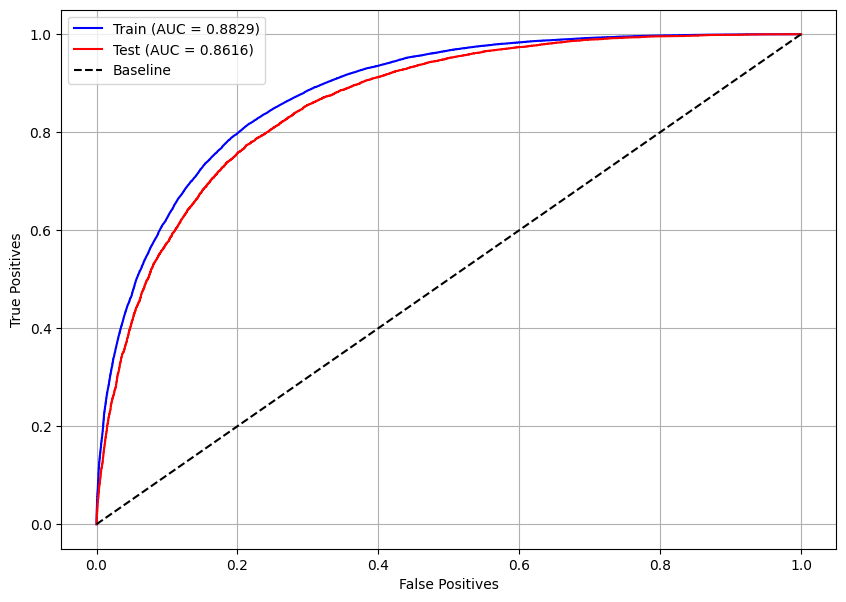

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb_rand, X_train, X_test, y_train, y_test)

TPESampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyXGB = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyXGB.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyXGB.best_params

{'n_estimators': 105,
 'max_depth': 6,
 'learning_rate': 0.15000000000000002,
 'gamma': 0.2,
 'min_child_weight': 4,
 'colsample_bytree': 0.4}

In [ ]:
# Generate a range of candidate scale_pos_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(1.05, 1.1, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyXGB.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['scale_pos_weight'] = i  # Update the class weight parameter

    # Initialize a new XGBoost classifier with the updated hyperparameters
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Train the model on the training set
    xgb_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = xgb_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(xgb_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

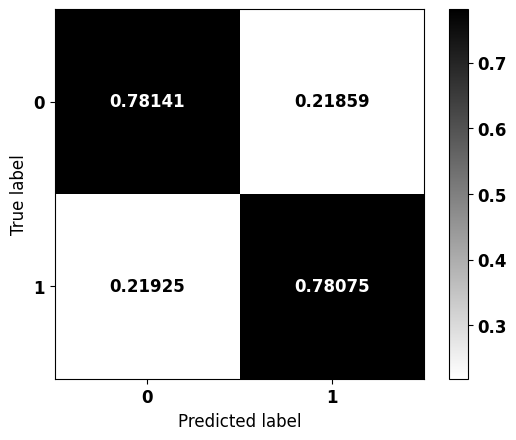


              precision    recall  f1-score   support

           0    0.81406   0.78141   0.79740     14859
           1    0.74409   0.78075   0.76198     12096

    accuracy                        0.78112     26955
   macro avg    0.77908   0.78108   0.77969     26955
weighted avg    0.78266   0.78112   0.78151     26955



In [ ]:
# Configure the final XGBoost model using the best-found hyperparameters
params = studyXGB.best_params           # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed           # Fix the random seed for reproducibility
params['scale_pos_weight'] = 1.062      # Apply the chosen class imbalance weight

# Instantiate and configure the XGBoost classifier
xgb_tpe = XGBClassifier()
xgb_tpe.set_params(**params)

# Train the optimized model on the training dataset
xgb_tpe.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(xgb_tpe, X_test, y_test)

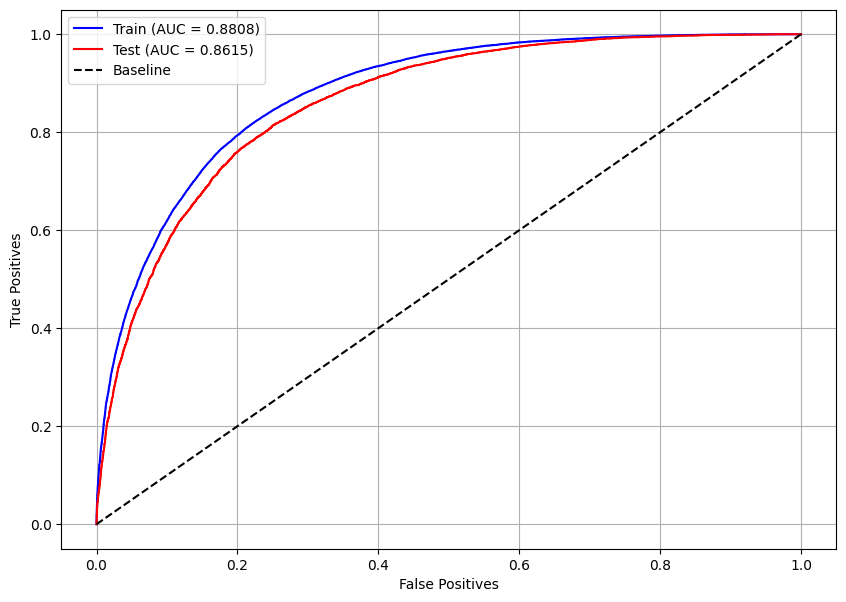

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb_tpe, X_train, X_test, y_train, y_test)

CmaEsSampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyXGB = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyXGB.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyXGB.best_params

{'n_estimators': 148,
 'max_depth': 6,
 'learning_rate': 0.1,
 'gamma': 0.2,
 'min_child_weight': 5,
 'colsample_bytree': 0.4}

In [ ]:
# Generate a range of candidate scale_pos_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(1.05, 1.1, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyXGB.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['scale_pos_weight'] = i  # Update the class weight parameter

    # Initialize a new XGBoost classifier with the updated hyperparameters
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Train the model on the training set
    xgb_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = xgb_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(xgb_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

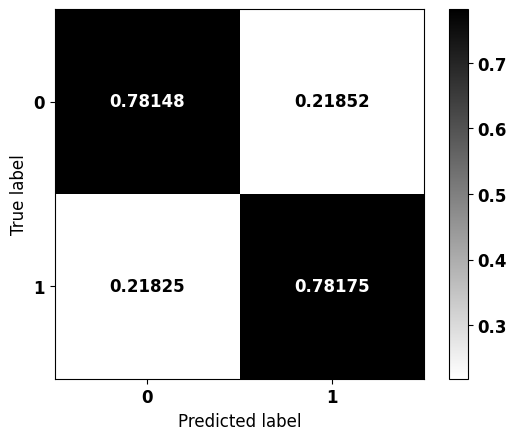


              precision    recall  f1-score   support

           0    0.81476   0.78148   0.79777     14859
           1    0.74439   0.78175   0.76261     12096

    accuracy                        0.78160     26955
   macro avg    0.77958   0.78161   0.78019     26955
weighted avg    0.78318   0.78160   0.78199     26955



In [ ]:
# Configure the final XGBoost model using the best-found hyperparameters
params = studyXGB.best_params           # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed           # Fix the random seed for reproducibility
params['scale_pos_weight'] = 1.065      # Apply the chosen class imbalance weight

# Instantiate and configure the XGBoost classifier
xgb_cma = XGBClassifier()
xgb_cma.set_params(**params)

# Train the optimized model on the training dataset
xgb_cma.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(xgb_cma, X_test, y_test)

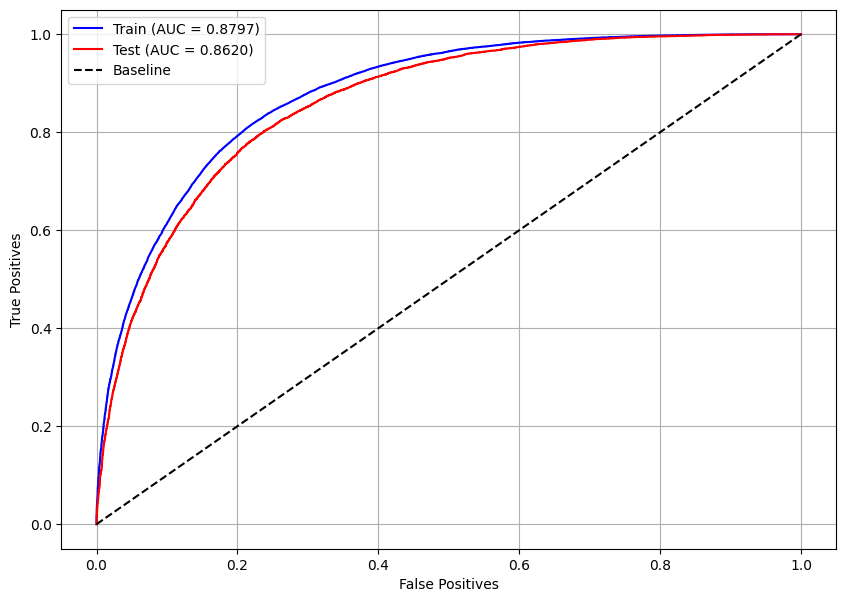

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb_cma, X_train, X_test, y_train, y_test)

**Optimized model**

In [ ]:
# Compare multiple XGBoost models and select the one with the highest test accuracy
models = [xgb_rand, xgb_tpe, xgb_cma]  # List of trained models to evaluate

for i, m in enumerate(models):
    if i == 0:
        best = m  # Initialize the first model as the current best
    else:
        best_score = best.score(X_test, y_test)  # Accuracy of the current best model
        score = m.score(X_test, y_test)          # Accuracy of the model being evaluated
        if score > best_score:
            best = m  # Update 'best' if this model performs better

print(best)  # Output the model with the highest accuracy on the test set

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.4, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.2, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=148, n_jobs=None,
              num_parallel_tree=None, random_state=7, ...)


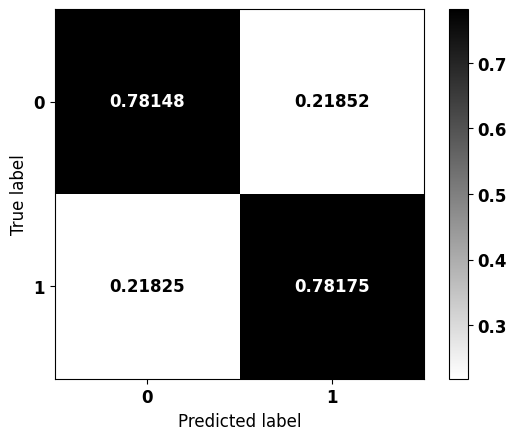


              precision    recall  f1-score   support

           0    0.81476   0.78148   0.79777     14859
           1    0.74439   0.78175   0.76261     12096

    accuracy                        0.78160     26955
   macro avg    0.77958   0.78161   0.78019     26955
weighted avg    0.78318   0.78160   0.78199     26955



In [ ]:
# Retrieve the hyperparameters from the selected best model
params = best.get_params()

# Initialize a new XGBoost classifier with those best hyperparameters
xgb_optuna = XGBClassifier()
xgb_optuna.set_params(**params)

# Train the optimized model on the training data
xgb_optuna.fit(X_train, y_train)

# Plot the confusion matrix to evaluate the optimized model on the test data
plot_confusion_matrix(xgb_optuna, X_test, y_test)

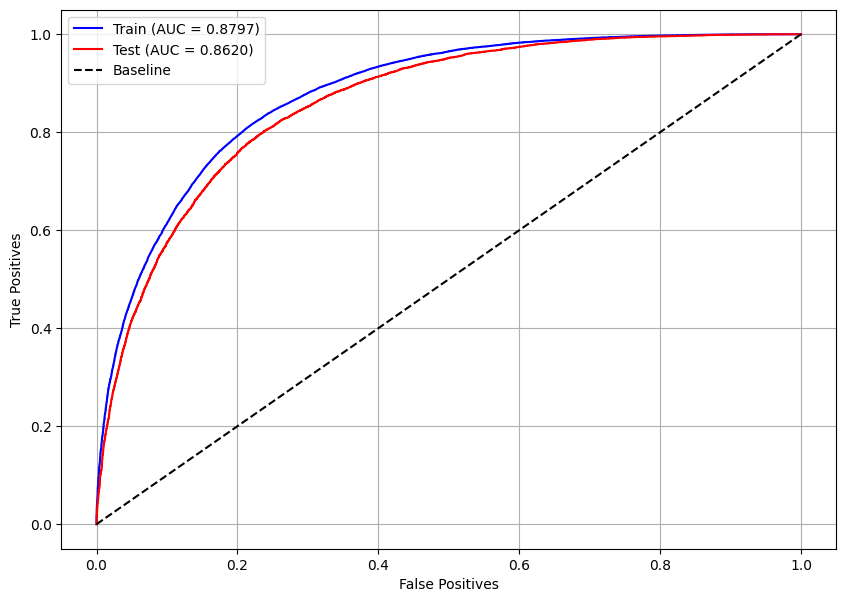

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb_optuna, X_train, X_test, y_train, y_test)

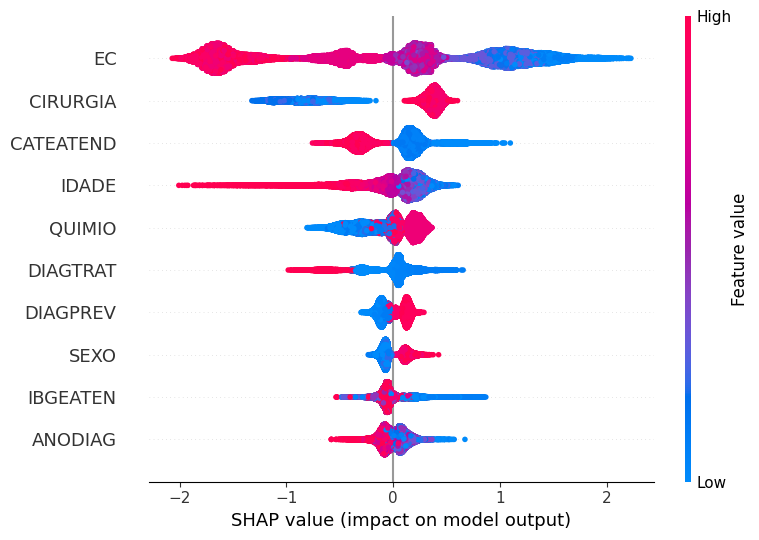

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(xgb_optuna, X_train, feat_cols)

### **LightGBM**


#### **Base model**

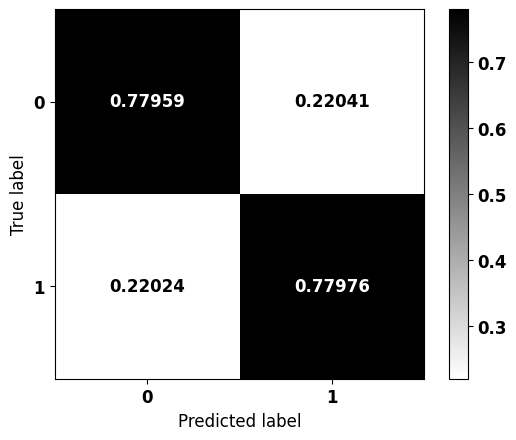


              precision    recall  f1-score   support

           0    0.81303   0.77959   0.79596     14859
           1    0.74227   0.77976   0.76055     12096

    accuracy                        0.77967     26955
   macro avg    0.77765   0.77968   0.77826     26955
weighted avg    0.78127   0.77967   0.78007     26955



In [ ]:
# Create and train the LightGBM classifier
lgbm = LGBMClassifier(max_depth=10,                 # Set maximum tree depth to 10
                      class_weight={0:1, 1:1.068},  # Balance positive and negative classes
                      random_state=seed,            # Ensure reproducibility with a fixed random seed
                      verbose=-1)

lgbm.fit(X_train, y_train)  # Train the model on the training data

# Plot the confusion matrix to evaluate model performance on the test set
plot_confusion_matrix(lgbm, X_test, y_test)

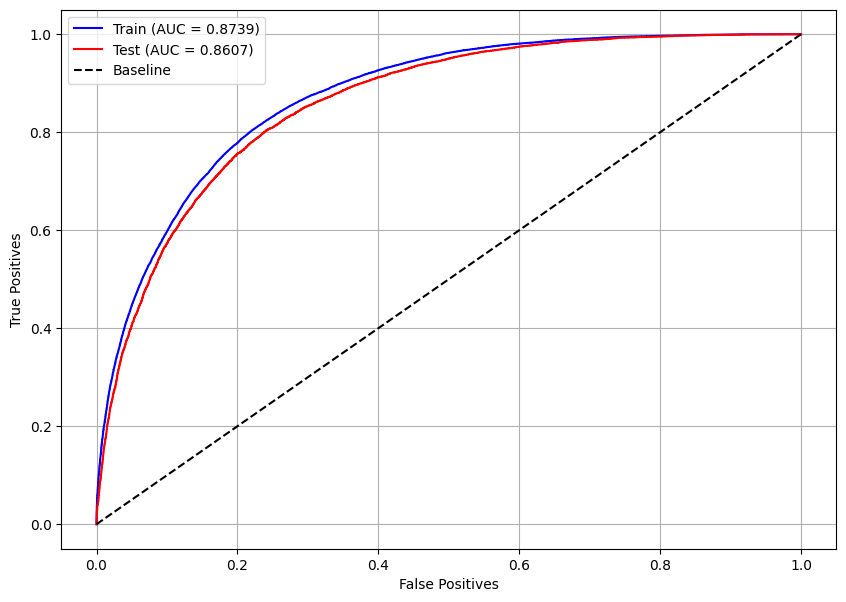

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm, X_train, X_test, y_train, y_test)

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


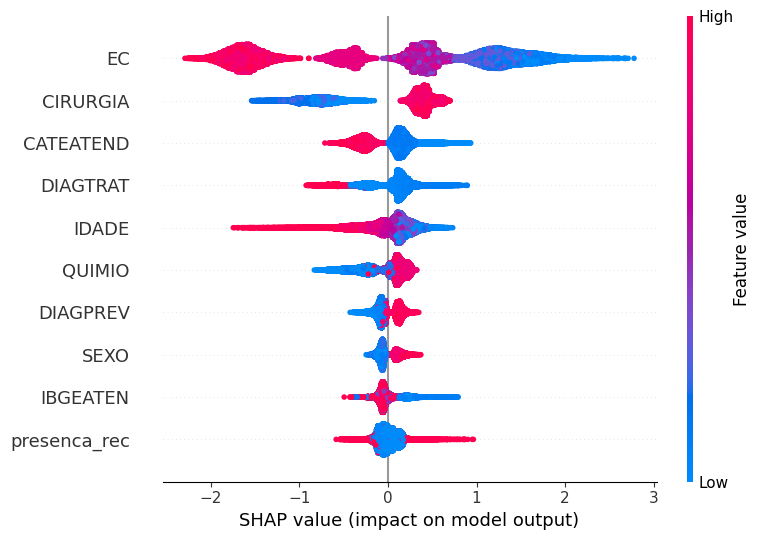

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(lgbm, X_train, feat_cols)

#### **Optuna**

In [ ]:
# Create stratified folds to maintain class proportions during cross-validation
skf = StratifiedKFold(10, shuffle=True, random_state=seed)

# Define the objective function for hyperparameter optimization
def objective(trial):
    """
    Objective function for Optuna to optimize an LightGBM classifier.
    Returns the mean accuracy across stratified folds.
    """

    # Suggest values for hyperparameters to be optimized
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Number of boosting rounds
    max_depth = trial.suggest_int('max_depth', 3, 10)  # Maximum tree depth
    learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2, step=0.01)  # Learning rate for updates
    min_child_weight = trial.suggest_int('min_child_weight', 1, 7)  # Minimum sum of instance weight in child nodes
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 0.7, step=0.1)  # Subsample ratio of features per tree

    # Initialize the LightGBM classifier with the suggested hyperparameters
    cls = LGBMClassifier(n_estimators=n_estimators,
                         max_depth=max_depth,
                         learning_rate=learning_rate,
                         min_child_weight=min_child_weight,
                         colsample_bytree=colsample_bytree,
                         random_state=seed,
                         verbose=-1,
                         n_jobs=-1)

    # Perform cross-validation and return the average accuracy
    return cross_val_score(cls, X_train, y_train,
                           cv=skf, scoring='accuracy').mean()

RandomSampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyLGBM = optuna.create_study(direction='maximize', sampler=RandomSampler(seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyLGBM.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyLGBM.best_params

{'n_estimators': 141,
 'max_depth': 9,
 'learning_rate': 0.15000000000000002,
 'min_child_weight': 5,
 'colsample_bytree': 0.6000000000000001}

In [ ]:
# Generate a range of candidate class_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(1.05, 1.1, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyLGBM.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['class_weight'] = {0:1, 1:i}  # Update the class weight parameter

    # Initialize a new LightGBM classifier with the updated hyperparameters
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Train the model on the training set
    lgbm_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = lgbm_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(lgbm_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

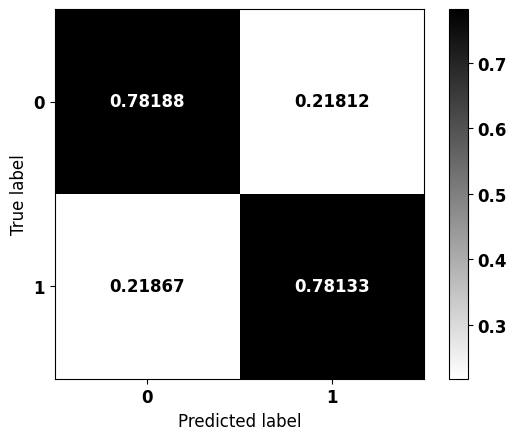


              precision    recall  f1-score   support

           0    0.81456   0.78188   0.79788     14859
           1    0.74464   0.78133   0.76255     12096

    accuracy                        0.78164     26955
   macro avg    0.77960   0.78161   0.78022     26955
weighted avg    0.78318   0.78164   0.78203     26955



In [ ]:
# Configure the final LightGBM model using the best-found hyperparameters
params = studyLGBM.best_params  # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed  # Fix the random seed for reproducibility
params['class_weight'] = {0:1, 1:1.065}  # Apply the chosen class imbalance weight

# Instantiate and configure the LightGBM classifier
lgbm_random = LGBMClassifier(verbose=-1)
lgbm_random.set_params(**params)

# Train the optimized model on the training dataset
lgbm_random.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(lgbm_random, X_test, y_test)

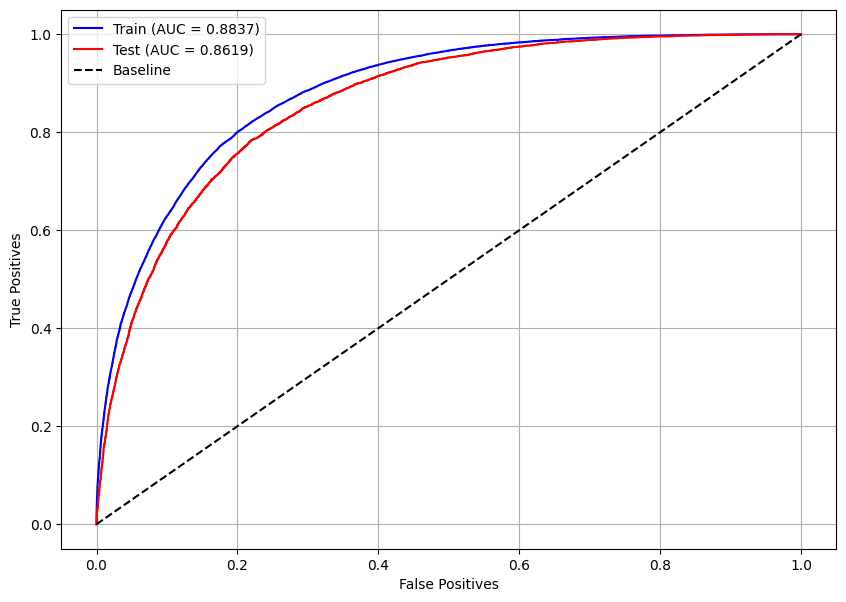

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm_random, X_train, X_test, y_train, y_test)

TPESampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyLGBM = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyLGBM.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyLGBM.best_params

{'n_estimators': 150,
 'max_depth': 9,
 'learning_rate': 0.12000000000000001,
 'min_child_weight': 2,
 'colsample_bytree': 0.6000000000000001}

In [ ]:
# Generate a range of candidate class_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(1.05, 1.1, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyLGBM.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['class_weight'] = {0:1, 1:i}  # Update the class weight parameter

    # Initialize a new LightGBM classifier with the updated hyperparameters
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Train the model on the training set
    lgbm_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = lgbm_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(lgbm_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

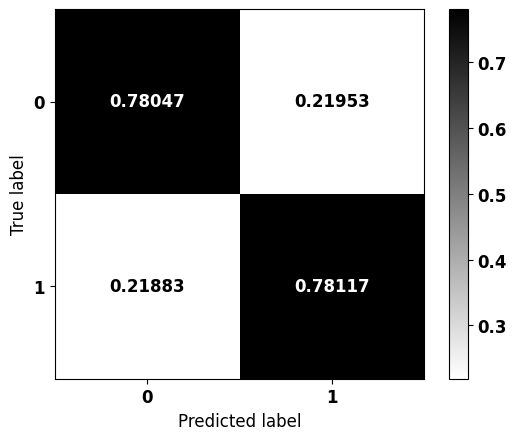


              precision    recall  f1-score   support

           0    0.81417   0.78047   0.79696     14859
           1    0.74337   0.78117   0.76180     12096

    accuracy                        0.78078     26955
   macro avg    0.77877   0.78082   0.77938     26955
weighted avg    0.78240   0.78078   0.78118     26955



In [ ]:
# Configure the final LightGBM model using the best-found hyperparameters
params = studyLGBM.best_params  # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed  # Fix the random seed for reproducibility
params['class_weight'] = {0:1, 1:1.067}  # Apply the chosen class imbalance weight

# Instantiate and configure the LightGBM classifier
lgbm_tpe = LGBMClassifier(verbose=-1)
lgbm_tpe.set_params(**params)

# Train the optimized model on the training dataset
lgbm_tpe.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(lgbm_tpe, X_test, y_test)

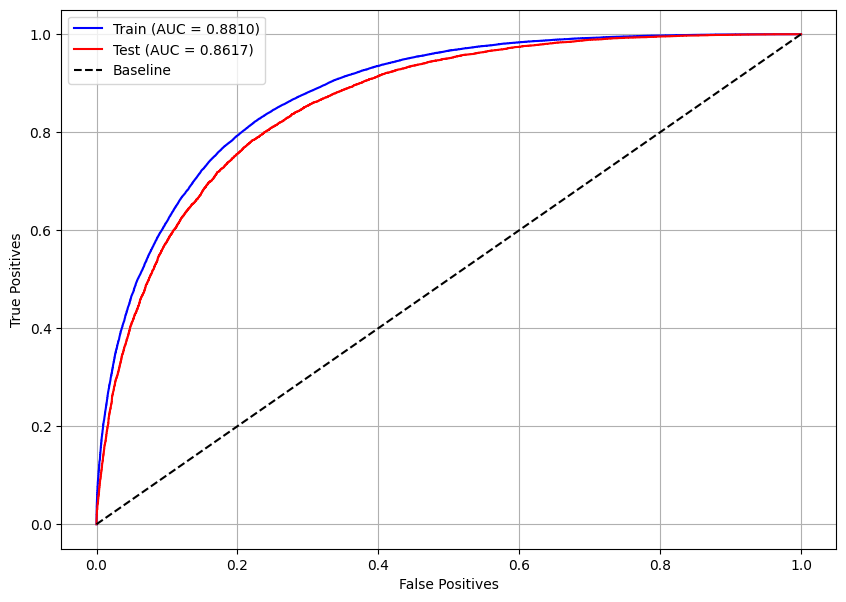

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm_tpe, X_train, X_test, y_train, y_test)

CmaEsSampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyLGBM = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyLGBM.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyLGBM.best_params

{'n_estimators': 119,
 'max_depth': 9,
 'learning_rate': 0.15000000000000002,
 'min_child_weight': 7,
 'colsample_bytree': 0.6000000000000001}

In [ ]:
# Generate a range of candidate class_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(1.05, 1.1, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyLGBM.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['class_weight'] = {0:1, 1:i}  # Update the class weight parameter

    # Initialize a new LightGBM classifier with the updated hyperparameters
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Train the model on the training set
    lgbm_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = lgbm_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(lgbm_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

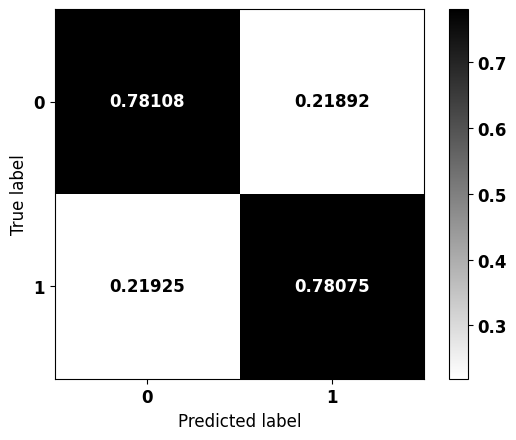


              precision    recall  f1-score   support

           0    0.81400   0.78108   0.79720     14859
           1    0.74380   0.78075   0.76183     12096

    accuracy                        0.78093     26955
   macro avg    0.77890   0.78091   0.77951     26955
weighted avg    0.78250   0.78093   0.78133     26955



In [ ]:
# Configure the final LightGBM model using the best-found hyperparameters
params = studyLGBM.best_params  # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed  # Fix the random seed for reproducibility
params['class_weight'] = {0:1, 1:1.062}  # Apply the chosen class imbalance weight

# Instantiate and configure the LightGBM classifier
lgbm_cma = LGBMClassifier(verbose=-1)
lgbm_cma.set_params(**params)

# Train the optimized model on the training dataset
lgbm_cma.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(lgbm_cma, X_test, y_test)

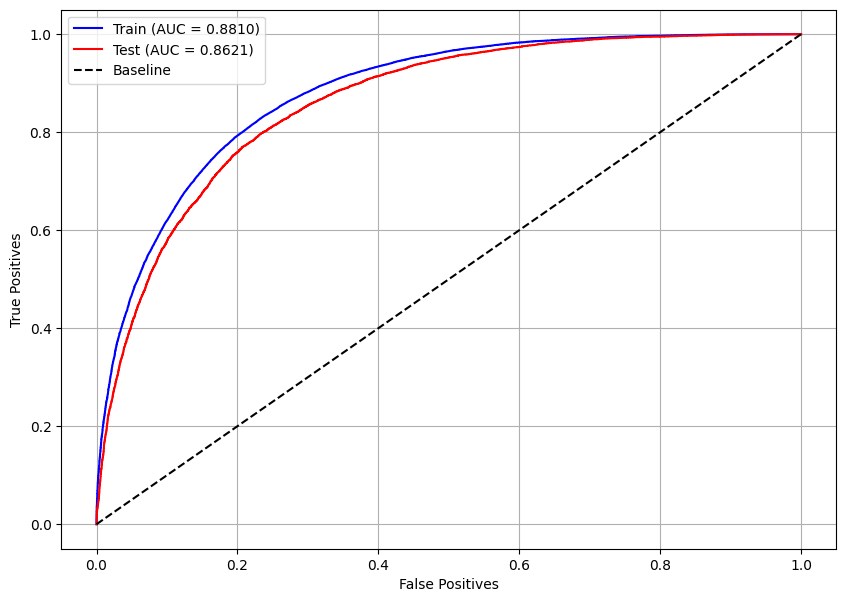

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm_cma, X_train, X_test, y_train, y_test)

**Optimized model**

In [ ]:
# Compare multiple LightGBM models and select the one with the highest test accuracy
models = [lgbm_random, lgbm_tpe, lgbm_cma]  # List of trained models to evaluate
for i, m in enumerate(models):
    if i == 0:
        best = m  # Initialize the first model as the current best
    else:
        best_score = best.score(X_test, y_test)  # Accuracy of the current best model
        score = m.score(X_test, y_test)  # Accuracy of the model being evaluated
        if score > best_score:
            best = m  # Update 'best' if this model performs better

print(best)  # Output the model with the highest accuracy on the test set

LGBMClassifier(class_weight={0: 1, 1: 1.065}, colsample_bytree=0.6,
               learning_rate=0.15, max_depth=9, min_child_weight=5,
               n_estimators=141, random_state=7, verbose=-1)


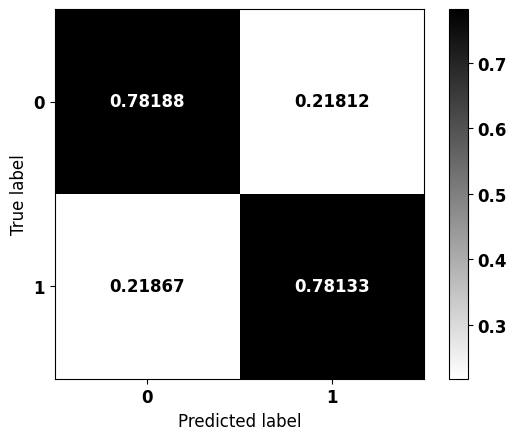


              precision    recall  f1-score   support

           0    0.81456   0.78188   0.79788     14859
           1    0.74464   0.78133   0.76255     12096

    accuracy                        0.78164     26955
   macro avg    0.77960   0.78161   0.78022     26955
weighted avg    0.78318   0.78164   0.78203     26955



In [ ]:
# Retrieve the hyperparameters from the selected best model
params = best.get_params()

# Initialize a new LightGBM classifier with those best hyperparameters
lgbm_optuna = LGBMClassifier(verbose=-1)
lgbm_optuna.set_params(**params)

# Train the optimized model on the training data
lgbm_optuna.fit(X_train, y_train)

# Plot the confusion matrix to evaluate the optimized model on the test data
plot_confusion_matrix(lgbm_optuna, X_test, y_test)

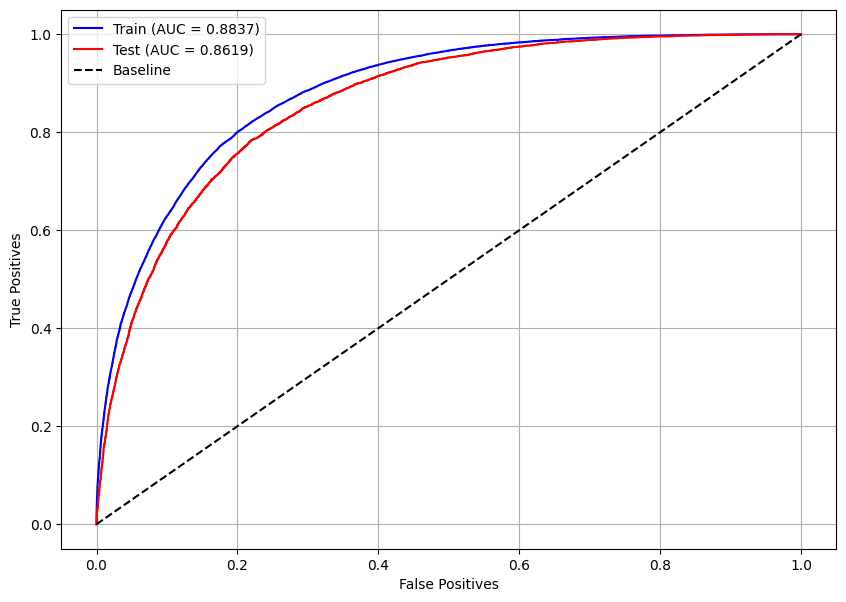

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm_optuna, X_train, X_test, y_train, y_test)

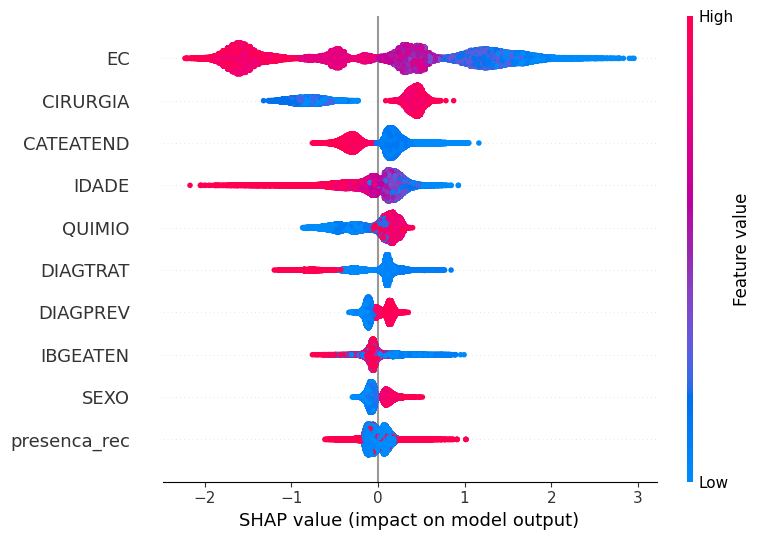

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(lgbm_optuna, X_train, feat_cols)

## **Cross Predictions**

In [ ]:
# Best Model Selection
models = [xgb, xgb_optuna, lgbm, lgbm_optuna]  # List of models to compare (XGBoost, optimized XGBoost, LightGBM, optimized LightGBM)

# Iterating through each model to find the best performing one
for i, m in enumerate(models):
    if i == 0:  # Initialize the best model as the first one
        best = m
    else:
        # Compare the performance of the current best model and the current model
        best_score = best.score(X_test, y_test)  # Get the accuracy of the current best model on the test set
        score = m.score(X_test, y_test)  # Get the accuracy of the current model on the test set
        if score > best_score:  # If the current model performs better, update the best model
            best = m

# Print the best performing model
print(best)

LGBMClassifier(class_weight={0: 1, 1: 1.065}, colsample_bytree=0.6,
               learning_rate=0.15, max_depth=9, min_child_weight=5,
               n_estimators=141, random_state=7, verbose=-1)


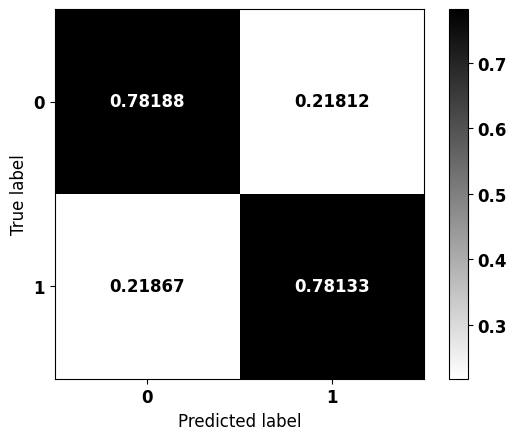


              precision    recall  f1-score   support

           0    0.81456   0.78188   0.79788     14859
           1    0.74464   0.78133   0.76255     12096

    accuracy                        0.78164     26955
   macro avg    0.77960   0.78161   0.78022     26955
weighted avg    0.78318   0.78164   0.78203     26955



In [ ]:
# Confusion Matrix for the Best Model
plot_confusion_matrix(best, X_test, y_test)  # Plot the normalized confusion matrix for the best model

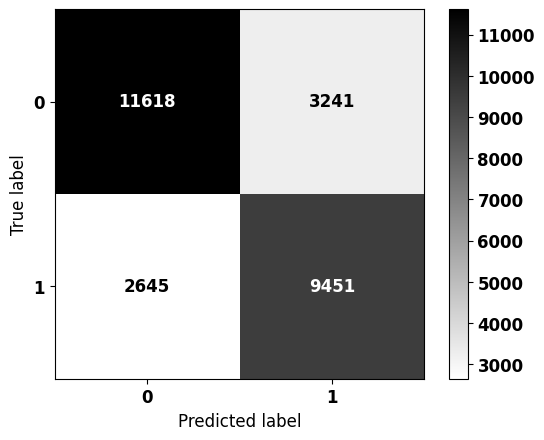


              precision    recall  f1-score   support

           0    0.81456   0.78188   0.79788     14859
           1    0.74464   0.78133   0.76255     12096

    accuracy                        0.78164     26955
   macro avg    0.77960   0.78161   0.78022     26955
weighted avg    0.78318   0.78164   0.78203     26955



In [ ]:
plot_confusion_matrix(best, X_test, y_test, norm=False)  # Plot the unnormalized confusion matrix for the best model

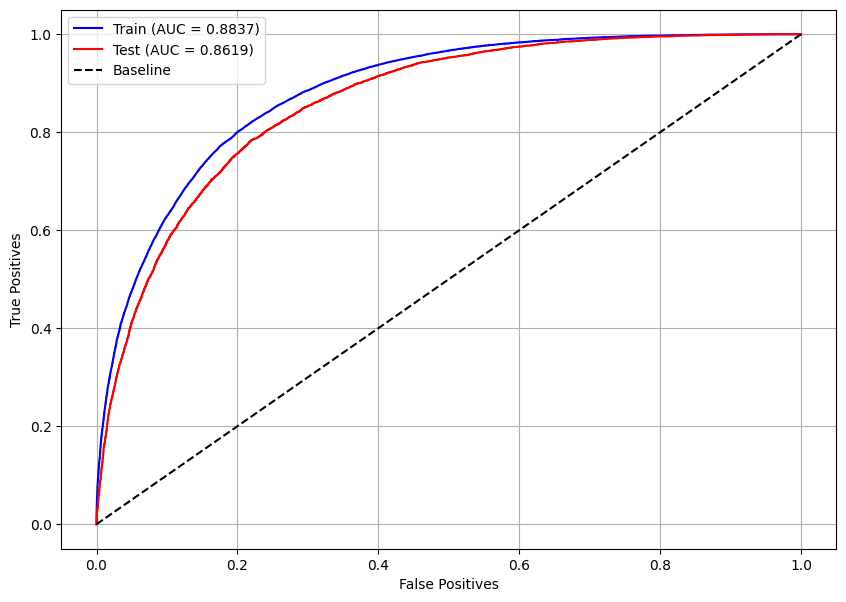

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(best, X_train, X_test, y_train, y_test)

/usr/local/lib/python3.10/dist-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


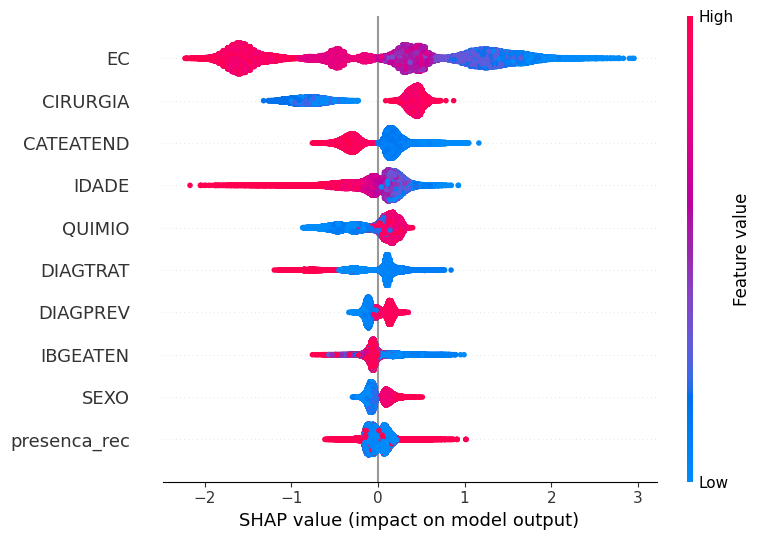

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(best, X_train, feat_cols)

In [ ]:
# Prepare test features and target for Oral Cavity Cancer
X_test_boca = boca_teste.drop(columns=list_drop).copy()  # Features for the Oral Cavity cancer test set
y_test_boca = boca_teste.sobrevida_3anos.copy()          # Target variable (3-year survival) for the Oral Cavity cancer test set

# Encode the 'TOPOGRUP' categorical column using the fitted OrdinalEncoder
X_test_boca['TOPOGRUP'] = oe.transform(X_test_boca[['TOPOGRUP']])

# Scale the encoded 'TOPOGRUP' values using the fitted StandardScaler
X_test_boca['TOPOGRUP'] = ss.transform(X_test_boca[['TOPOGRUP']])

# Prepare test features and target for Stomach Cancer
X_test_esto = esto_teste.drop(columns=list_drop).copy()  # Features for the Stomach cancer test set
y_test_esto = esto_teste.sobrevida_3anos.copy()          # Target variable (3-year survival) for the Stomach cancer test set

# Encode the 'TOPOGRUP' categorical column using the fitted OrdinalEncoder
X_test_esto['TOPOGRUP'] = oe.transform(X_test_esto[['TOPOGRUP']])

# Scale the encoded 'TOPOGRUP' values using the fitted StandardScaler
X_test_esto['TOPOGRUP'] = ss.transform(X_test_esto[['TOPOGRUP']])

# Prepare test features and target for Colorectal Cancer
X_test_colo = colo_teste.drop(columns=list_drop).copy()  # Features for the Colorectal cancer test set
y_test_colo = colo_teste.sobrevida_3anos.copy()          # Target variable (3-year survival) for the Colorectal cancer test set

# Encode the 'TOPOGRUP' categorical column using the fitted OrdinalEncoder
X_test_colo['TOPOGRUP'] = oe.transform(X_test_colo[['TOPOGRUP']])

# Scale the encoded 'TOPOGRUP' values using the fitted StandardScaler
X_test_colo['TOPOGRUP'] = ss.transform(X_test_colo[['TOPOGRUP']])

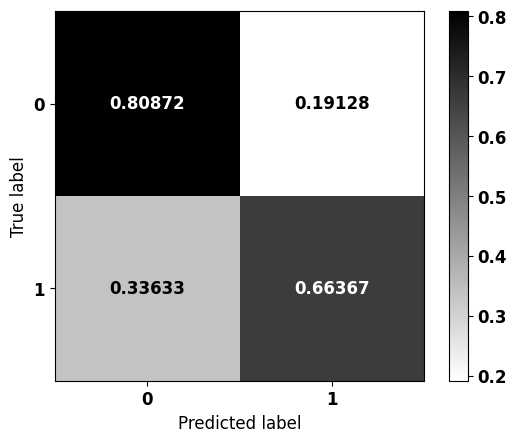


              precision    recall  f1-score   support

           0    0.77621   0.80872   0.79213      3534
           1    0.70634   0.66367   0.68434      2450

    accuracy                        0.74933      5984
   macro avg    0.74128   0.73619   0.73824      5984
weighted avg    0.74760   0.74933   0.74800      5984



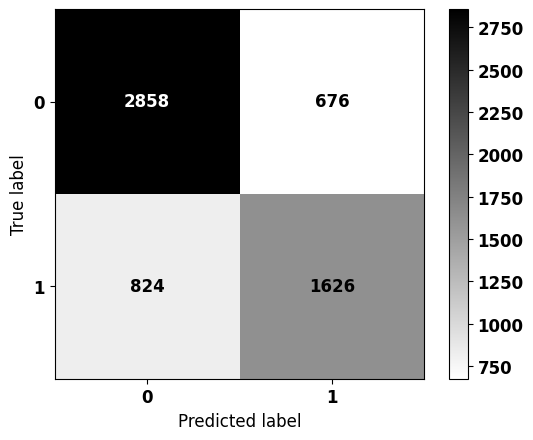


              precision    recall  f1-score   support

           0    0.77621   0.80872   0.79213      3534
           1    0.70634   0.66367   0.68434      2450

    accuracy                        0.74933      5984
   macro avg    0.74128   0.73619   0.73824      5984
weighted avg    0.74760   0.74933   0.74800      5984



In [ ]:
# Plot the normalized confusion matrix for the best model on the Oral Cavity cancer test data
plot_confusion_matrix(best, X_test_boca, y_test_boca)

# Plot the raw (unnormalized) confusion matrix for the best model on the Oral Cavity cancer test data
plot_confusion_matrix(best, X_test_boca, y_test_boca, norm=False)

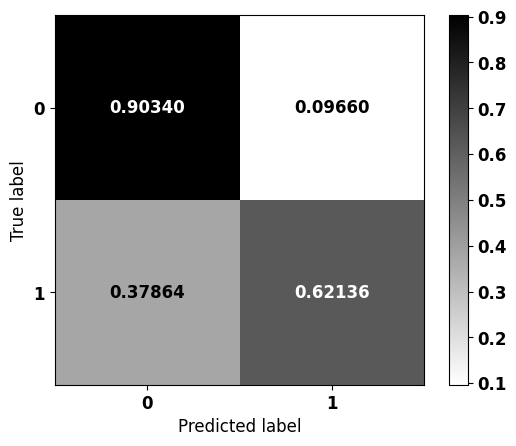


              precision    recall  f1-score   support

           0    0.86439   0.90340   0.88347      5052
           1    0.70655   0.62136   0.66123      1891

    accuracy                        0.82659      6943
   macro avg    0.78547   0.76238   0.77235      6943
weighted avg    0.82140   0.82659   0.82294      6943



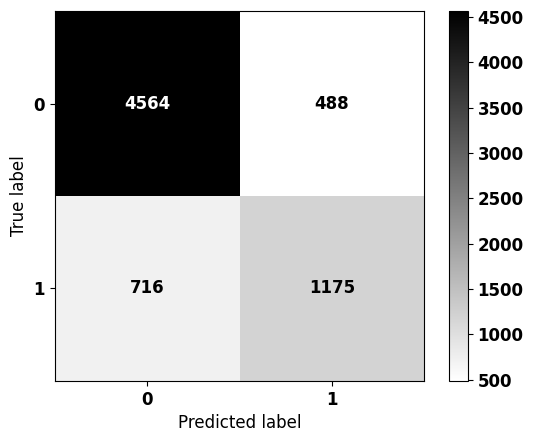


              precision    recall  f1-score   support

           0    0.86439   0.90340   0.88347      5052
           1    0.70655   0.62136   0.66123      1891

    accuracy                        0.82659      6943
   macro avg    0.78547   0.76238   0.77235      6943
weighted avg    0.82140   0.82659   0.82294      6943



In [ ]:
# Plot the normalized confusion matrix for the best model on the Stomach cancer test data
plot_confusion_matrix(best, X_test_esto, y_test_esto)

# Plot the raw (unnormalized) confusion matrix for the best model on the Stomach cancer test data
plot_confusion_matrix(best, X_test_esto, y_test_esto, norm=False)

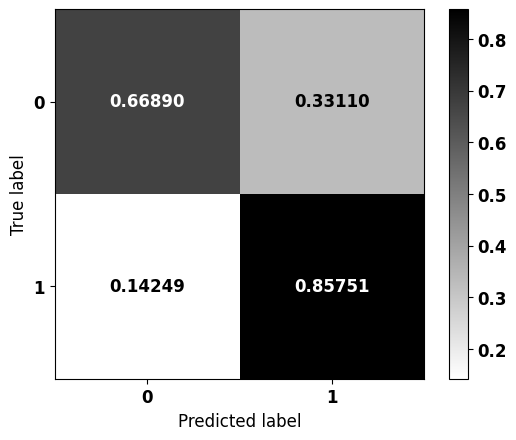


              precision    recall  f1-score   support

           0    0.79155   0.66890   0.72507      6273
           1    0.76200   0.85751   0.80694      7755

    accuracy                        0.77317     14028
   macro avg    0.77678   0.76320   0.76601     14028
weighted avg    0.77522   0.77317   0.77033     14028



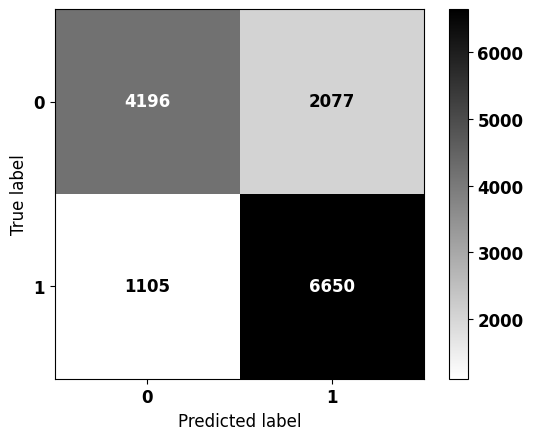


              precision    recall  f1-score   support

           0    0.79155   0.66890   0.72507      6273
           1    0.76200   0.85751   0.80694      7755

    accuracy                        0.77317     14028
   macro avg    0.77678   0.76320   0.76601     14028
weighted avg    0.77522   0.77317   0.77033     14028



In [ ]:
# Plot the normalized confusion matrix for the best model on the Colorectal cancer test data
plot_confusion_matrix(best, X_test_colo, y_test_colo)

# Plot the raw (unnormalized) confusion matrix for the best model on the Colorectal cancer test data
plot_confusion_matrix(best, X_test_colo, y_test_colo, norm=False)

## **Voting Classifier**


In [ ]:
# Comparing the accuracy scores of the initial XGBoost model and the optimized Optuna model
xgb_score = xgb.score(X_test, y_test)
optuna_score = xgb_optuna.score(X_test, y_test)
print(f'Accuracy: XGB = {xgb_score:.4f}, Optuna = {optuna_score:.4f}\n')

# Determine which model performed better
if optuna_score >= xgb_score:
    params_xgb = xgb_optuna.get_params()  # Get the parameters of the optimized model
    print('Optimized model won')
else:
    params_xgb = xgb.get_params()  # Get the parameters of the initial model
    print('Initial model won')

Accuracy: XGB = 0.7804, Optuna = 0.7816

Otimizado venceu


In [ ]:
# Comparing the accuracy scores of the initial LightGBM model and the optimized Optuna model
lgbm_score = lgbm.score(X_test, y_test)
optuna_score = lgbm_optuna.score(X_test, y_test)
print(f'Accuracy: LGBM = {lgbm_score:.4f}, Optuna = {optuna_score:.4f}\n')

# Determine which model performed better
if optuna_score >= lgbm_score:
    params_lgbm = lgbm_optuna.get_params()  # Get the parameters of the optimized model
    print('Optimized model won')
else:
    params_lgbm = lgbm.get_params()  # Get the parameters of the initial model
    print('Initial model won')

Accuracy: LGBM = 0.7797, Optuna = 0.7816

Otimizado venceu


In [ ]:
# Creating the models with the best-performing hyperparameters
# XGBoost Model
best_xgb = XGBClassifier()  # Instantiate the XGBoost classifier
best_xgb.set_params(**params_xgb)  # Set the best hyperparameters for XGBoost

# LightGBM Model
best_lgbm = LGBMClassifier()  # Instantiate the LightGBM classifier
best_lgbm.set_params(**params_lgbm)  # Set the best hyperparameters for LightGBM

LGBMClassifier(class_weight={0: 1, 1: 1.065}, colsample_bytree=0.6,
               learning_rate=0.15, max_depth=9, min_child_weight=5,
               n_estimators=141, random_state=7, verbose=-1)

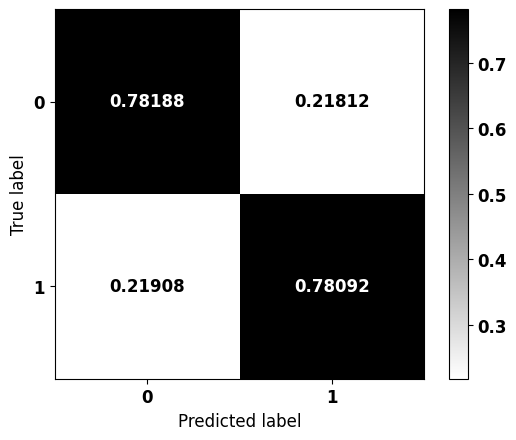


              precision    recall  f1-score   support

           0    0.81427   0.78188   0.79775     14859
           1    0.74454   0.78092   0.76230     12096

    accuracy                        0.78145     26955
   macro avg    0.77941   0.78140   0.78002     26955
weighted avg    0.78298   0.78145   0.78184     26955



In [ ]:
from sklearn.ensemble import VotingClassifier

# Creating and training the voting classifier model
clf = VotingClassifier(
    estimators=[('XGBoost', best_xgb),  # Adding the best XGBoost model
               ('LightGBM', best_lgbm)],  # Adding the best LightGBM model
    voting='soft'  # Using 'soft' voting, which predicts the class label based on predicted probabilities
)

clf.fit(X_train, y_train)  # Train the voting classifier on the training data

# Confusion Matrix
plot_confusion_matrix(clf, X_test, y_test)  # Plot the confusion matrix for the voting classifier on the test data

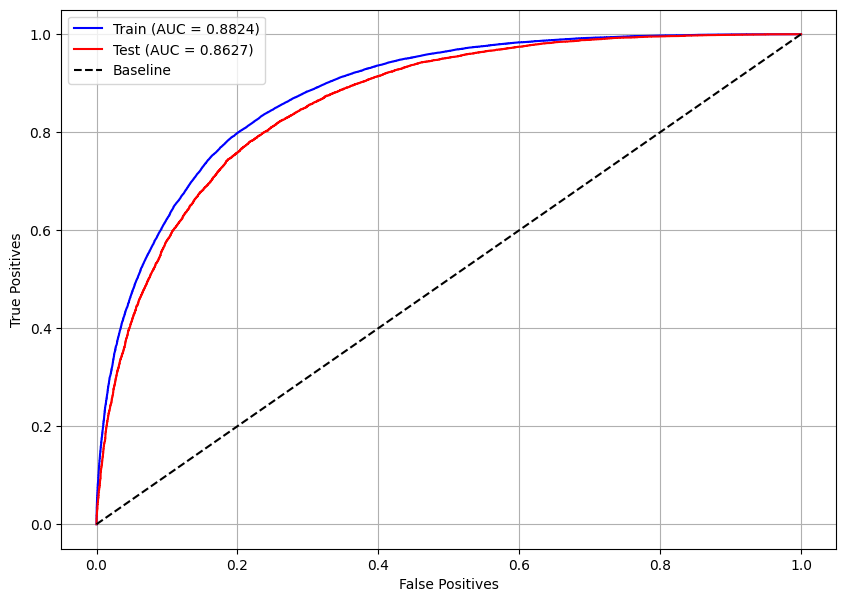

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(clf, X_train, X_test, y_train, y_test)

# **Esophagus with Oral Cavity e Stomach**

In [ ]:
# Topographies for group 2
df2_treino.TOPOGRUP.value_counts()

TOPOGRUP
Estômago    20827
Boca        17951
Esôfago     10470
Name: count, dtype: int64

In [ ]:
# Missing values
df2_treino.isna().sum().sort_values(ascending=False)

IDADE                 0
CONSDIAG              0
TOPOGRUP              0
presenca_rec          0
IBGE_idem_IBGEATEN    0
ESCOLARI_preench      0
HABILIT2              0
IBGEATEN              0
RRAS                  0
DRS                   0
ANODIAG               0
DIAGTRAT              0
OUTROS                0
SEXO                  0
IMUNO                 0
TMO                   0
HORMONIO              0
QUIMIO                0
RADIO                 0
CIRURGIA              0
EC                    0
DIAGPREV              0
CATEATEND             0
IBGE                  0
sobrevida_3anos       0
dtype: int64

In [ ]:
# Count the number of patients in each class of the target variable 'sobrevida_ano3'
df2_treino.sobrevida_3anos.value_counts()

sobrevida_3anos
0    34821
1    14427
Name: count, dtype: int64

## **Preprocessing**

In [ ]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Initialize an OrdinalEncoder to convert categorical 'TOPOGRUP' values to integer codes,
# and assign -1 to any categories not seen during fitting
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit the encoder on the training set and transform its 'TOPOGRUP' column
df2_treino['TOPOGRUP'] = oe.fit_transform(df2_treino[['TOPOGRUP']])

# Transform the test set's 'TOPOGRUP' column using the already-fitted encoder
df2_teste['TOPOGRUP'] = oe.transform(df2_teste[['TOPOGRUP']])

# Initialize a StandardScaler to standardize the feature (zero mean, unit variance)
ss = StandardScaler()

# Fit the scaler on the training set's encoded 'TOPOGRUP' values and apply the transformation
df2_treino['TOPOGRUP'] = ss.fit_transform(df2_treino[['TOPOGRUP']])

# Apply the same scaling transformation to the test set's encoded 'TOPOGRUP' values
df2_teste['TOPOGRUP'] = ss.transform(df2_teste[['TOPOGRUP']])

In [ ]:
# Define the column to drop (the target variable)
list_drop = ['sobrevida_3anos']

# Prepare training features and target
X_train = df2_treino.drop(columns=list_drop).copy()  # Features for the training set
y_train = df2_treino.sobrevida_3anos.copy()          # Target variable for the training set

# Prepare test features and target
X_test = df2_teste.drop(columns=list_drop).copy()    # Features for the test set
y_test = df2_teste.sobrevida_3anos.copy()            # Target variable for the test set

# Display the shapes of the training and test splits
X_train.shape, y_train.shape, X_test.shape, y_test.shape

In [ ]:
# Feature columns
feat_cols = X_train.columns
feat_cols

Index(['IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV', 'EC', 'CIRURGIA',
       'RADIO', 'QUIMIO', 'HORMONIO', 'TMO', 'IMUNO', 'OUTROS', 'CONSDIAG',
       'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'IBGEATEN', 'HABILIT2',
       'ESCOLARI_preench', 'IBGE_idem_IBGEATEN', 'presenca_rec', 'TOPOGRUP'],
      dtype='object')

## **Machine learning models**

### **XGBoost**


#### **Base model**

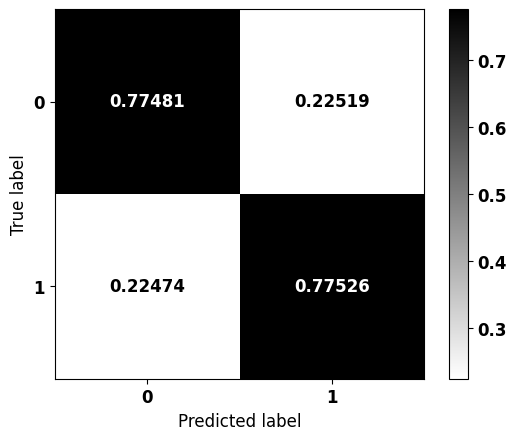


              precision    recall  f1-score   support

           0    0.89270   0.77481   0.82959     11608
           1    0.58789   0.77526   0.66870      4810

    accuracy                        0.77494     16418
   macro avg    0.74030   0.77504   0.74914     16418
weighted avg    0.80340   0.77494   0.78245     16418



In [ ]:
# Create and train the XGBoost classifier
xgb = XGBClassifier(max_depth=4,            # Set maximum tree depth to 4
                    scale_pos_weight=2.315, # Balance positive and negative classes
                    random_state=seed)      # Ensure reproducibility with a fixed random seed

xgb.fit(X_train, y_train)  # Train the model on the training data

# Plot the confusion matrix to evaluate model performance on the test set
plot_confusion_matrix(xgb, X_test, y_test)

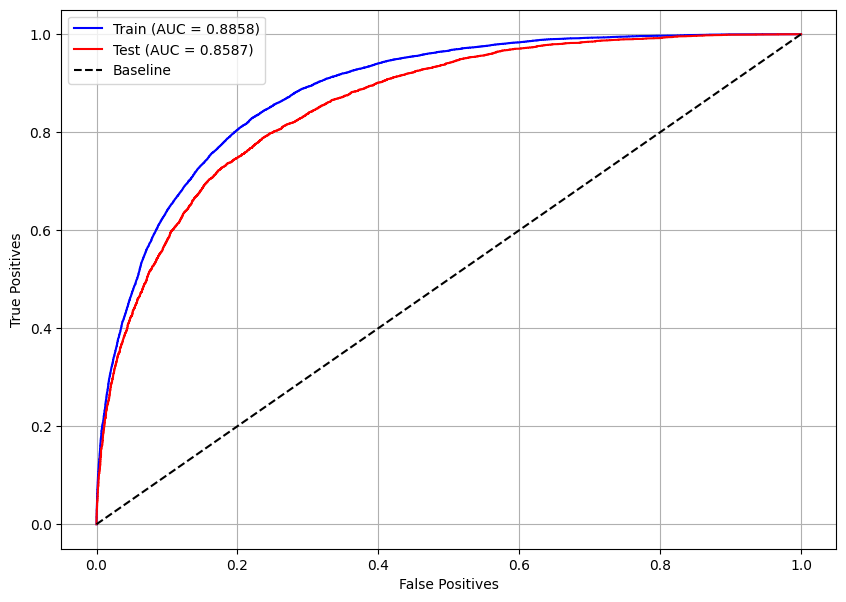

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb, X_train, X_test, y_train, y_test)

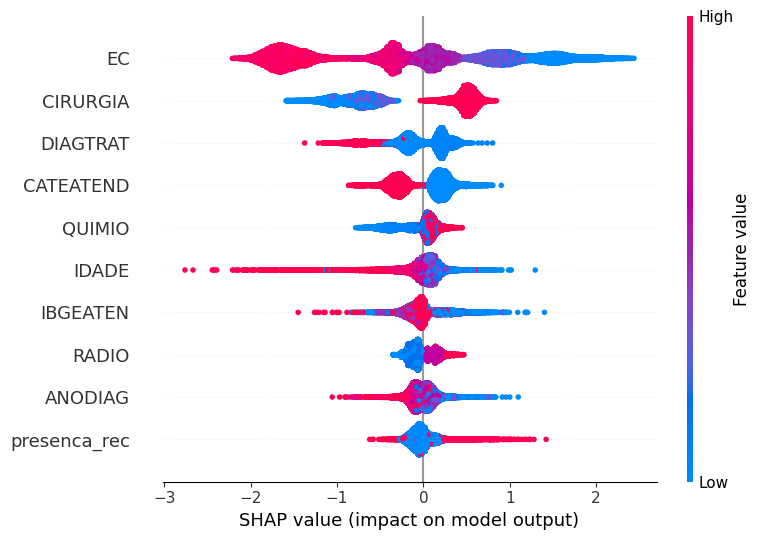

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(xgb, X_train, feat_cols)

#### **Optuna**

In [ ]:
# Create stratified folds to maintain class proportions during cross-validation
skf = StratifiedKFold(10, shuffle=True, random_state=seed)

# Define the objective function for hyperparameter optimization
def objective(trial):
    """
    Objective function for Optuna to optimize an XGBoost classifier.
    Returns the mean accuracy across stratified folds.
    """

    # Suggest values for hyperparameters to be optimized
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Number of boosting rounds
    max_depth = trial.suggest_int('max_depth', 3, 5)  # Maximum tree depth
    learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2, step=0.05)  # Learning rate for updates
    gamma = trial.suggest_float('gamma', 0.0, 0.3, step=0.1)  # Minimum loss reduction for tree splits
    min_child_weight = trial.suggest_int('min_child_weight', 1, 7)  # Minimum sum of instance weight in child nodes
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 0.7, step=0.1)  # Subsample ratio of features per tree

    # Initialize the XGBoost classifier with the suggested hyperparameters
    cls = XGBClassifier(n_estimators=n_estimators,
                        max_depth=max_depth,
                        learning_rate=learning_rate,
                        gamma=gamma,
                        min_child_weight=min_child_weight,
                        colsample_bytree=colsample_bytree,
                        random_state=seed,
                        n_jobs=-1)

    # Perform cross-validation and return the average accuracy
    return cross_val_score(cls, X_train, y_train,
                           cv=skf, scoring='accuracy').mean()

RandomSampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyXGB = optuna.create_study(direction='maximize', sampler=RandomSampler(seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyXGB.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyXGB.best_params

{'n_estimators': 137,
 'max_depth': 5,
 'learning_rate': 0.15000000000000002,
 'gamma': 0.0,
 'min_child_weight': 5,
 'colsample_bytree': 0.4}

In [ ]:
# Generate a range of candidate scale_pos_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(2.28, 2.32, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyXGB.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['scale_pos_weight'] = i  # Update the class weight parameter

    # Initialize a new XGBoost classifier with the updated hyperparameters
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Train the model on the training set
    xgb_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = xgb_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(xgb_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

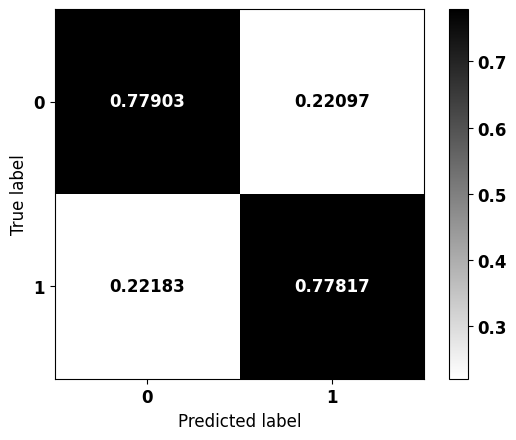


              precision    recall  f1-score   support

           0    0.89446   0.77903   0.83277     11608
           1    0.59337   0.77817   0.67332      4810

    accuracy                        0.77878     16418
   macro avg    0.74392   0.77860   0.75304     16418
weighted avg    0.80625   0.77878   0.78605     16418



In [ ]:
# Configure the final XGBoost model using the best-found hyperparameters
params = studyXGB.best_params           # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed           # Fix the random seed for reproducibility
params['scale_pos_weight'] = 2.296      # Apply the chosen class imbalance weight

# Instantiate and configure the XGBoost classifier
xgb_rand = XGBClassifier()
xgb_rand.set_params(**params)

# Train the optimized model on the training dataset
xgb_rand.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(xgb_rand, X_test, y_test)

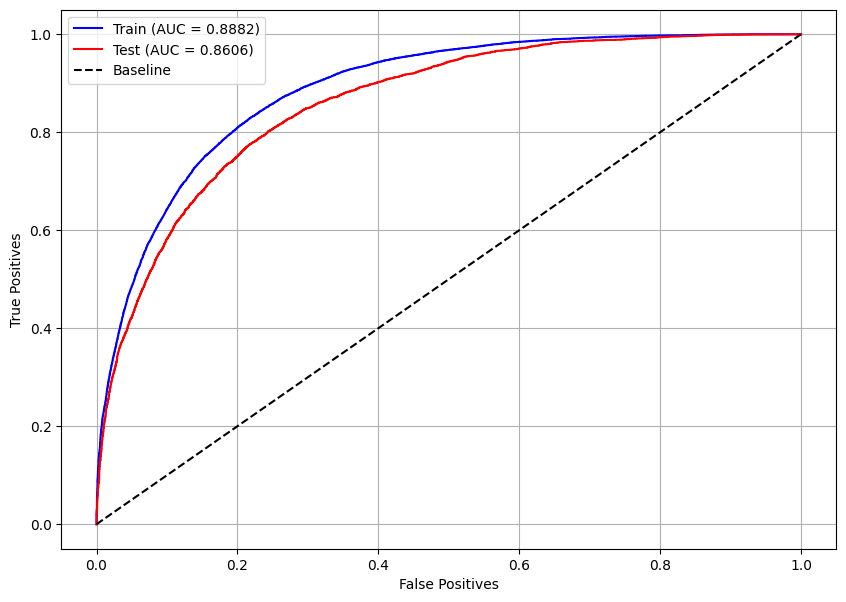

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb_rand, X_train, X_test, y_train, y_test)

TPESampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyXGB = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyXGB.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyXGB.best_params

{'n_estimators': 147,
 'max_depth': 5,
 'learning_rate': 0.15000000000000002,
 'gamma': 0.0,
 'min_child_weight': 1,
 'colsample_bytree': 0.4}

In [ ]:
# Generate a range of candidate scale_pos_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(2.28, 2.32, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyXGB.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['scale_pos_weight'] = i  # Update the class weight parameter

    # Initialize a new XGBoost classifier with the updated hyperparameters
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Train the model on the training set
    xgb_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = xgb_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(xgb_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

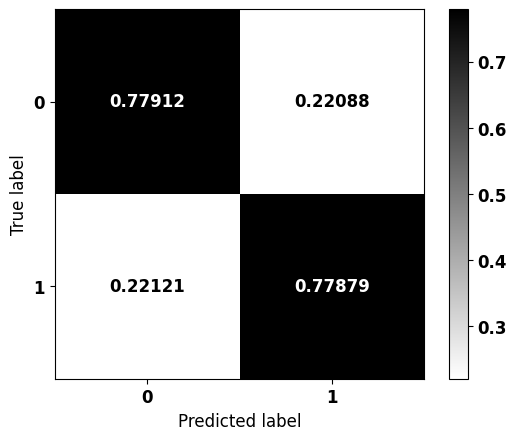


              precision    recall  f1-score   support

           0    0.89474   0.77912   0.83293     11608
           1    0.59366   0.77879   0.67374      4810

    accuracy                        0.77902     16418
   macro avg    0.74420   0.77896   0.75334     16418
weighted avg    0.80653   0.77902   0.78630     16418



In [ ]:
# Configure the final XGBoost model using the best-found hyperparameters
params = studyXGB.best_params           # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed           # Fix the random seed for reproducibility
params['scale_pos_weight'] = 2.299      # Apply the chosen class imbalance weight

# Instantiate and configure the XGBoost classifier
xgb_tpe = XGBClassifier()
xgb_tpe.set_params(**params)

# Train the optimized model on the training dataset
xgb_tpe.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(xgb_tpe, X_test, y_test)

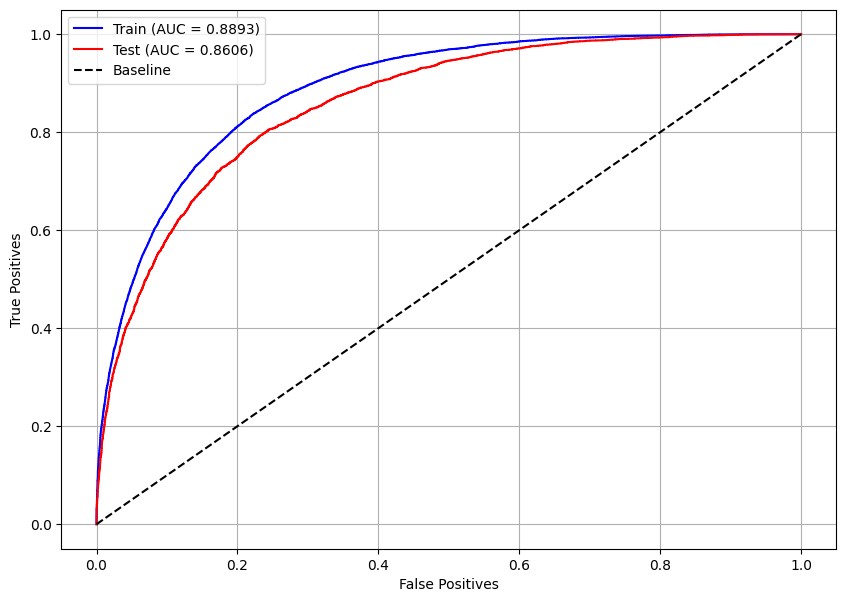

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb_tpe, X_train, X_test, y_train, y_test)

CmaEsSampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyXGB = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyXGB.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyXGB.best_params

{'n_estimators': 126,
 'max_depth': 5,
 'learning_rate': 0.1,
 'gamma': 0.2,
 'min_child_weight': 2,
 'colsample_bytree': 0.6000000000000001}

In [ ]:
# Generate a range of candidate scale_pos_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(2.26, 2.31, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyXGB.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['scale_pos_weight'] = i  # Update the class weight parameter

    # Initialize a new XGBoost classifier with the updated hyperparameters
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Train the model on the training set
    xgb_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = xgb_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(xgb_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

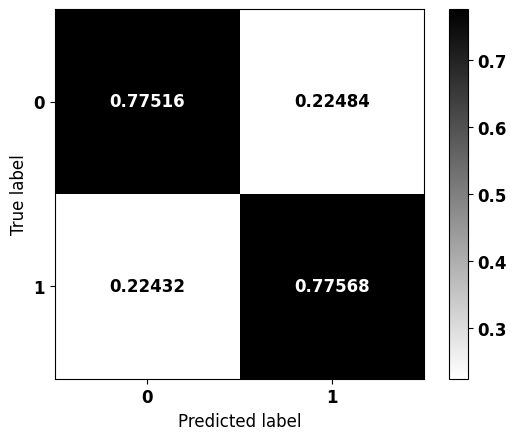


              precision    recall  f1-score   support

           0    0.89292   0.77516   0.82988     11608
           1    0.58839   0.77568   0.66918      4810

    accuracy                        0.77531     16418
   macro avg    0.74066   0.77542   0.74953     16418
weighted avg    0.80371   0.77531   0.78280     16418



In [ ]:
# Configure the final XGBoost model using the best-found hyperparameters
params = studyXGB.best_params           # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed           # Fix the random seed for reproducibility
params['scale_pos_weight'] = 2.273      # Apply the chosen class imbalance weight

# Instantiate and configure the XGBoost classifier
xgb_cma = XGBClassifier()
xgb_cma.set_params(**params)

# Train the optimized model on the training dataset
xgb_cma.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(xgb_cma, X_test, y_test)

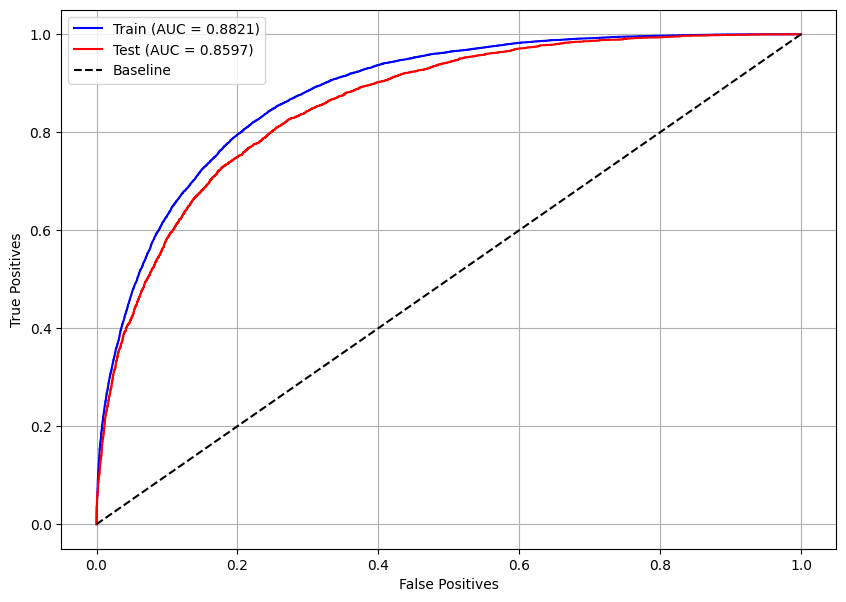

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb_cma, X_train, X_test, y_train, y_test)

**Optimized model**

In [ ]:
# Compare multiple XGBoost models and select the one with the highest test accuracy
models = [xgb_random, xgb_tpe, xgb_cma]  # List of trained models to evaluate

for i, m in enumerate(models):
    if i == 0:
        best = m  # Initialize the first model as the current best
    else:
        best_score = best.score(X_test, y_test)  # Accuracy of the current best model
        score = m.score(X_test, y_test)          # Accuracy of the model being evaluated
        if score > best_score:
            best = m  # Update 'best' if this model performs better

print(best)  # Output the model with the highest accuracy on the test set

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.4, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.15, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=147, n_jobs=None,
              num_parallel_tree=None, random_state=7, ...)


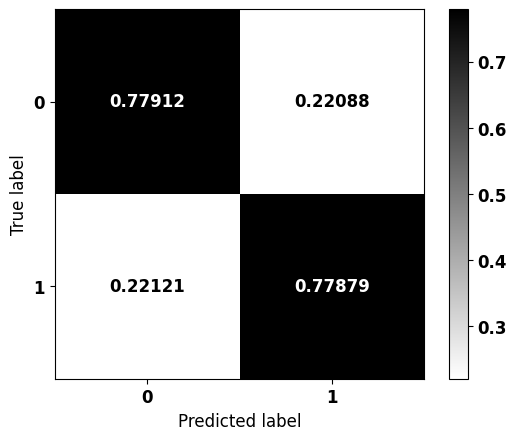


              precision    recall  f1-score   support

           0    0.89474   0.77912   0.83293     11608
           1    0.59366   0.77879   0.67374      4810

    accuracy                        0.77902     16418
   macro avg    0.74420   0.77896   0.75334     16418
weighted avg    0.80653   0.77902   0.78630     16418



In [ ]:
# Retrieve the hyperparameters from the selected best model
params = best.get_params()

# Initialize a new XGBoost classifier with those best hyperparameters
xgb_optuna = XGBClassifier()
xgb_optuna.set_params(**params)

# Train the optimized model on the training data
xgb_optuna.fit(X_train, y_train)

# Plot the confusion matrix to evaluate the optimized model on the test data
plot_confusion_matrix(xgb_optuna, X_test, y_test)

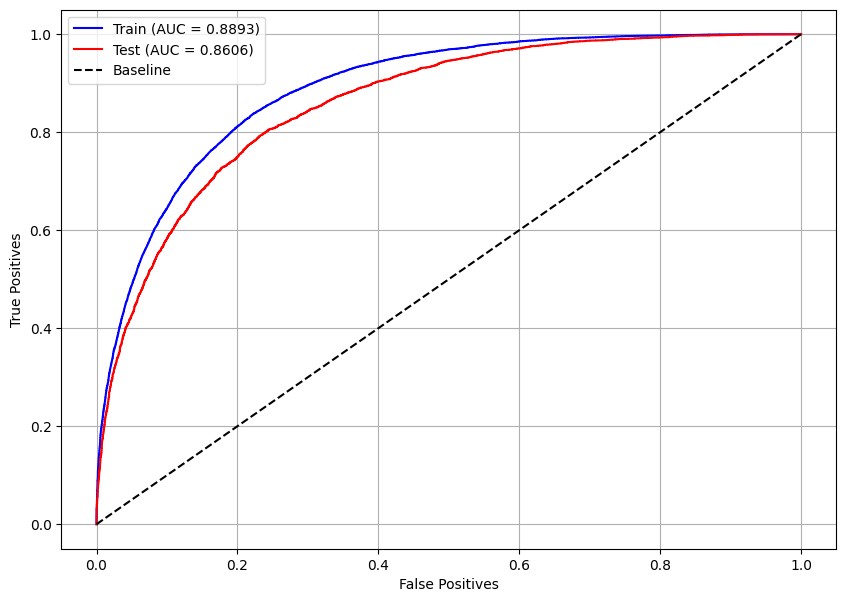

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb_optuna, X_train, X_test, y_train, y_test)

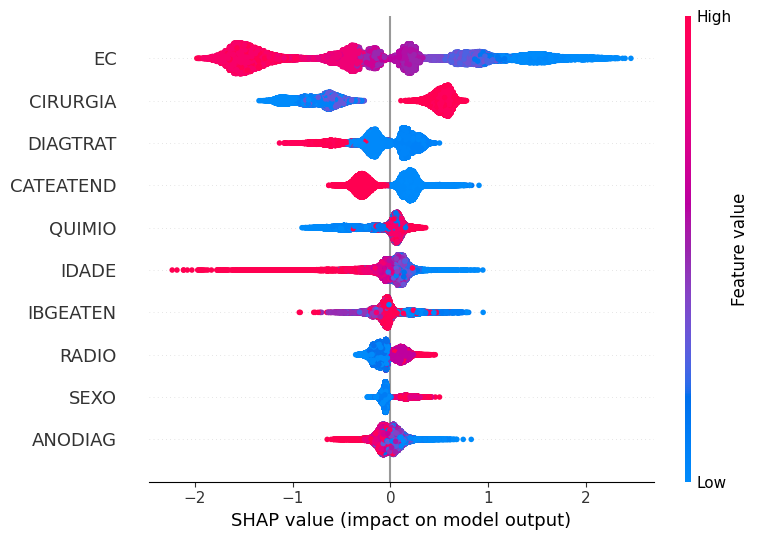

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(xgb_optuna, X_train, feat_cols)

### **LightGBM**


#### **Base model**

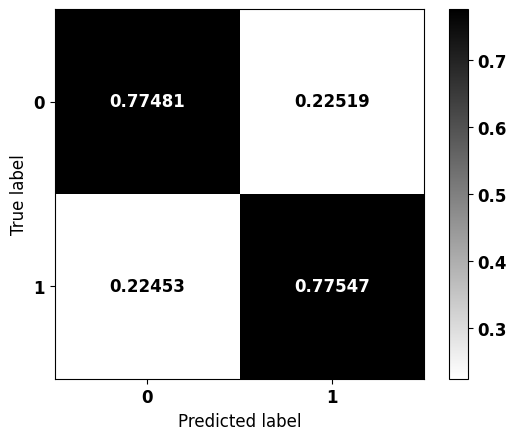


              precision    recall  f1-score   support

           0    0.89279   0.77481   0.82963     11608
           1    0.58796   0.77547   0.66882      4810

    accuracy                        0.77500     16418
   macro avg    0.74038   0.77514   0.74922     16418
weighted avg    0.80349   0.77500   0.78252     16418



In [ ]:
# Create and train the LightGBM classifier
lgbm = LGBMClassifier(max_depth=10,                 # Set maximum tree depth to 10
                      class_weight={0:1, 1:2.31},   # Balance positive and negative classes
                      random_state=seed,            # Ensure reproducibility with a fixed random seed
                      verbose=-1)

lgbm.fit(X_train, y_train)  # Train the model on the training data

# Plot the confusion matrix to evaluate model performance on the test set
plot_confusion_matrix(lgbm, X_test, y_test)

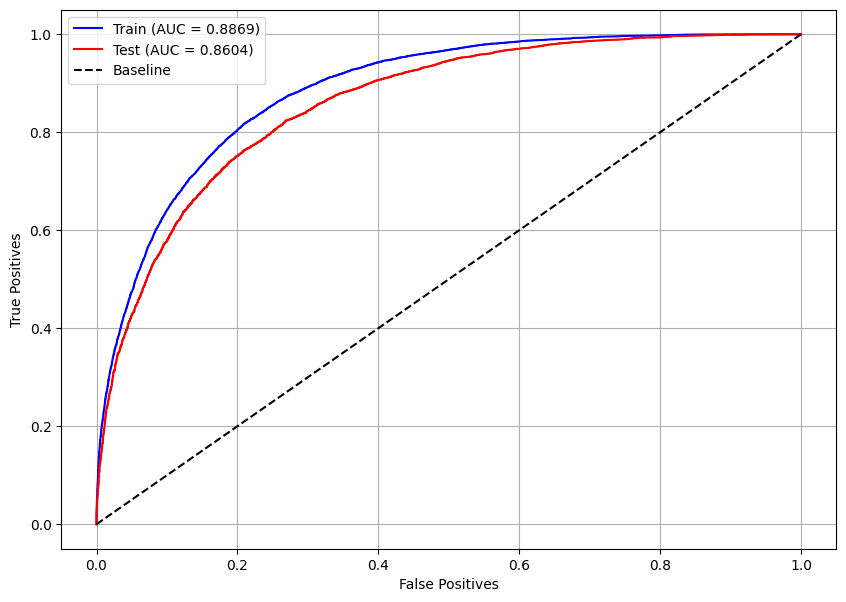

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm, X_train, X_test, y_train, y_test)

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


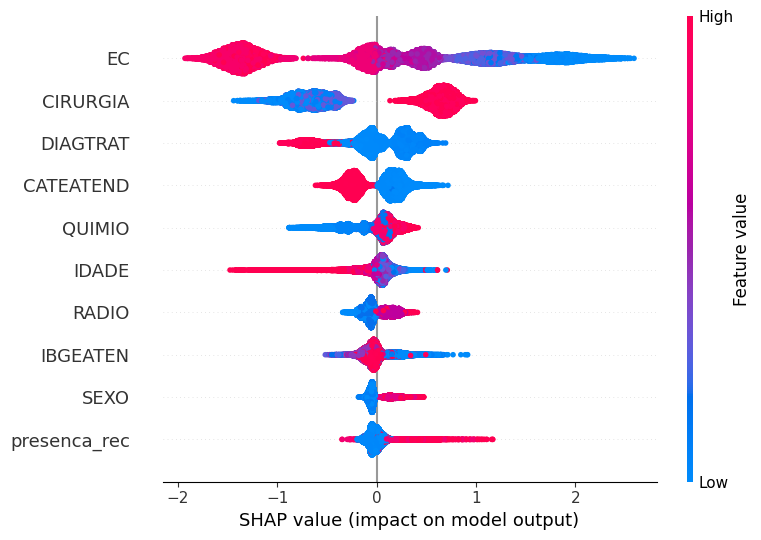

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(lgbm, X_train, feat_cols)

#### **Optuna**

In [ ]:
# Create stratified folds to maintain class proportions during cross-validation
skf = StratifiedKFold(10, shuffle=True, random_state=seed)

# Define the objective function for hyperparameter optimization
def objective(trial):
    """
    Objective function for Optuna to optimize an LightGBM classifier.
    Returns the mean accuracy across stratified folds.
    """

    # Suggest values for hyperparameters to be optimized
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Number of boosting rounds
    max_depth = trial.suggest_int('max_depth', 3, 10)  # Maximum tree depth
    learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2, step=0.01)  # Learning rate for updates
    min_child_weight = trial.suggest_int('min_child_weight', 1, 7)  # Minimum sum of instance weight in child nodes
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 0.7, step=0.1)  # Subsample ratio of features per tree

    # Initialize the LightGBM classifier with the suggested hyperparameters
    cls = LGBMClassifier(n_estimators=n_estimators,
                         max_depth=max_depth,
                         learning_rate=learning_rate,
                         min_child_weight=min_child_weight,
                         colsample_bytree=colsample_bytree,
                         random_state=seed,
                         verbose=-1,
                         n_jobs=-1)

    # Perform cross-validation and return the average accuracy
    return cross_val_score(cls, X_train, y_train,
                           cv=skf, scoring='accuracy').mean()

RandomSampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyLGBM = optuna.create_study(direction='maximize', sampler=RandomSampler(seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyLGBM.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyLGBM.best_params

{'n_estimators': 129,
 'max_depth': 8,
 'learning_rate': 0.12000000000000001,
 'min_child_weight': 7,
 'colsample_bytree': 0.6000000000000001}

In [ ]:
# Generate a range of candidate class_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(2.28, 2.32, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyLGBM.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['class_weight'] = {0:1, 1:i}  # Update the class weight parameter

    # Initialize a new LightGBM classifier with the updated hyperparameters
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Train the model on the training set
    lgbm_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = lgbm_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(lgbm_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

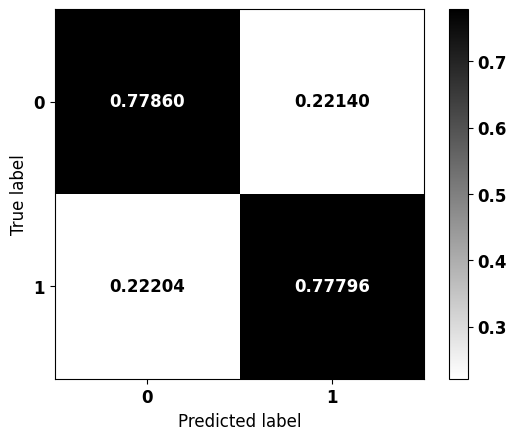


              precision    recall  f1-score   support

           0    0.89432   0.77860   0.83246     11608
           1    0.59284   0.77796   0.67290      4810

    accuracy                        0.77841     16418
   macro avg    0.74358   0.77828   0.75268     16418
weighted avg    0.80599   0.77841   0.78571     16418



In [ ]:
# Configure the final LightGBM model using the best-found hyperparameters
params = studyLGBM.best_params  # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed  # Fix the random seed for reproducibility
params['class_weight'] = {0:1, 1:2.312}  # Apply the chosen class imbalance weight

# Instantiate and configure the LightGBM classifier
lgbm_rand = LGBMClassifier(verbose=-1)
lgbm_rand.set_params(**params)

# Train the optimized model on the training dataset
lgbm_rand.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(lgbm_rand, X_test, y_test)

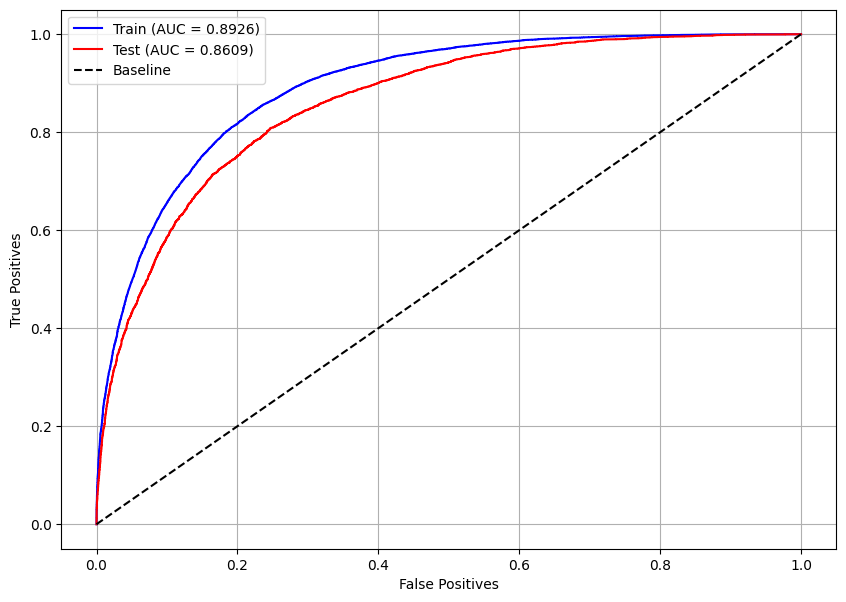

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm_rand, X_train, X_test, y_train, y_test)

TPESampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyLGBM = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyLGBM.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyLGBM.best_params

{'n_estimators': 113,
 'max_depth': 5,
 'learning_rate': 0.11,
 'min_child_weight': 7,
 'colsample_bytree': 0.7}

In [ ]:
# Generate a range of candidate class_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(2.26, 2.3, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyLGBM.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['class_weight'] = {0:1, 1:i}  # Update the class weight parameter

    # Initialize a new LightGBM classifier with the updated hyperparameters
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Train the model on the training set
    lgbm_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = lgbm_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(lgbm_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

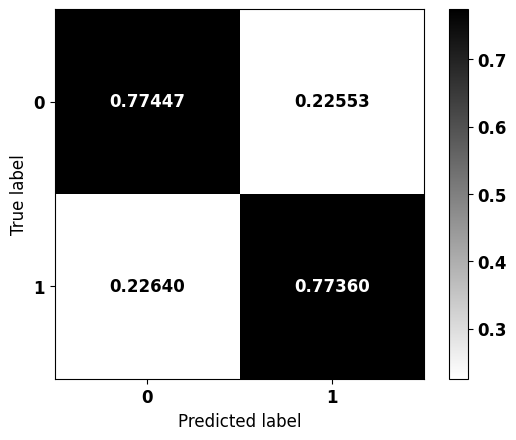


              precision    recall  f1-score   support

           0    0.89195   0.77447   0.82907     11608
           1    0.58700   0.77360   0.66750      4810

    accuracy                        0.77421     16418
   macro avg    0.73948   0.77403   0.74829     16418
weighted avg    0.80261   0.77421   0.78173     16418



In [ ]:
# Configure the final LightGBM model using the best-found hyperparameters
params = studyLGBM.best_params  # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed  # Fix the random seed for reproducibility
params['class_weight'] = {0:1, 1:2.287}  # Apply the chosen class imbalance weight

# Instantiate and configure the LightGBM classifier
lgbm_tpe = LGBMClassifier(verbose=-1)
lgbm_tpe.set_params(**params)

# Train the optimized model on the training dataset
lgbm_tpe.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(lgbm_tpe, X_test, y_test)

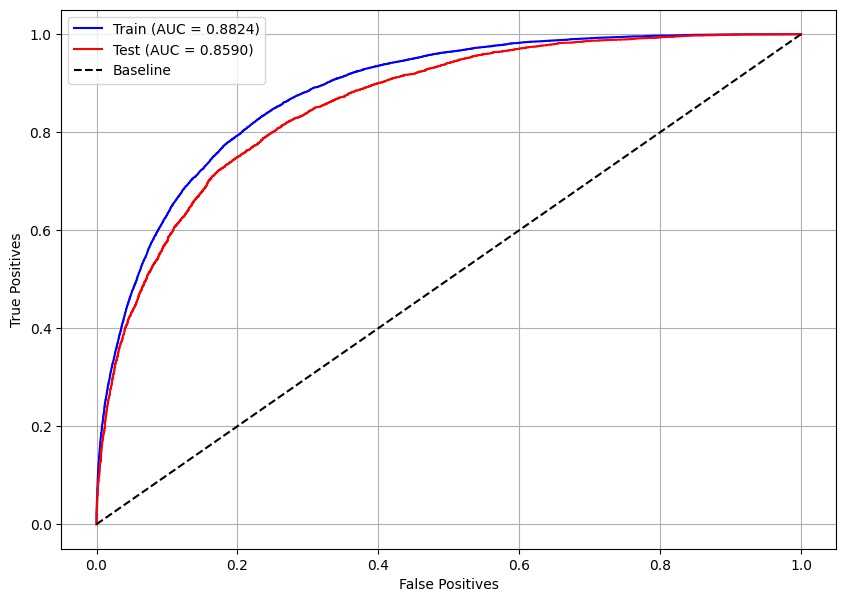

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm_tpe, X_train, X_test, y_train, y_test)

CmaEsSampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyLGBM = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed))
studyLGBM.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyLGBM.best_params

{'n_estimators': 127,
 'max_depth': 9,
 'learning_rate': 0.12000000000000001,
 'min_child_weight': 5,
 'colsample_bytree': 0.6000000000000001}

In [ ]:
# Generate a range of candidate class_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(2.29, 2.33, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyLGBM.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['class_weight'] = {0:1, 1:i}  # Update the class weight parameter

    # Initialize a new LightGBM classifier with the updated hyperparameters
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Train the model on the training set
    lgbm_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = lgbm_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(lgbm_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

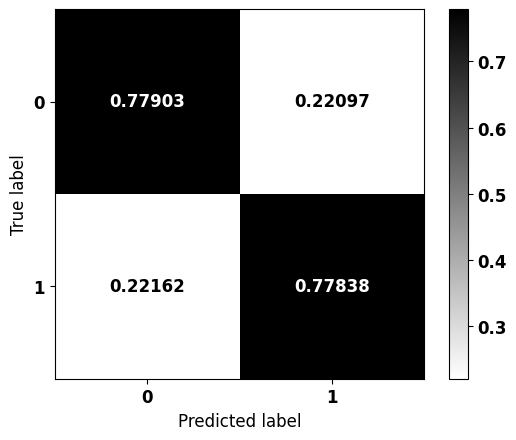


              precision    recall  f1-score   support

           0    0.89455   0.77903   0.83280     11608
           1    0.59344   0.77838   0.67344      4810

    accuracy                        0.77884     16418
   macro avg    0.74399   0.77871   0.75312     16418
weighted avg    0.80633   0.77884   0.78612     16418



In [ ]:
# Configure the final LightGBM model using the best-found hyperparameters
params = studyLGBM.best_params  # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed  # Fix the random seed for reproducibility
params['class_weight'] = {0:1, 1:2.301}  # Apply the chosen class imbalance weight

# Instantiate and configure the LightGBM classifier
lgbm_cma = LGBMClassifier(verbose=-1)
lgbm_cma.set_params(**params)

# Train the optimized model on the training dataset
lgbm_cma.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(lgbm_cma, X_test, y_test)

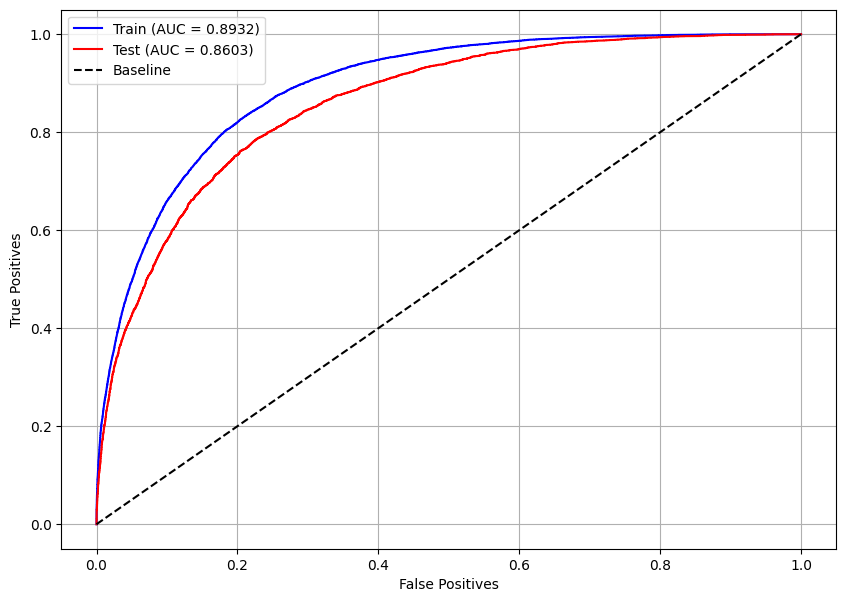

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm_cma, X_train, X_test, y_train, y_test)

**Optimized model**

In [ ]:
# Compare multiple LightGBM models and select the one with the highest test accuracy
models = [lgbm_rand, lgbm_tpe, lgbm_cma]  # List of trained models to evaluate
for i, m in enumerate(models):
    if i == 0:
        best = m  # Initialize the first model as the current best
    else:
        best_score = best.score(X_test, y_test)  # Accuracy of the current best model
        score = m.score(X_test, y_test)  # Accuracy of the model being evaluated
        if score > best_score:
            best = m  # Update 'best' if this model performs better

print(best)  # Output the model with the highest accuracy on the test set

LGBMClassifier(class_weight={0: 1, 1: 2.301}, colsample_bytree=0.6,
               learning_rate=0.12, max_depth=9, min_child_weight=5,
               n_estimators=127, random_state=7, verbose=-1)


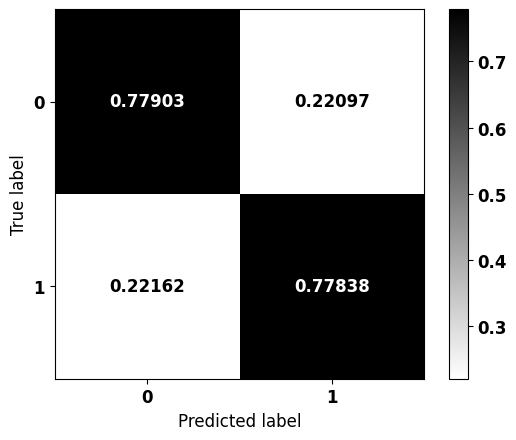


              precision    recall  f1-score   support

           0    0.89455   0.77903   0.83280     11608
           1    0.59344   0.77838   0.67344      4810

    accuracy                        0.77884     16418
   macro avg    0.74399   0.77871   0.75312     16418
weighted avg    0.80633   0.77884   0.78612     16418



In [ ]:
# Retrieve the hyperparameters from the selected best model
params = best.get_params()

# Initialize a new LightGBM classifier with those best hyperparameters
lgbm_optuna = LGBMClassifier(verbose=-1)
lgbm_optuna.set_params(**params)

# Train the optimized model on the training data
lgbm_optuna.fit(X_train, y_train)

# Plot the confusion matrix to evaluate the optimized model on the test data
plot_confusion_matrix(lgbm_optuna, X_test, y_test)

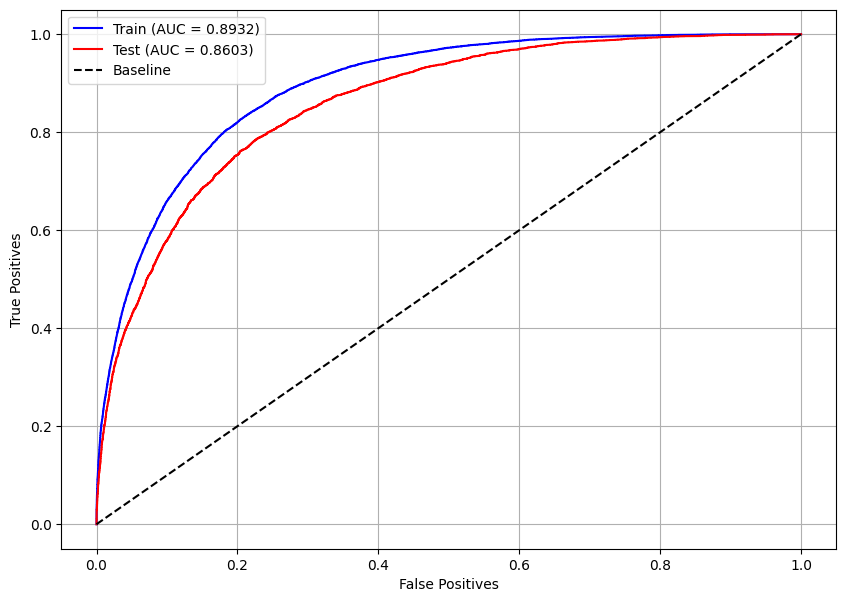

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm_optuna, X_train, X_test, y_train, y_test)

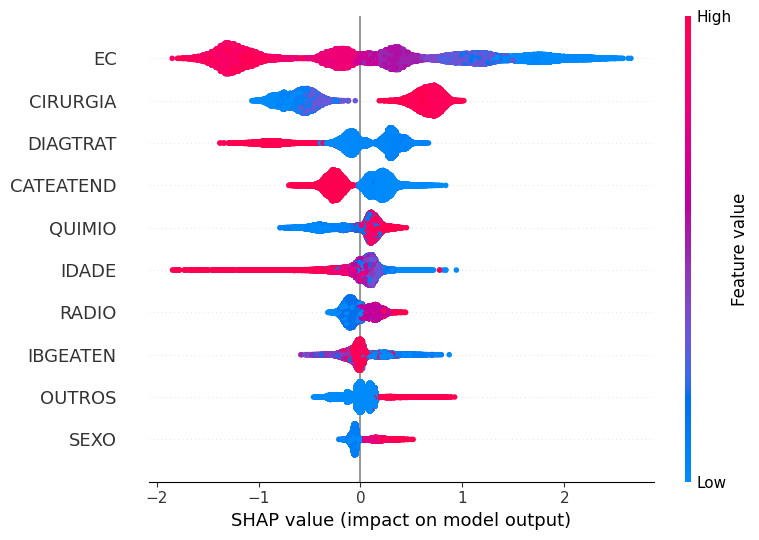

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(lgbm_optuna, X_train, feat_cols)

## **Cross Predictions**

In [ ]:
# Best Model Selection
models = [xgb, xgb_optuna, lgbm, lgbm_optuna]  # List of models to compare (XGBoost, optimized XGBoost, LightGBM, optimized LightGBM)

# Iterating through each model to find the best performing one
for i, m in enumerate(models):
    if i == 0:  # Initialize the best model as the first one
        best = m
    else:
        # Compare the performance of the current best model and the current model
        best_score = best.score(X_test, y_test)  # Get the accuracy of the current best model on the test set
        score = m.score(X_test, y_test)  # Get the accuracy of the current model on the test set
        if score > best_score:  # If the current model performs better, update the best model
            best = m

# Print the best performing model
print(best)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.4, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.15, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=147, n_jobs=None,
              num_parallel_tree=None, random_state=7, ...)


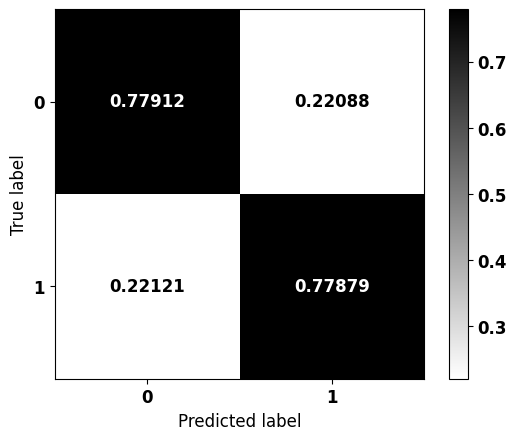


              precision    recall  f1-score   support

           0    0.89474   0.77912   0.83293     11608
           1    0.59366   0.77879   0.67374      4810

    accuracy                        0.77902     16418
   macro avg    0.74420   0.77896   0.75334     16418
weighted avg    0.80653   0.77902   0.78630     16418



In [ ]:
# Confusion Matrix for the Best Model
plot_confusion_matrix(best, X_test, y_test)  # Plot the normalized confusion matrix for the best model

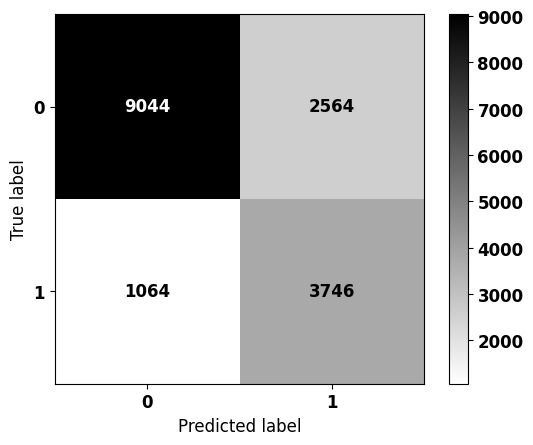


              precision    recall  f1-score   support

           0    0.89474   0.77912   0.83293     11608
           1    0.59366   0.77879   0.67374      4810

    accuracy                        0.77902     16418
   macro avg    0.74420   0.77896   0.75334     16418
weighted avg    0.80653   0.77902   0.78630     16418



In [ ]:
plot_confusion_matrix(best, X_test, y_test, norm=False)  # Plot the unnormalized confusion matrix for the best model

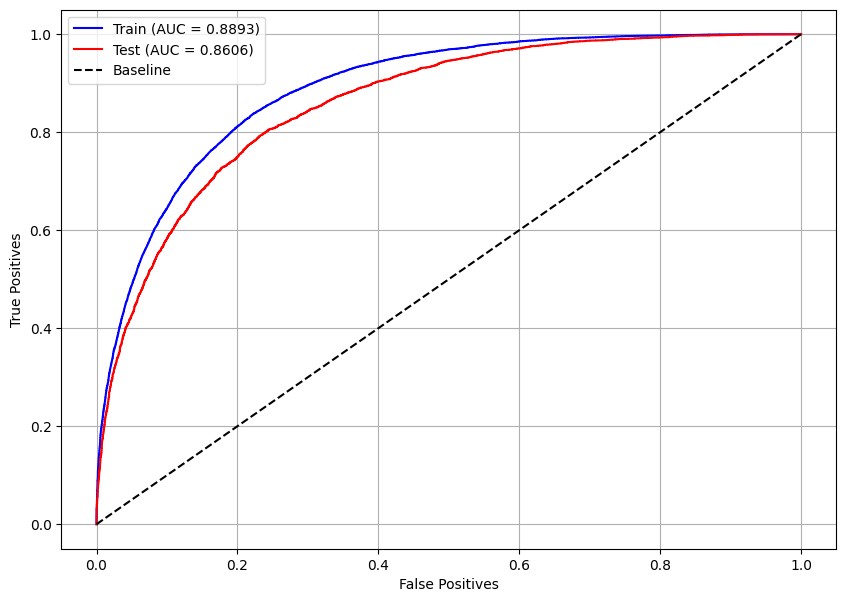

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(best, X_train, X_test, y_train, y_test)

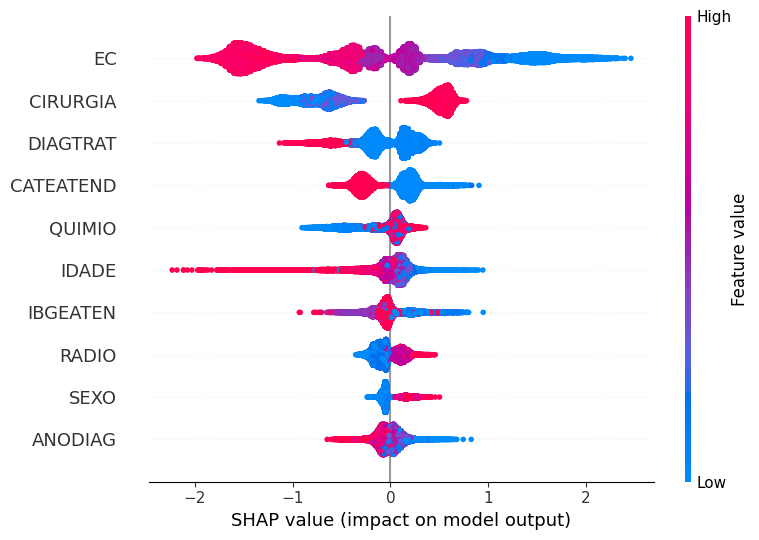

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(best, X_train, feat_cols)

In [ ]:
# Prepare test features and target for Esophagus Cancer
X_test_eso = eso_teste.drop(columns=list_drop).copy()  # Features for the Esophagus cancer test set
y_test_eso = eso_teste.sobrevida_3anos.copy()          # Target variable (3-year survival) for the Esophagus cancer test set

# Encode the 'TOPOGRUP' categorical column using the fitted OrdinalEncoder
X_test_eso['TOPOGRUP'] = oe.transform(X_test_eso[['TOPOGRUP']])

# Scale the encoded 'TOPOGRUP' values using the fitted StandardScaler
X_test_eso['TOPOGRUP'] = ss.transform(X_test_eso[['TOPOGRUP']])

# Prepare test features and target for Oral Cavity Cancer
X_test_boca = boca_teste.drop(columns=list_drop).copy()  # Features for the Oral Cavity cancer test set
y_test_boca = boca_teste.sobrevida_3anos.copy()          # Target variable (3-year survival) for the Oral Cavity cancer test set

# Encode the 'TOPOGRUP' categorical column using the fitted OrdinalEncoder
X_test_boca['TOPOGRUP'] = oe.transform(X_test_boca[['TOPOGRUP']])

# Scale the encoded 'TOPOGRUP' values using the fitted StandardScaler
X_test_boca['TOPOGRUP'] = ss.transform(X_test_boca[['TOPOGRUP']])

# Prepare test features and target for Stomach Cancer
X_test_esto = esto_teste.drop(columns=list_drop).copy()  # Features for the Stomach cancer test set
y_test_esto = esto_teste.sobrevida_3anos.copy()          # Target variable (3-year survival) for the Stomach cancer test set

# Encode the 'TOPOGRUP' categorical column using the fitted OrdinalEncoder
X_test_esto['TOPOGRUP'] = oe.transform(X_test_esto[['TOPOGRUP']])

# Scale the encoded 'TOPOGRUP' values using the fitted StandardScaler
X_test_esto['TOPOGRUP'] = ss.transform(X_test_esto[['TOPOGRUP']])

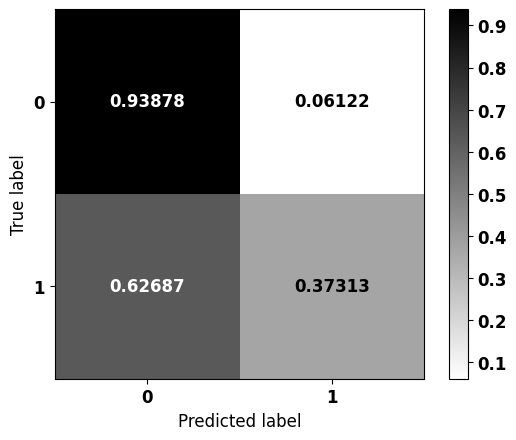


              precision    recall  f1-score   support

           0    0.90610   0.93878   0.92215      3022
           1    0.48611   0.37313   0.42220       469

    accuracy                        0.86279      3491
   macro avg    0.69611   0.65596   0.67217      3491
weighted avg    0.84968   0.86279   0.85498      3491



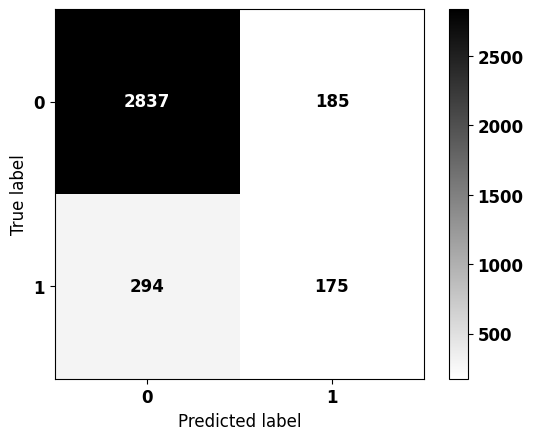


              precision    recall  f1-score   support

           0    0.90610   0.93878   0.92215      3022
           1    0.48611   0.37313   0.42220       469

    accuracy                        0.86279      3491
   macro avg    0.69611   0.65596   0.67217      3491
weighted avg    0.84968   0.86279   0.85498      3491



In [ ]:
# Plot the normalized confusion matrix for the best model on the Esophagus cancer test data
plot_confusion_matrix(best, X_test_eso, y_test_eso)

# Plot the raw (unnormalized) confusion matrix for the best model on the Esophagus cancer test data
plot_confusion_matrix(best, X_test_eso, y_test_eso, norm=False)

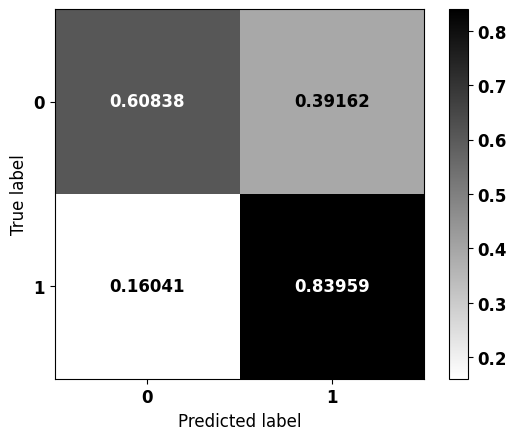


              precision    recall  f1-score   support

           0    0.84546   0.60838   0.70759      3534
           1    0.59779   0.83959   0.69835      2450

    accuracy                        0.70304      5984
   macro avg    0.72162   0.72398   0.70297      5984
weighted avg    0.74406   0.70304   0.70381      5984



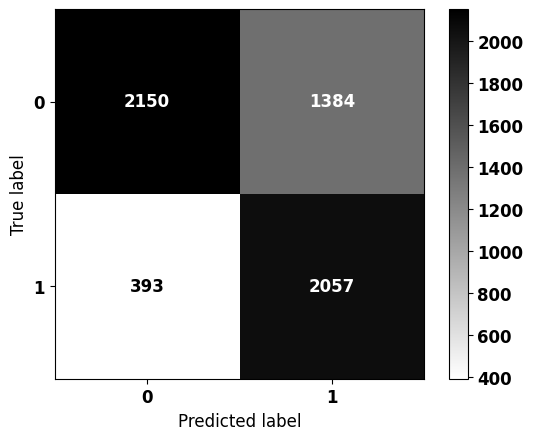


              precision    recall  f1-score   support

           0    0.84546   0.60838   0.70759      3534
           1    0.59779   0.83959   0.69835      2450

    accuracy                        0.70304      5984
   macro avg    0.72162   0.72398   0.70297      5984
weighted avg    0.74406   0.70304   0.70381      5984



In [ ]:
# Plot the normalized confusion matrix for the best model on the Oral Cavity cancer test data
plot_confusion_matrix(best, X_test_boca, y_test_boca)

# Plot the raw (unnormalized) confusion matrix for the best model on the Oral Cavity cancer test data
plot_confusion_matrix(best, X_test_boca, y_test_boca, norm=False)

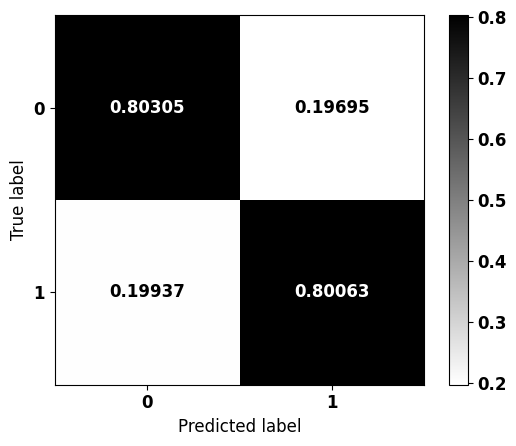


              precision    recall  f1-score   support

           0    0.91498   0.80305   0.85537      5052
           1    0.60343   0.80063   0.68818      1891

    accuracy                        0.80239      6943
   macro avg    0.75920   0.80184   0.77177      6943
weighted avg    0.83012   0.80239   0.80983      6943



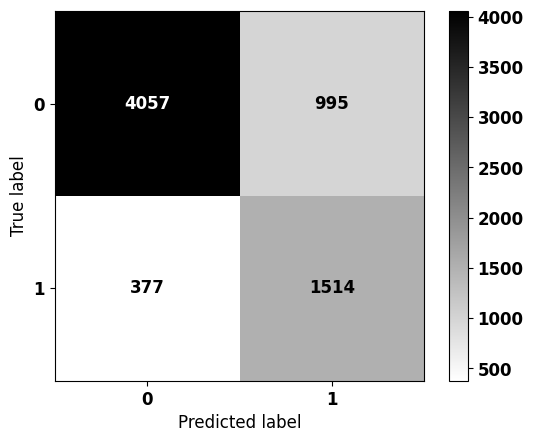


              precision    recall  f1-score   support

           0    0.91498   0.80305   0.85537      5052
           1    0.60343   0.80063   0.68818      1891

    accuracy                        0.80239      6943
   macro avg    0.75920   0.80184   0.77177      6943
weighted avg    0.83012   0.80239   0.80983      6943



In [ ]:
# Plot the normalized confusion matrix for the best model on the Stomach cancer test data
plot_confusion_matrix(best, X_test_esto, y_test_esto)

# Plot the raw (unnormalized) confusion matrix for the best model on the Stomach cancer test data
plot_confusion_matrix(best, X_test_esto, y_test_esto, norm=False)

## **Voting Classifier**


In [ ]:
# Comparing the accuracy scores of the initial XGBoost model and the optimized Optuna model
xgb_score = xgb.score(X_test, y_test)
optuna_score = xgb_optuna.score(X_test, y_test)
print(f'Accuracy: XGB = {xgb_score:.4f}, Optuna = {optuna_score:.4f}\n')

# Determine which model performed better
if optuna_score >= xgb_score:
    params_xgb = xgb_optuna.get_params()  # Get the parameters of the optimized model
    print('Optimized model won')
else:
    params_xgb = xgb.get_params()  # Get the parameters of the initial model
    print('Initial model won')

Accuracy: XGB = 0.7749, Optuna = 0.7790

Otimizado venceu


In [ ]:
# Comparing the accuracy scores of the initial LightGBM model and the optimized Optuna model
lgbm_score = lgbm.score(X_test, y_test)
optuna_score = lgbm_optuna.score(X_test, y_test)
print(f'Accuracy: LGBM = {lgbm_score:.4f}, Optuna = {optuna_score:.4f}\n')

# Determine which model performed better
if optuna_score >= lgbm_score:
    params_lgbm = lgbm_optuna.get_params()  # Get the parameters of the optimized model
    print('Optimized model won')
else:
    params_lgbm = lgbm.get_params()  # Get the parameters of the initial model
    print('Initial model won')

Accuracy: LGBM = 0.7750, Optuna = 0.7788

Otimizado venceu


In [ ]:
# Creating the models with the best-performing hyperparameters
# XGBoost Model
best_xgb = XGBClassifier()  # Instantiate the XGBoost classifier
best_xgb.set_params(**params_xgb)  # Set the best hyperparameters for XGBoost

# LightGBM Model
best_lgbm = LGBMClassifier()  # Instantiate the LightGBM classifier
best_lgbm.set_params(**params_lgbm)  # Set the best hyperparameters for LightGBM

LGBMClassifier(class_weight={0: 1, 1: 2.301}, colsample_bytree=0.6,
               learning_rate=0.12, max_depth=9, min_child_weight=5,
               n_estimators=127, random_state=7, verbose=-1)

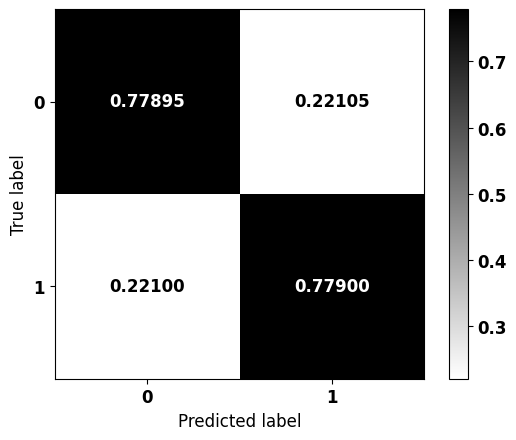


              precision    recall  f1-score   support

           0    0.89480   0.77895   0.83287     11608
           1    0.59354   0.77900   0.67374      4810

    accuracy                        0.77896     16418
   macro avg    0.74417   0.77897   0.75330     16418
weighted avg    0.80654   0.77896   0.78625     16418



In [ ]:
from sklearn.ensemble import VotingClassifier

# Creating and training the voting classifier model
clf = VotingClassifier(
    estimators=[('XGBoost', best_xgb),  # Adding the best XGBoost model
               ('LightGBM', best_lgbm)],  # Adding the best LightGBM model
    voting='soft'  # Using 'soft' voting, which predicts the class label based on predicted probabilities
)

clf.fit(X_train, y_train)  # Train the voting classifier on the training data

# Confusion Matrix
plot_confusion_matrix(clf, X_test, y_test)  # Plot the confusion matrix for the voting classifier on the test data

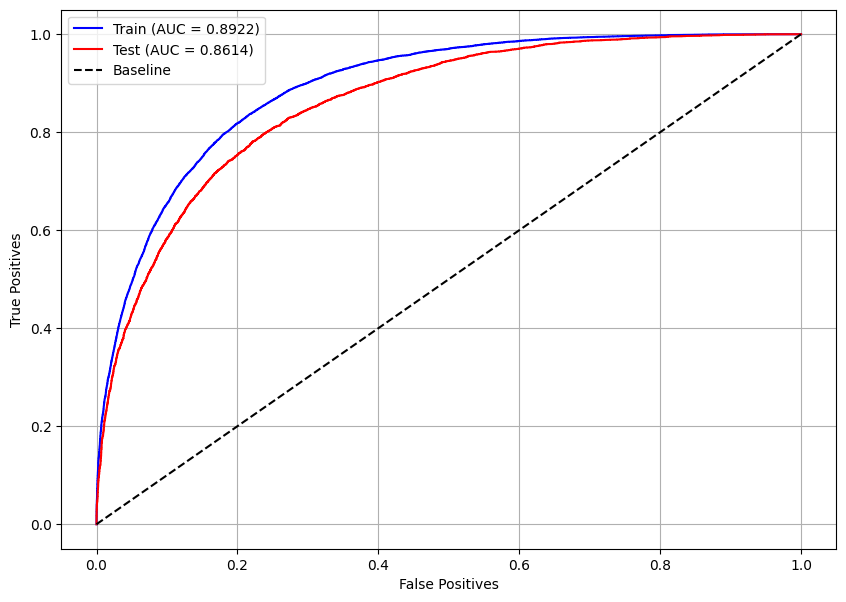

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(clf, X_train, X_test, y_train, y_test)

# **Small Intestine with Oral Cavity e Stomach**

In [ ]:
# Topographies for group 4
df4_treino.TOPOGRUP.value_counts()

,count
TOPOGRUP,
Estômago,20827
Boca,17951
Delgado,1195


In [ ]:
# Missing values
df4_treino.isna().sum().sort_values(ascending=False)

,0
IDADE,0
SEXO,0
IBGE,0
CATEATEND,0
DIAGPREV,0
EC,0
CIRURGIA,0
RADIO,0
QUIMIO,0
HORMONIO,0


In [ ]:
# Count the number of patients in each class of the target variable 'sobrevida_ano3'
df4_treino.sobrevida_3anos.value_counts()

,count
sobrevida_3anos,
0,26419
1,13554


## **Preprocessing**

In [ ]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Initialize an OrdinalEncoder to convert categorical 'TOPOGRUP' values to integer codes,
# and assign -1 to any categories not seen during fitting
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit the encoder on the training set and transform its 'TOPOGRUP' column
df4_treino['TOPOGRUP'] = oe.fit_transform(df4_treino[['TOPOGRUP']])

# Transform the test set's 'TOPOGRUP' column using the already-fitted encoder
df4_teste['TOPOGRUP'] = oe.transform(df4_teste[['TOPOGRUP']])

# Initialize a StandardScaler to standardize the feature (zero mean, unit variance)
ss = StandardScaler()

# Fit the scaler on the training set's encoded 'TOPOGRUP' values and apply the transformation
df4_treino['TOPOGRUP'] = ss.fit_transform(df4_treino[['TOPOGRUP']])

# Apply the same scaling transformation to the test set's encoded 'TOPOGRUP' values
df4_teste['TOPOGRUP'] = ss.transform(df4_teste[['TOPOGRUP']])

In [ ]:
# Define the column to drop (the target variable)
list_drop = ['sobrevida_3anos']

# Prepare training features and target
X_train = df4_treino.drop(columns=list_drop).copy()  # Features for the training set
y_train = df4_treino.sobrevida_3anos.copy()          # Target variable for the training set

# Prepare test features and target
X_test = df4_teste.drop(columns=list_drop).copy()   # Features for the test set
y_test = df4_teste.sobrevida_3anos.copy()           # Target variable for the test set

# Display the shapes of the training and test splits
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((39973, 24), (39973,), (13326, 24), (13326,))

In [ ]:
# Feature columns
feat_cols = X_train.columns
feat_cols

Index(['IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV', 'EC', 'CIRURGIA',
       'RADIO', 'QUIMIO', 'HORMONIO', 'TMO', 'IMUNO', 'OUTROS', 'CONSDIAG',
       'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'IBGEATEN', 'HABILIT2',
       'ESCOLARI_preench', 'IBGE_idem_IBGEATEN', 'presenca_rec', 'TOPOGRUP'],
      dtype='object')

## **Machine learning models**

### **XGBoost**


#### **Base model**

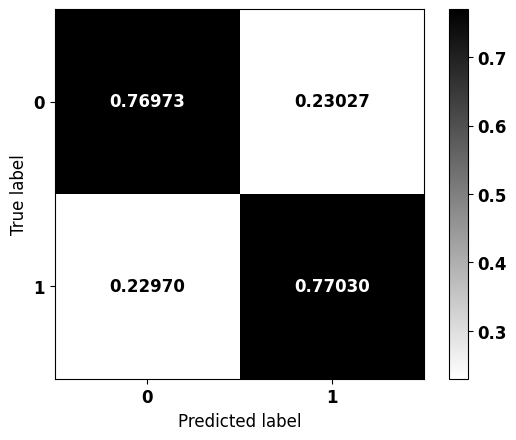


              precision    recall  f1-score   support

           0    0.86721   0.76973   0.81557      8807
           1    0.63188   0.77030   0.69426      4519

    accuracy                        0.76992     13326
   macro avg    0.74954   0.77002   0.75491     13326
weighted avg    0.78741   0.76992   0.77443     13326



In [ ]:
# Create and train the XGBoost classifier
xgb = XGBClassifier(max_depth=4,            # Set maximum tree depth to 4
                    scale_pos_weight=1.77,  # Balance positive and negative classes
                    random_state=seed)      # Ensure reproducibility with a fixed random seed

xgb.fit(X_train, y_train)  # Train the model on the training data

# Plot the confusion matrix to evaluate model performance on the test set
plot_confusion_matrix(xgb, X_test, y_test)

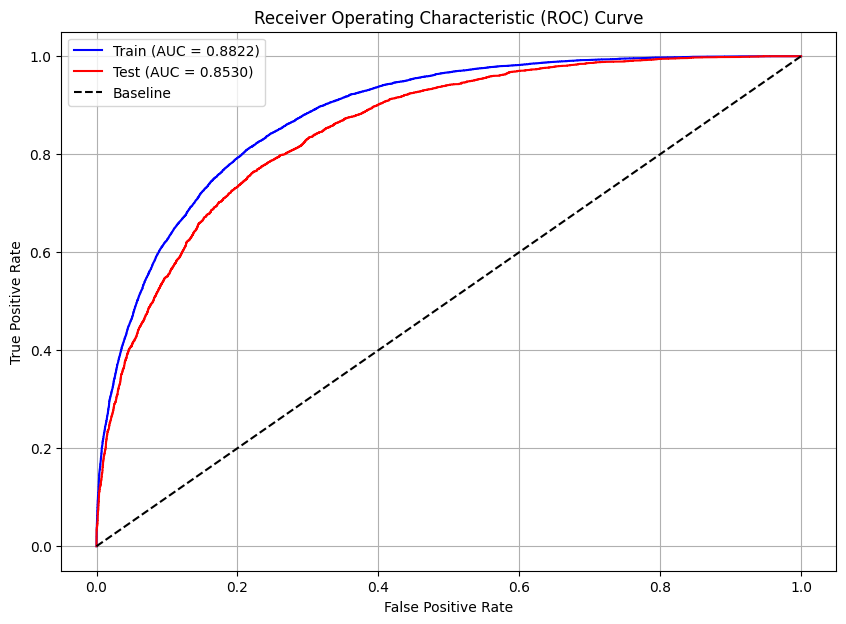

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb, X_train, X_test, y_train, y_test)

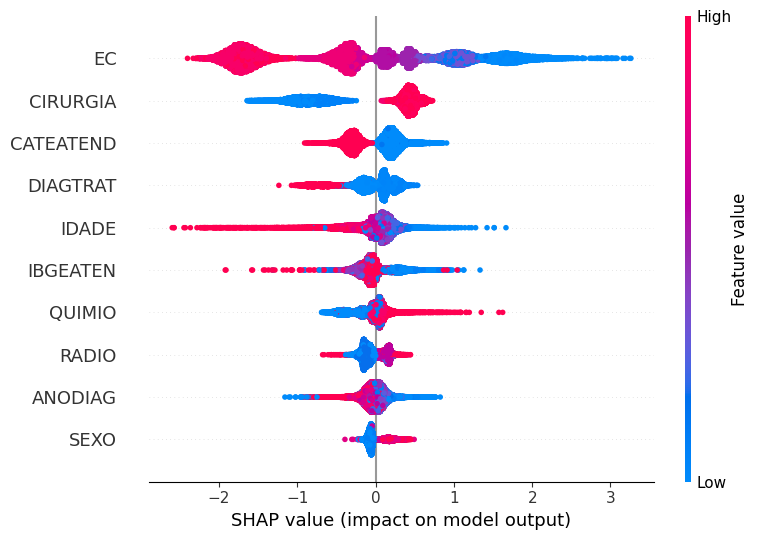

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(xgb, X_train, feat_cols)

#### **Optuna**

In [ ]:
# Create stratified folds to maintain class proportions during cross-validation
skf = StratifiedKFold(10, shuffle=True, random_state=seed)

# Define the objective function for hyperparameter optimization
def objective(trial):
    """
    Objective function for Optuna to optimize an XGBoost classifier.
    Returns the mean accuracy across stratified folds.
    """

    # Suggest values for hyperparameters to be optimized
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Number of boosting rounds
    max_depth = trial.suggest_int('max_depth', 3, 5)  # Maximum tree depth
    learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2, step=0.05)  # Learning rate for updates
    gamma = trial.suggest_float('gamma', 0.0, 0.3, step=0.1)  # Minimum loss reduction for tree splits
    min_child_weight = trial.suggest_int('min_child_weight', 1, 7)  # Minimum sum of instance weight in child nodes
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 0.7, step=0.1)  # Subsample ratio of features per tree

    # Initialize the XGBoost classifier with the suggested hyperparameters
    cls = XGBClassifier(n_estimators=n_estimators,
                        max_depth=max_depth,
                        learning_rate=learning_rate,
                        gamma=gamma,
                        min_child_weight=min_child_weight,
                        colsample_bytree=colsample_bytree,
                        random_state=seed,
                        n_jobs=-1)

    # Perform cross-validation and return the average accuracy
    return cross_val_score(cls, X_train, y_train,
                           cv=skf, scoring='accuracy').mean()

RandomSampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyXGB = optuna.create_study(direction='maximize', sampler=RandomSampler(seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyXGB.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyXGB.best_params

{'n_estimators': 109,
 'max_depth': 5,
 'learning_rate': 0.15000000000000002,
 'gamma': 0.0,
 'min_child_weight': 6,
 'colsample_bytree': 0.6000000000000001}

In [ ]:
# Generate a range of candidate scale_pos_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(1.73, 1.76, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyXGB.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['scale_pos_weight'] = i  # Update the class weight parameter

    # Initialize a new XGBoost classifier with the updated hyperparameters
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Train the model on the training set
    xgb_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = xgb_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(xgb_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

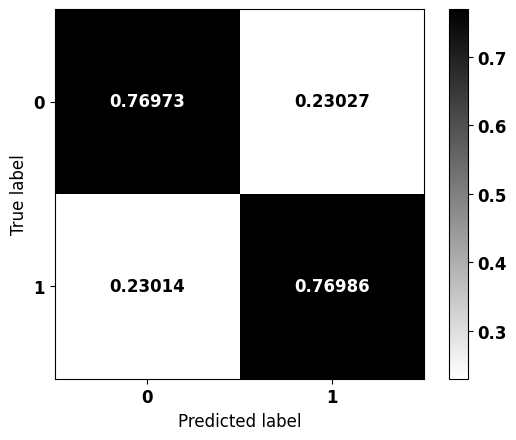


              precision    recall  f1-score   support

           0    0.86699   0.76973   0.81547      8807
           1    0.63174   0.76986   0.69400      4519

    accuracy                        0.76977     13326
   macro avg    0.74937   0.76979   0.75473     13326
weighted avg    0.78721   0.76977   0.77428     13326



In [ ]:
# Configure the final XGBoost model using the best-found hyperparameters
params = studyXGB.best_params           # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed           # Fix the random seed for reproducibility
params['scale_pos_weight'] = 1.745      # Apply the chosen class imbalance weight

# Instantiate and configure the XGBoost classifier
xgb_rand = XGBClassifier()
xgb_rand.set_params(**params)

# Train the optimized model on the training dataset
xgb_rand.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(xgb_rand, X_test, y_test)

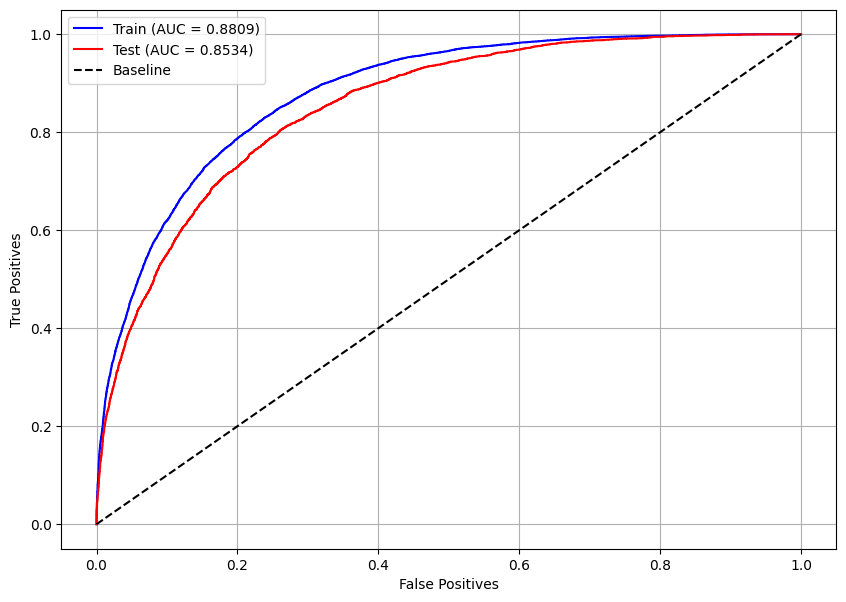

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb_rand, X_train, X_test, y_train, y_test)

TPESampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyXGB = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyXGB.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyXGB.best_params

{'n_estimators': 147,
 'max_depth': 5,
 'learning_rate': 0.1,
 'gamma': 0.2,
 'min_child_weight': 7,
 'colsample_bytree': 0.4}

In [ ]:
# Generate a range of candidate scale_pos_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(1.73, 1.76, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyXGB.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['scale_pos_weight'] = i  # Update the class weight parameter

    # Initialize a new XGBoost classifier with the updated hyperparameters
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Train the model on the training set
    xgb_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = xgb_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(xgb_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

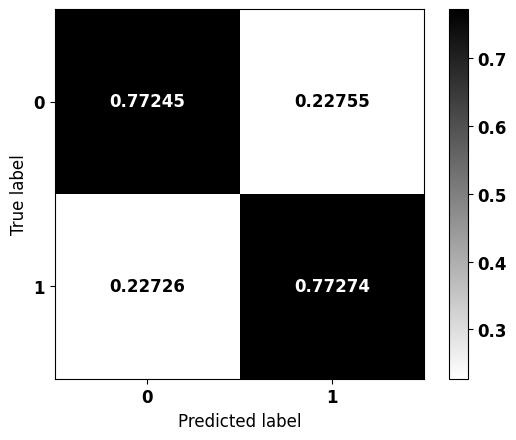


              precision    recall  f1-score   support

           0    0.86884   0.77245   0.81782      8807
           1    0.63537   0.77274   0.69735      4519

    accuracy                        0.77255     13326
   macro avg    0.75210   0.77260   0.75758     13326
weighted avg    0.78967   0.77255   0.77697     13326



In [ ]:
# Configure the final XGBoost model using the best-found hyperparameters
params = studyXGB.best_params           # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed           # Fix the random seed for reproducibility
params['scale_pos_weight'] = 1.737      # Apply the chosen class imbalance weight

# Instantiate and configure the XGBoost classifier
xgb_tpe = XGBClassifier()
xgb_tpe.set_params(**params)

# Train the optimized model on the training dataset
xgb_tpe.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(xgb_tpe, X_test, y_test)

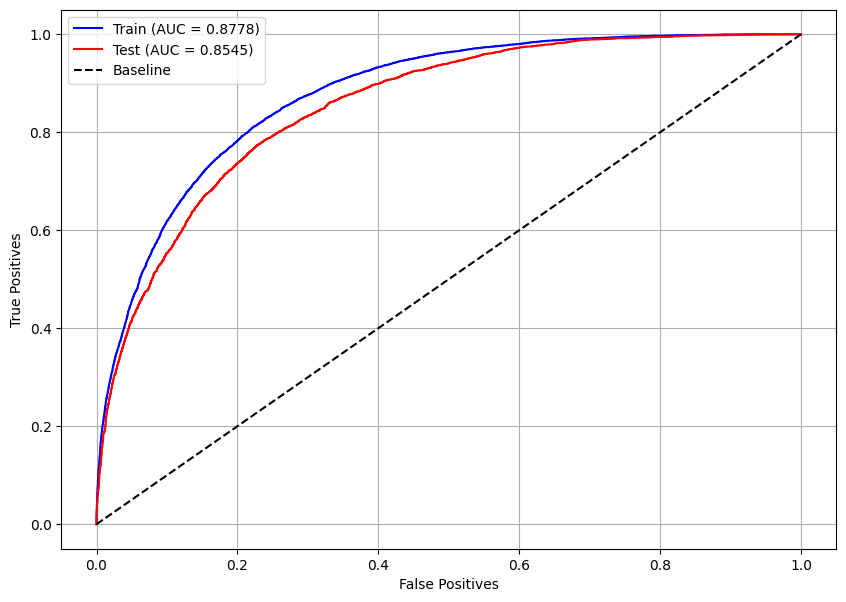

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb_tpe, X_train, X_test, y_train, y_test)

CmaEsSampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyXGB = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyXGB.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyXGB.best_params

{'n_estimators': 138,
 'max_depth': 5,
 'learning_rate': 0.1,
 'gamma': 0.1,
 'min_child_weight': 4,
 'colsample_bytree': 0.4}

In [ ]:
# Generate a range of candidate scale_pos_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(1.73, 1.76, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyXGB.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['scale_pos_weight'] = i  # Update the class weight parameter

    # Initialize a new XGBoost classifier with the updated hyperparameters
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Train the model on the training set
    xgb_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = xgb_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(xgb_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

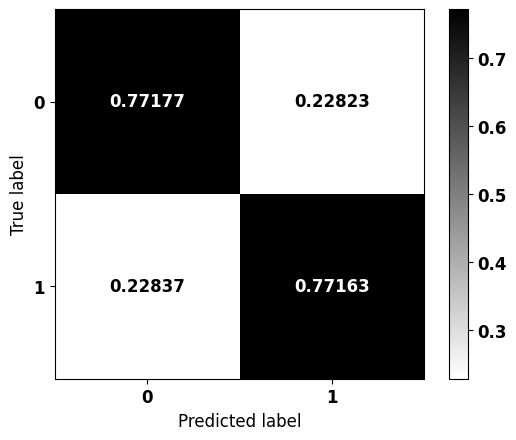


              precision    recall  f1-score   support

           0    0.86818   0.77177   0.81714      8807
           1    0.63435   0.77163   0.69629      4519

    accuracy                        0.77172     13326
   macro avg    0.75126   0.77170   0.75671     13326
weighted avg    0.78889   0.77172   0.77616     13326



In [ ]:
# Configure the final XGBoost model using the best-found hyperparameters
params = studyXGB.best_params           # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed           # Fix the random seed for reproducibility
params['scale_pos_weight'] = 1.74       # Apply the chosen class imbalance weight

# Instantiate and configure the XGBoost classifier
xgb_cma = XGBClassifier()
xgb_cma.set_params(**params)

# Train the optimized model on the training dataset
xgb_cma.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(xgb_cma, X_test, y_test)

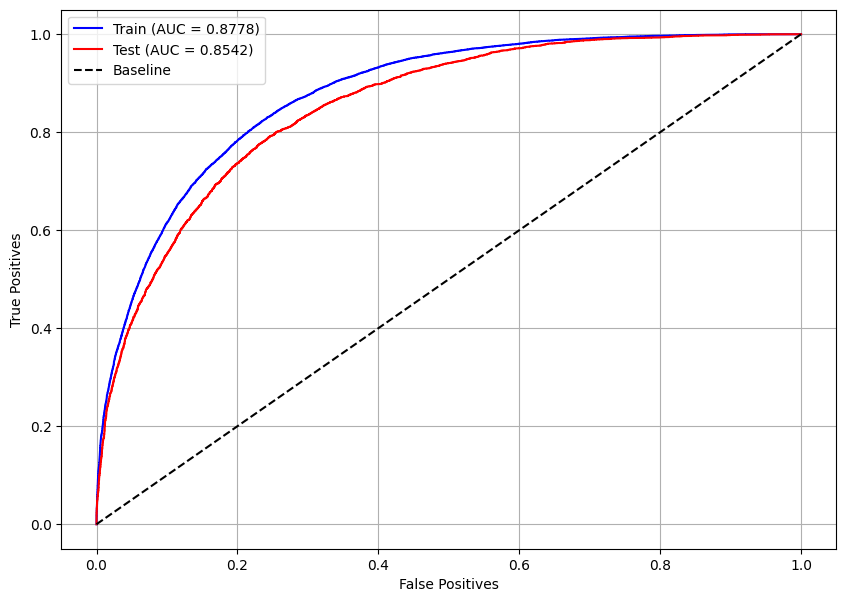

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb_cma, X_train, X_test, y_train, y_test)

**Optimized model**

In [ ]:
# Compare multiple XGBoost models and select the one with the highest test accuracy
models = [xgb_rand, xgb_tpe, xgb_cma]  # List of trained models to evaluate

for i, m in enumerate(models):
    if i == 0:
        best = m  # Initialize the first model as the current best
    else:
        best_score = best.score(X_test, y_test)  # Accuracy of the current best model
        score = m.score(X_test, y_test)          # Accuracy of the model being evaluated
        if score > best_score:
            best = m  # Update 'best' if this model performs better

print(best)  # Output the model with the highest accuracy on the test set

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.4, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.2, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=147, n_jobs=None,
              num_parallel_tree=None, random_state=7, ...)


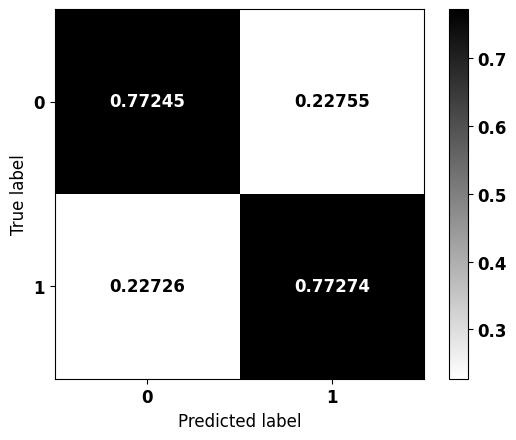


              precision    recall  f1-score   support

           0    0.86884   0.77245   0.81782      8807
           1    0.63537   0.77274   0.69735      4519

    accuracy                        0.77255     13326
   macro avg    0.75210   0.77260   0.75758     13326
weighted avg    0.78967   0.77255   0.77697     13326



In [ ]:
# Retrieve the hyperparameters from the selected best model
params = best.get_params()

# Initialize a new XGBoost classifier with those best hyperparameters
xgb_optuna = XGBClassifier()
xgb_optuna.set_params(**params)

# Train the optimized model on the training data
xgb_optuna.fit(X_train, y_train)

# Plot the confusion matrix to evaluate the optimized model on the test data
plot_confusion_matrix(xgb_optuna, X_test, y_test)

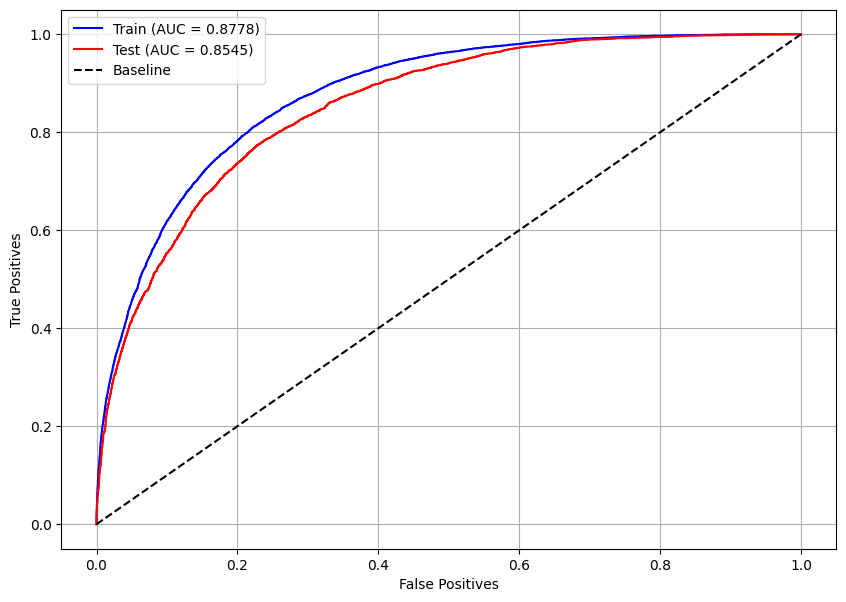

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb_optuna, X_train, X_test, y_train, y_test)

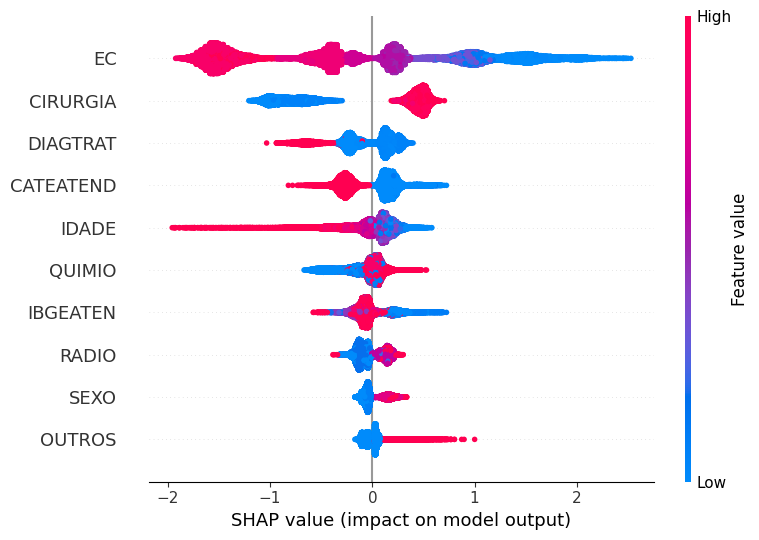

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(xgb_optuna, X_train, feat_cols)

### **LightGBM**


#### **Base model**

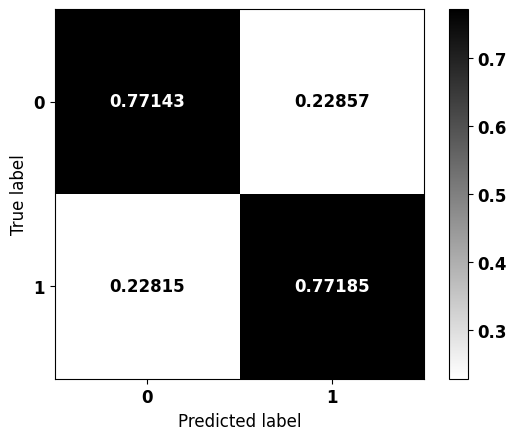


              precision    recall  f1-score   support

           0    0.86824   0.77143   0.81698      8807
           1    0.63407   0.77185   0.69621      4519

    accuracy                        0.77157     13326
   macro avg    0.75115   0.77164   0.75659     13326
weighted avg    0.78883   0.77157   0.77602     13326



In [ ]:
# Create and train the LightGBM classifier
lgbm = LGBMClassifier(max_depth=10,                 # Set maximum tree depth to 10
                      class_weight={0:1, 1:1.7374}, # Balance positive and negative classes
                      random_state=seed,            # Ensure reproducibility with a fixed random seed
                      verbose=-1)

lgbm.fit(X_train, y_train)  # Train the model on the training data

# Plot the confusion matrix to evaluate model performance on the test set
plot_confusion_matrix(lgbm, X_test, y_test)

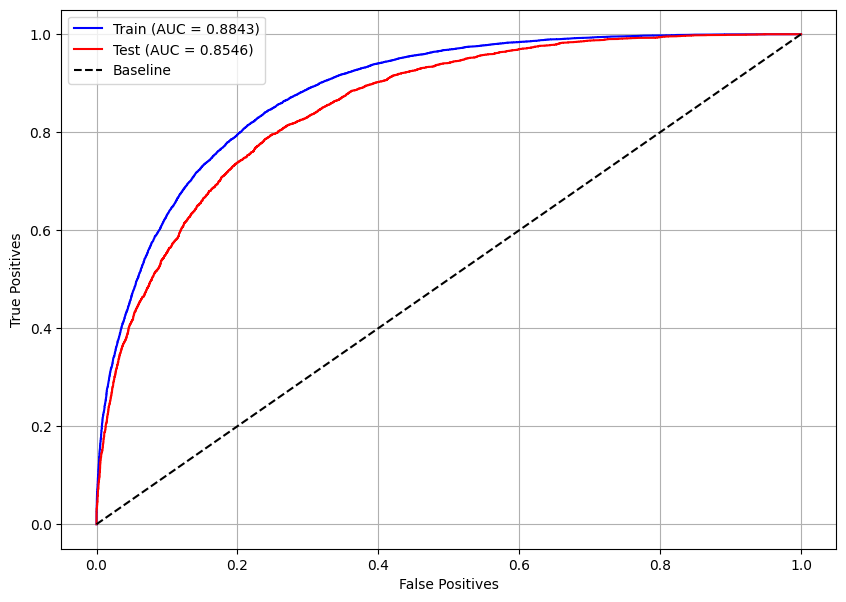

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm, X_train, X_test, y_train, y_test)

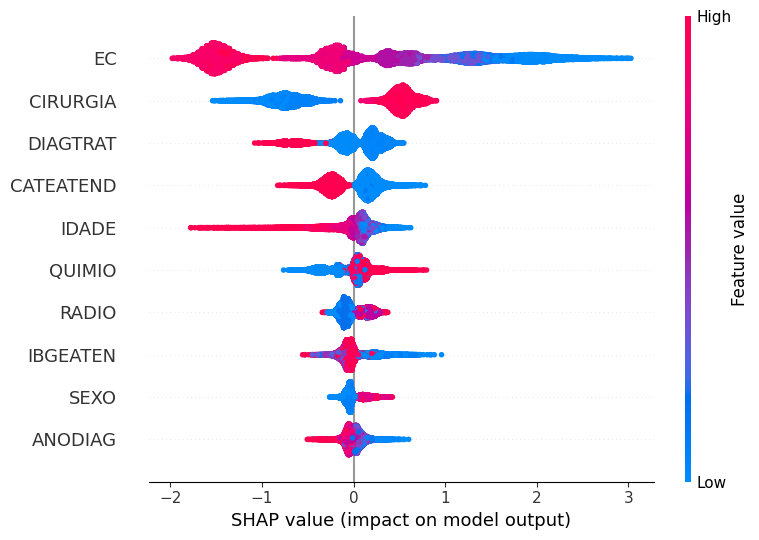

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(lgbm, X_train, feat_cols)

#### **Optuna**

In [ ]:
# Create stratified folds to maintain class proportions during cross-validation
skf = StratifiedKFold(10, shuffle=True, random_state=seed)

# Define the objective function for hyperparameter optimization
def objective(trial):
    """
    Objective function for Optuna to optimize an LightGBM classifier.
    Returns the mean accuracy across stratified folds.
    """

    # Suggest values for hyperparameters to be optimized
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Number of boosting rounds
    max_depth = trial.suggest_int('max_depth', 3, 10)  # Maximum tree depth
    learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2, step=0.01)  # Learning rate for updates
    min_child_weight = trial.suggest_int('min_child_weight', 1, 7)  # Minimum sum of instance weight in child nodes
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 0.7, step=0.1)  # Subsample ratio of features per tree

    # Initialize the LightGBM classifier with the suggested hyperparameters
    cls = LGBMClassifier(n_estimators=n_estimators,
                         max_depth=max_depth,
                         learning_rate=learning_rate,
                         min_child_weight=min_child_weight,
                         colsample_bytree=colsample_bytree,
                         random_state=seed,
                         verbose=-1,
                         n_jobs=-1)

    # Perform cross-validation and return the average accuracy
    return cross_val_score(cls, X_train, y_train,
                           cv=skf, scoring='accuracy').mean()

RandomSampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyLGBM = optuna.create_study(direction='maximize', sampler=RandomSampler(seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyLGBM.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyLGBM.best_params

{'n_estimators': 87,
 'max_depth': 8,
 'learning_rate': 0.1,
 'min_child_weight': 1,
 'colsample_bytree': 0.7}

In [ ]:
# Generate a range of candidate class_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(1.7, 1.73, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyLGBM.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['class_weight'] = {0:1, 1:i}  # Update the class weight parameter

    # Initialize a new LightGBM classifier with the updated hyperparameters
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Train the model on the training set
    lgbm_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = lgbm_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(lgbm_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

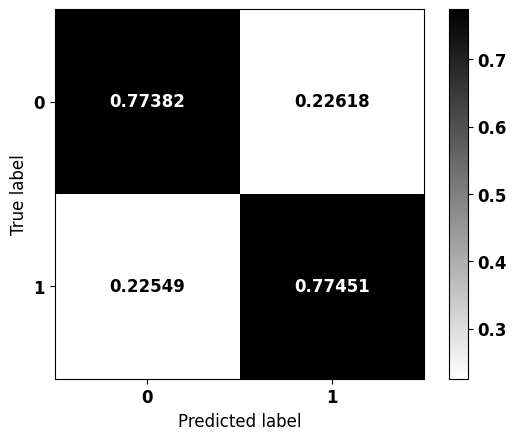


              precision    recall  f1-score   support

           0    0.86993   0.77382   0.81906      8807
           1    0.63729   0.77451   0.69923      4519

    accuracy                        0.77405     13326
   macro avg    0.75361   0.77416   0.75915     13326
weighted avg    0.79104   0.77405   0.77843     13326



In [ ]:
# Configure the final LightGBM model using the best-found hyperparameters
params = studyLGBM.best_params  # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed  # Fix the random seed for reproducibility
params['class_weight'] = {0:1, 1:1.716}  # Apply the chosen class imbalance weight

# Instantiate and configure the LightGBM classifier
lgbm_random = LGBMClassifier(verbose=-1)
lgbm_random.set_params(**params)

# Train the optimized model on the training dataset
lgbm_random.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(lgbm_random, X_test, y_test)

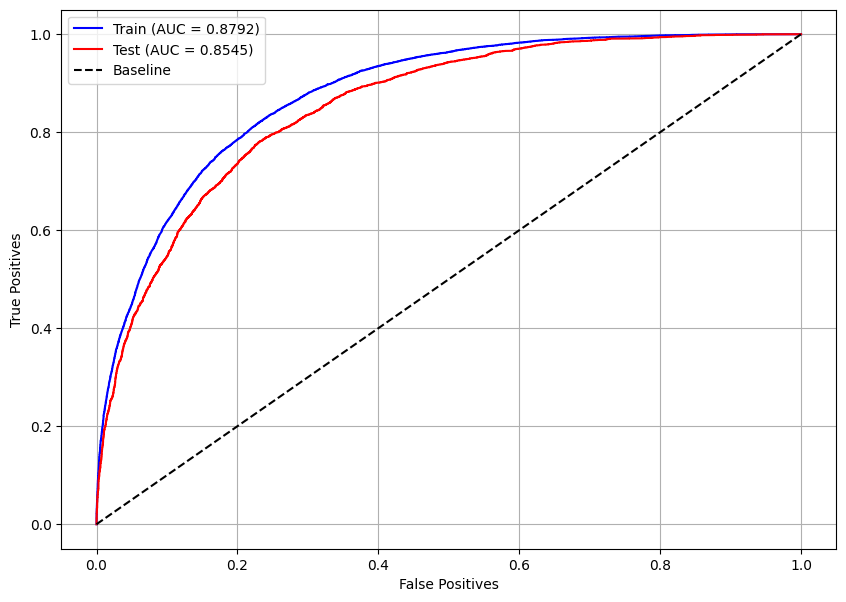

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm_random, X_train, X_test, y_train, y_test)

TPESampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyLGBM = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyLGBM.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyLGBM.best_params

{'n_estimators': 125,
 'max_depth': 10,
 'learning_rate': 0.11,
 'min_child_weight': 4,
 'colsample_bytree': 0.6000000000000001}

In [ ]:
# Generate a range of candidate class_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(1.73, 1.77, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyLGBM.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['class_weight'] = {0:1, 1:i}  # Update the class weight parameter

    # Initialize a new LightGBM classifier with the updated hyperparameters
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Train the model on the training set
    lgbm_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = lgbm_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(lgbm_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

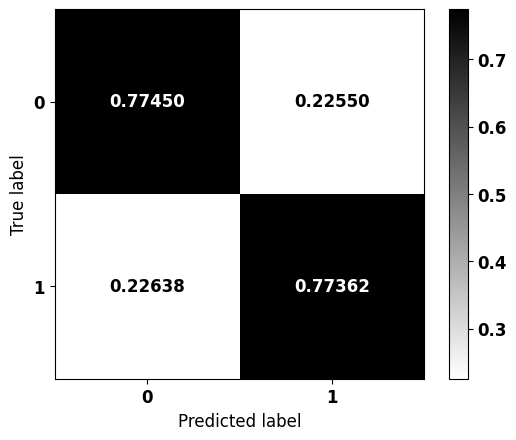


              precision    recall  f1-score   support

           0    0.86958   0.77450   0.81929      8807
           1    0.63772   0.77362   0.69913      4519

    accuracy                        0.77420     13326
   macro avg    0.75365   0.77406   0.75921     13326
weighted avg    0.79096   0.77420   0.77854     13326



In [ ]:
# Configure the final LightGBM model using the best-found hyperparameters
params = studyLGBM.best_params  # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed  # Fix the random seed for reproducibility
params['class_weight'] = {0:1, 1:1.746}  # Apply the chosen class imbalance weight

# Instantiate and configure the LightGBM classifier
lgbm_tpe = LGBMClassifier(verbose=-1)
lgbm_tpe.set_params(**params)

# Train the optimized model on the training dataset
lgbm_tpe.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(lgbm_tpe, X_test, y_test)

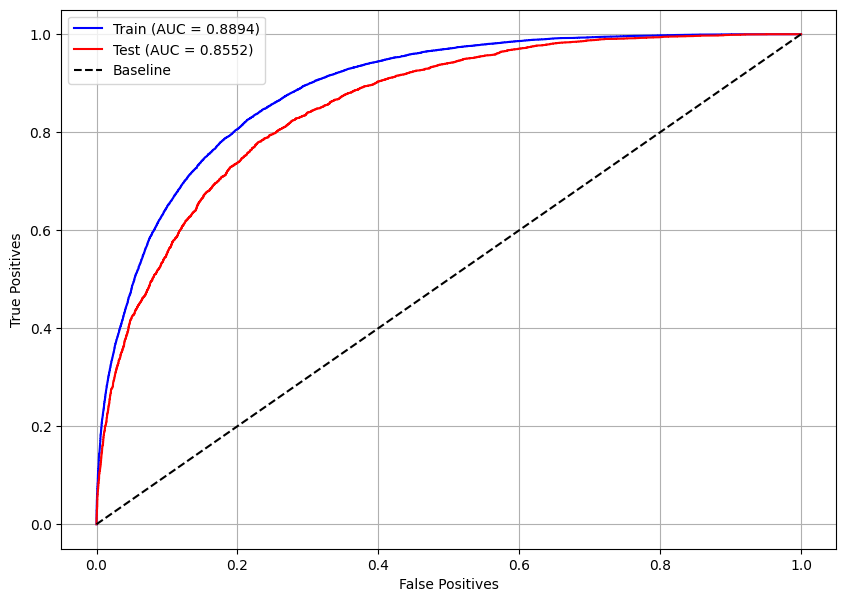

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm_tpe, X_train, X_test, y_train, y_test)

CmaEsSampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyLGBM = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyLGBM.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyLGBM.best_params

{'n_estimators': 140,
 'max_depth': 8,
 'learning_rate': 0.08,
 'min_child_weight': 4,
 'colsample_bytree': 0.7}

In [ ]:
# Generate a range of candidate class_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(1.7, 1.74, 0.001), 3)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyLGBM.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['class_weight'] = {0:1, 1:i}  # Update the class weight parameter

    # Initialize a new LightGBM classifier with the updated hyperparameters
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Train the model on the training set
    lgbm_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = lgbm_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(lgbm_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

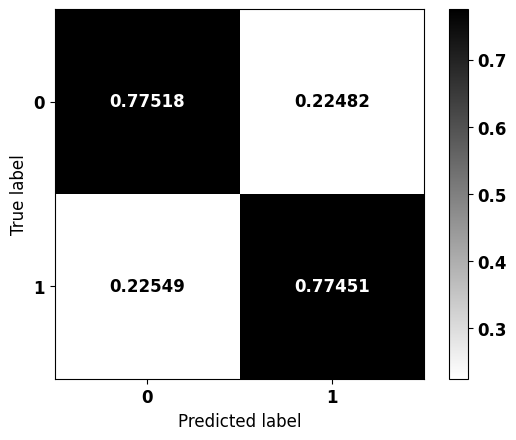


              precision    recall  f1-score   support

           0    0.87012   0.77518   0.81991      8807
           1    0.63869   0.77451   0.70007      4519

    accuracy                        0.77495     13326
   macro avg    0.75441   0.77484   0.75999     13326
weighted avg    0.79164   0.77495   0.77927     13326



In [ ]:
# Configure the final LightGBM model using the best-found hyperparameters
params = studyLGBM.best_params  # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed  # Fix the random seed for reproducibility
params['class_weight'] = {0:1, 1:1.721}  # Apply the chosen class imbalance weight

# Instantiate and configure the LightGBM classifier
lgbm_cma = LGBMClassifier(verbose=-1)
lgbm_cma.set_params(**params)

# Train the optimized model on the training dataset
lgbm_cma.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(lgbm_cma, X_test, y_test)

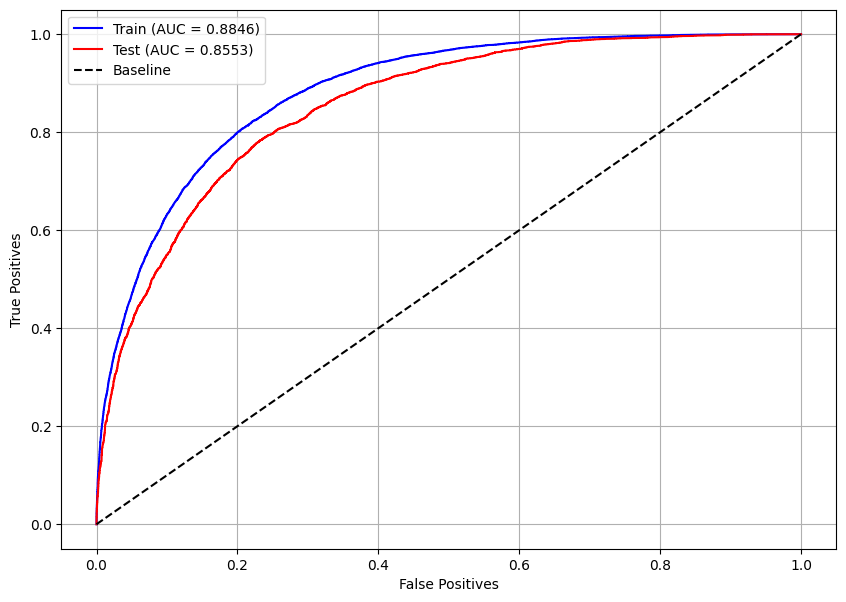

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm_cma, X_train, X_test, y_train, y_test)

**Optimized model**

In [ ]:
# Compare multiple LightGBM models and select the one with the highest test accuracy
models = [lgbm_rand, lgbm_tpe, lgbm_cma]  # List of trained models to evaluate
for i, m in enumerate(models):
    if i == 0:
        best = m  # Initialize the first model as the current best
    else:
        best_score = best.score(X_test, y_test)  # Accuracy of the current best model
        score = m.score(X_test, y_test)  # Accuracy of the model being evaluated
        if score > best_score:
            best = m  # Update 'best' if this model performs better

print(best)  # Output the model with the highest accuracy on the test set

LGBMClassifier(class_weight={0: 1, 1: 1.721}, colsample_bytree=0.7,
               learning_rate=0.08, max_depth=8, min_child_weight=4,
               n_estimators=140, random_state=7, verbose=-1)


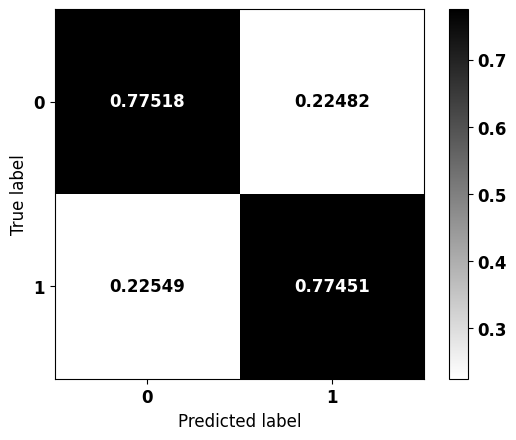


              precision    recall  f1-score   support

           0    0.87012   0.77518   0.81991      8807
           1    0.63869   0.77451   0.70007      4519

    accuracy                        0.77495     13326
   macro avg    0.75441   0.77484   0.75999     13326
weighted avg    0.79164   0.77495   0.77927     13326



In [ ]:
# Retrieve the hyperparameters from the selected best model
params = best.get_params()

# Initialize a new LightGBM classifier with those best hyperparameters
lgbm_optuna = LGBMClassifier(verbose=-1)
lgbm_optuna.set_params(**params)

# Train the optimized model on the training data
lgbm_optuna.fit(X_train, y_train)

# Plot the confusion matrix to evaluate the optimized model on the test data
plot_confusion_matrix(lgbm_optuna, X_test, y_test)

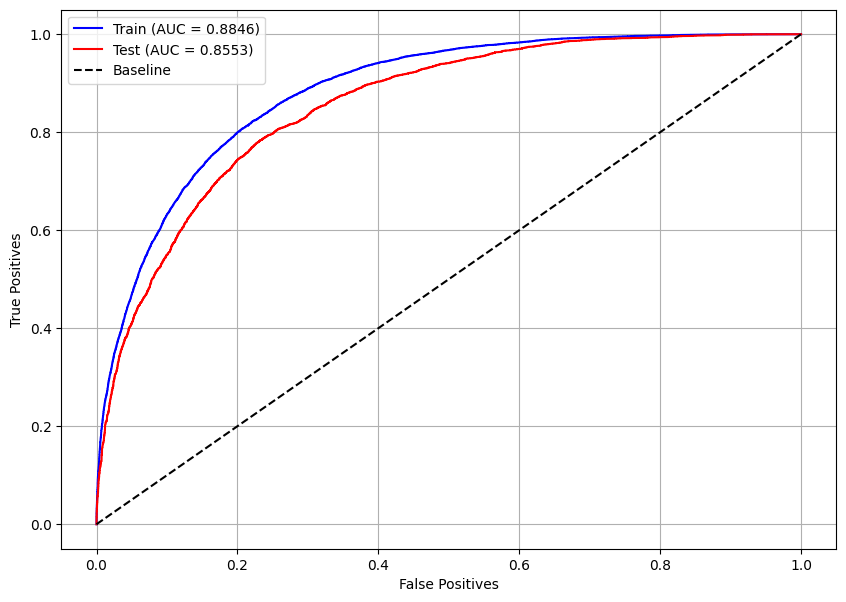

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm_optuna, X_train, X_test, y_train, y_test)

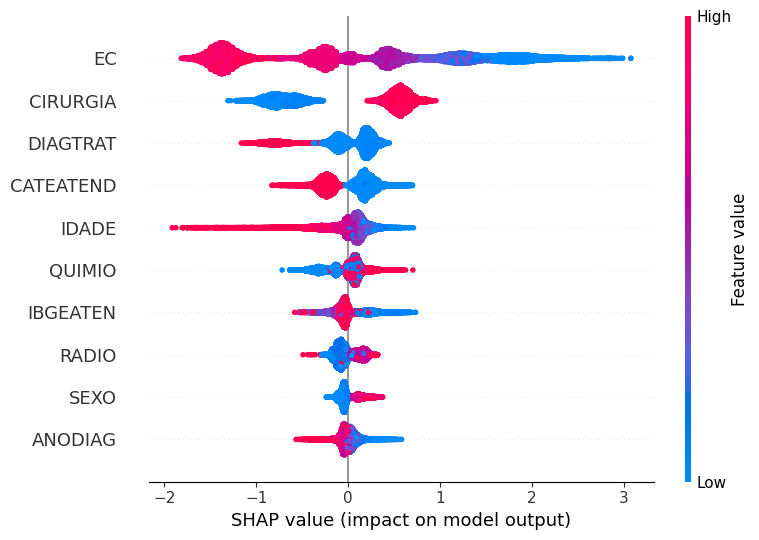

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(lgbm_optuna, X_train, feat_cols)

## **Cross Predictions**

In [ ]:
# Best Model Selection
models = [xgb, xgb_optuna, lgbm, lgbm_optuna]  # List of models to compare (XGBoost, optimized XGBoost, LightGBM, optimized LightGBM)

# Iterating through each model to find the best performing one
for i, m in enumerate(models):
    if i == 0:  # Initialize the best model as the first one
        best = m
    else:
        # Compare the performance of the current best model and the current model
        best_score = best.score(X_test, y_test)  # Get the accuracy of the current best model on the test set
        score = m.score(X_test, y_test)  # Get the accuracy of the current model on the test set
        if score > best_score:  # If the current model performs better, update the best model
            best = m

# Print the best performing model
print(best)

LGBMClassifier(class_weight={0: 1, 1: 1.721}, colsample_bytree=0.7,
               learning_rate=0.08, max_depth=8, min_child_weight=4,
               n_estimators=140, random_state=7, verbose=-1)


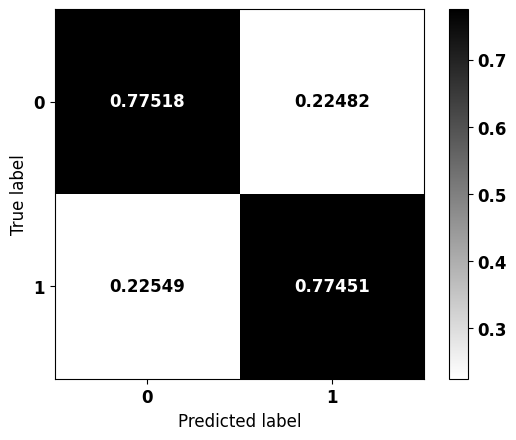


              precision    recall  f1-score   support

           0    0.87012   0.77518   0.81991      8807
           1    0.63869   0.77451   0.70007      4519

    accuracy                        0.77495     13326
   macro avg    0.75441   0.77484   0.75999     13326
weighted avg    0.79164   0.77495   0.77927     13326



In [ ]:
# Confusion Matrix for the Best Model
plot_confusion_matrix(best, X_test, y_test)  # Plot the normalized confusion matrix for the best model

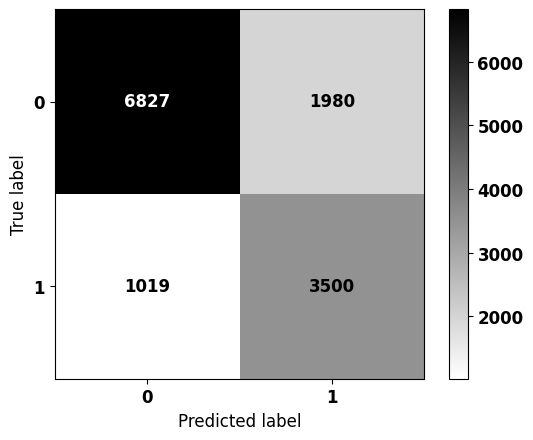


              precision    recall  f1-score   support

           0    0.87012   0.77518   0.81991      8807
           1    0.63869   0.77451   0.70007      4519

    accuracy                        0.77495     13326
   macro avg    0.75441   0.77484   0.75999     13326
weighted avg    0.79164   0.77495   0.77927     13326



In [ ]:
plot_confusion_matrix(best, X_test, y_test, norm=False)  # Plot the unnormalized confusion matrix for the best model

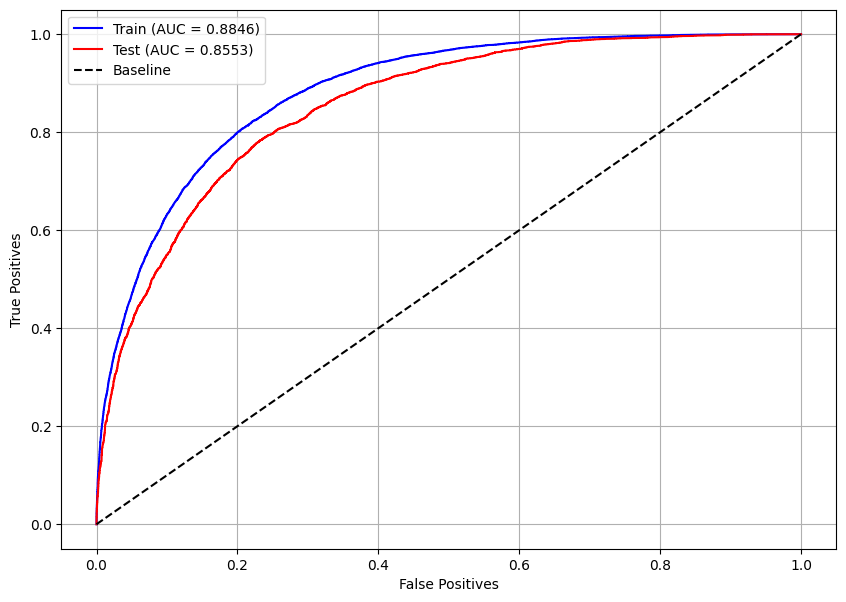

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(best, X_train, X_test, y_train, y_test)

/usr/local/lib/python3.10/dist-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


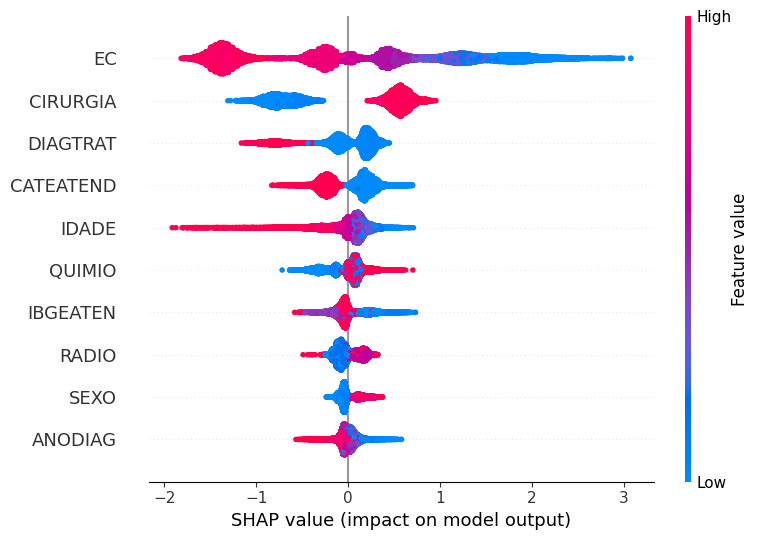

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(best, X_train, feat_cols)

In [ ]:
# Prepare test features and target for Oral Cavity Cancer
X_test_boca = boca_teste.drop(columns=list_drop).copy()  # Features for the Oral Cavity cancer test set
y_test_boca = boca_teste.sobrevida_3anos.copy()          # Target variable (3-year survival) for the Oral Cavity cancer test set

# Encode the 'TOPOGRUP' categorical column using the fitted OrdinalEncoder
X_test_boca['TOPOGRUP'] = oe.transform(X_test_boca[['TOPOGRUP']])

# Scale the encoded 'TOPOGRUP' values using the fitted StandardScaler
X_test_boca['TOPOGRUP'] = ss.transform(X_test_boca[['TOPOGRUP']])

# Prepare test features and target for Stomach Cancer
X_test_esto = esto_teste.drop(columns=list_drop).copy()  # Features for the Stomach cancer test set
y_test_esto = esto_teste.sobrevida_3anos.copy()          # Target variable (3-year survival) for the Stomach cancer test set

# Encode the 'TOPOGRUP' categorical column using the fitted OrdinalEncoder
X_test_esto['TOPOGRUP'] = oe.transform(X_test_esto[['TOPOGRUP']])

# Scale the encoded 'TOPOGRUP' values using the fitted StandardScaler
X_test_esto['TOPOGRUP'] = ss.transform(X_test_esto[['TOPOGRUP']])

# Prepare test features and target for Small Intestine Cancer
X_test_delg = delg_teste.drop(columns=list_drop).copy()  # Features for the Small Intestine cancer test set
y_test_delg = delg_teste.sobrevida_3anos.copy()          # Target variable (3-year survival) for the Small Intestine cancer test set

# Encode the 'TOPOGRUP' categorical column using the fitted OrdinalEncoder
X_test_delg['TOPOGRUP'] = oe.transform(X_test_delg[['TOPOGRUP']])

# Scale the encoded 'TOPOGRUP' values using the fitted StandardScaler
X_test_delg['TOPOGRUP'] = ss.transform(X_test_delg[['TOPOGRUP']])

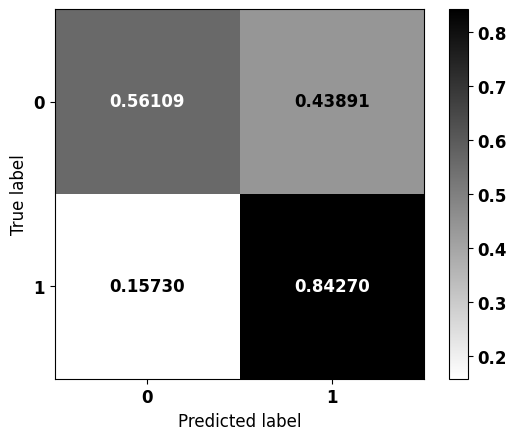


              precision    recall  f1-score   support

           0    0.81579   0.56109   0.66488       221
           1    0.60729   0.84270   0.70588       178

    accuracy                        0.68672       399
   macro avg    0.71154   0.70189   0.68538       399
weighted avg    0.72277   0.68672   0.68317       399



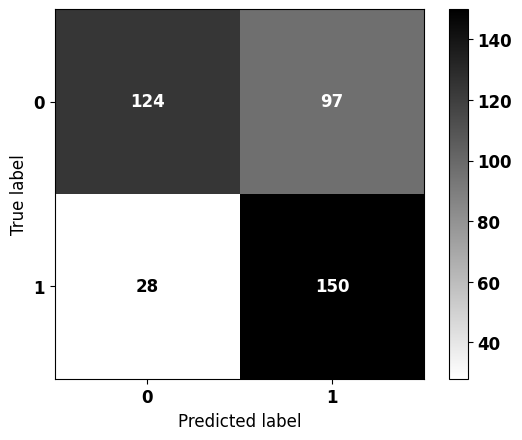


              precision    recall  f1-score   support

           0    0.81579   0.56109   0.66488       221
           1    0.60729   0.84270   0.70588       178

    accuracy                        0.68672       399
   macro avg    0.71154   0.70189   0.68538       399
weighted avg    0.72277   0.68672   0.68317       399



In [ ]:
# Plot the normalized confusion matrix for the best model on the Small Intestine cancer test data
plot_confusion_matrix(best, X_test_delg, y_test_delg)

# Plot the raw (unnormalized) confusion matrix for the best model on the Small Intestine cancer test data
plot_confusion_matrix(best, X_test_delg, y_test_delg, norm=False)

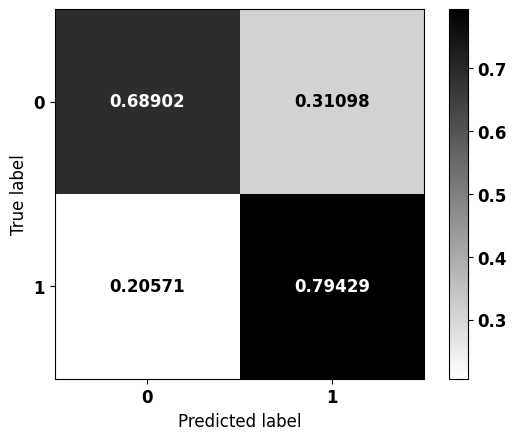


              precision    recall  f1-score   support

           0    0.82851   0.68902   0.75236      3534
           1    0.63908   0.79429   0.70828      2450

    accuracy                        0.73212      5984
   macro avg    0.73380   0.74165   0.73032      5984
weighted avg    0.75095   0.73212   0.73431      5984



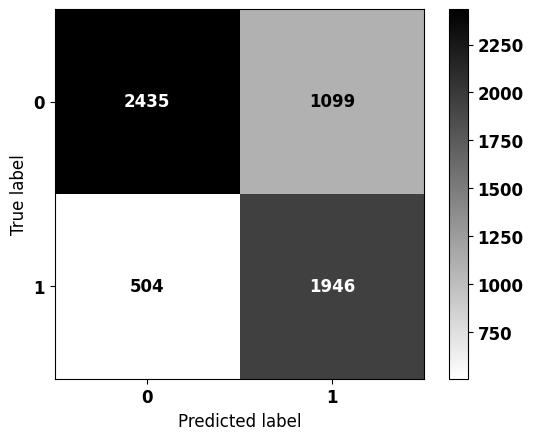


              precision    recall  f1-score   support

           0    0.82851   0.68902   0.75236      3534
           1    0.63908   0.79429   0.70828      2450

    accuracy                        0.73212      5984
   macro avg    0.73380   0.74165   0.73032      5984
weighted avg    0.75095   0.73212   0.73431      5984



In [ ]:
# Plot the normalized confusion matrix for the best model on the Oral Cavity cancer test data
plot_confusion_matrix(best, X_test_boca, y_test_boca)

# Plot the raw (unnormalized) confusion matrix for the best model on the Oral Cavity cancer test data
plot_confusion_matrix(best, X_test_boca, y_test_boca, norm=False)

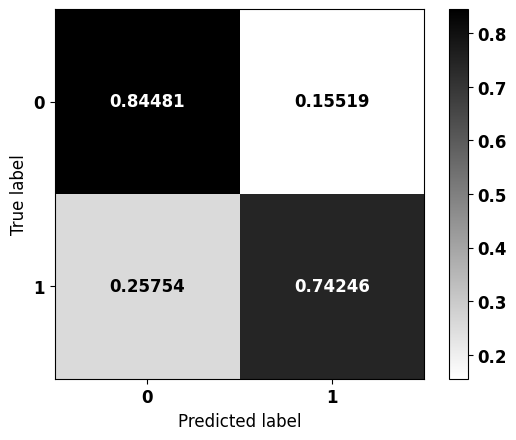


              precision    recall  f1-score   support

           0    0.89758   0.84481   0.87040      5052
           1    0.64168   0.74246   0.68840      1891

    accuracy                        0.81694      6943
   macro avg    0.76963   0.79364   0.77940      6943
weighted avg    0.82788   0.81694   0.82083      6943



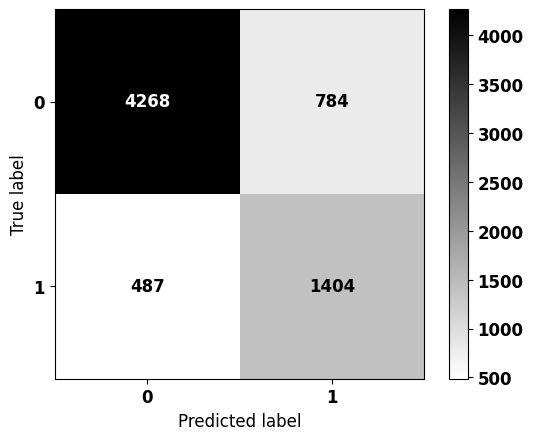


              precision    recall  f1-score   support

           0    0.89758   0.84481   0.87040      5052
           1    0.64168   0.74246   0.68840      1891

    accuracy                        0.81694      6943
   macro avg    0.76963   0.79364   0.77940      6943
weighted avg    0.82788   0.81694   0.82083      6943



In [ ]:
# Plot the normalized confusion matrix for the best model on the Stomach cancer test data
plot_confusion_matrix(best, X_test_esto, y_test_esto)

# Plot the raw (unnormalized) confusion matrix for the best model on the Stomach cancer test data
plot_confusion_matrix(best, X_test_esto, y_test_esto, norm=False)

## **Voting Classifier**


In [ ]:
# Comparing the accuracy scores of the initial XGBoost model and the optimized Optuna model
xgb_score = xgb.score(X_test, y_test)
optuna_score = xgb_optuna.score(X_test, y_test)
print(f'Accuracy: XGB = {xgb_score:.4f}, Optuna = {optuna_score:.4f}\n')

# Determine which model performed better
if optuna_score >= xgb_score:
    params_xgb = xgb_optuna.get_params()  # Get the parameters of the optimized model
    print('Optimized model won')
else:
    params_xgb = xgb.get_params()  # Get the parameters of the initial model
    print('Initial model won')

Accuracy: XGB = 0.7699, Optuna = 0.7725

Otimizado venceu


In [ ]:
# Comparing the accuracy scores of the initial LightGBM model and the optimized Optuna model
lgbm_score = lgbm.score(X_test, y_test)
optuna_score = lgbm_optuna.score(X_test, y_test)
print(f'Accuracy: LGBM = {lgbm_score:.4f}, Optuna = {optuna_score:.4f}\n')

# Determine which model performed better
if optuna_score >= lgbm_score:
    params_lgbm = lgbm_optuna.get_params()  # Get the parameters of the optimized model
    print('Optimized model won')
else:
    params_lgbm = lgbm.get_params()  # Get the parameters of the initial model
    print('Initial model won')

Accuracy: LGBM = 0.7716, Optuna = 0.7750

Otimizado venceu


In [ ]:
# Creating the models with the best-performing hyperparameters
# XGBoost Model
best_xgb = XGBClassifier()  # Instantiate the XGBoost classifier
best_xgb.set_params(**params_xgb)  # Set the best hyperparameters for XGBoost

# LightGBM Model
best_lgbm = LGBMClassifier()  # Instantiate the LightGBM classifier
best_lgbm.set_params(**params_lgbm)  # Set the best hyperparameters for LightGBM

LGBMClassifier(class_weight={0: 1, 1: 1.721}, colsample_bytree=0.7,
               learning_rate=0.08, max_depth=8, min_child_weight=4,
               n_estimators=140, random_state=7, verbose=-1)

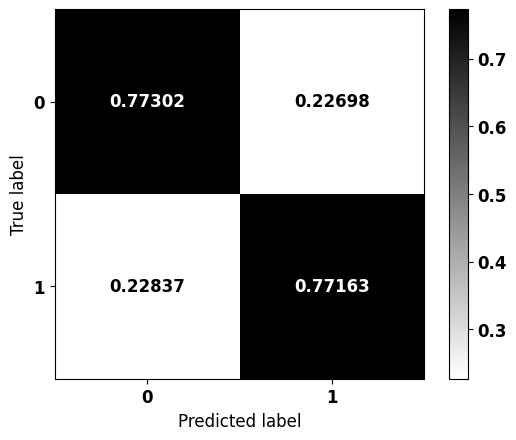


              precision    recall  f1-score   support

           0    0.86837   0.77302   0.81793      8807
           1    0.63562   0.77163   0.69705      4519

    accuracy                        0.77255     13326
   macro avg    0.75199   0.77233   0.75749     13326
weighted avg    0.78944   0.77255   0.77694     13326



In [ ]:
from sklearn.ensemble import VotingClassifier

# Creating and training the voting classifier model
clf = VotingClassifier(
    estimators=[('XGBoost', best_xgb),  # Adding the best XGBoost model
               ('LightGBM', best_lgbm)],  # Adding the best LightGBM model
    voting='soft'  # Using 'soft' voting, which predicts the class label based on predicted probabilities
)

clf.fit(X_train, y_train)  # Train the voting classifier on the training data

# Confusion Matrix
plot_confusion_matrix(clf, X_test, y_test)  # Plot the confusion matrix for the voting classifier on the test data

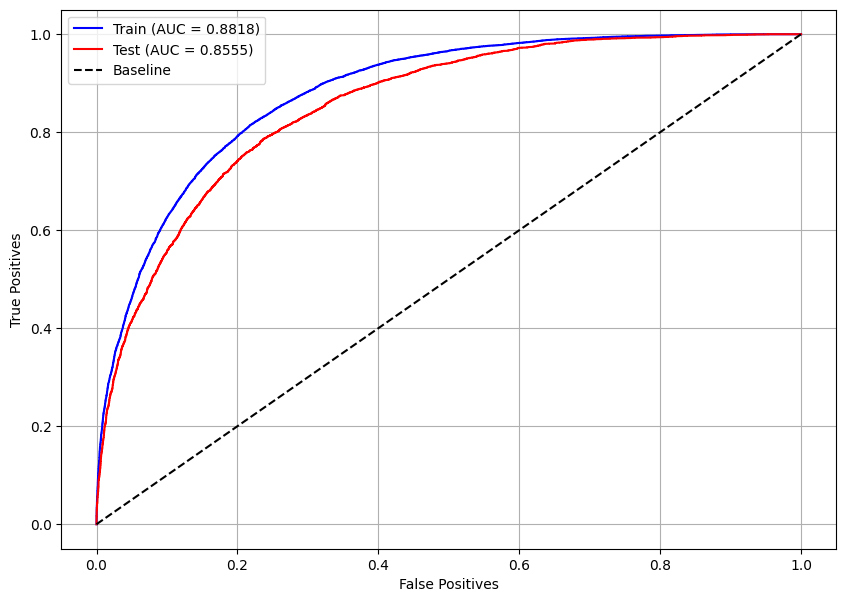

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(clf, X_train, X_test, y_train, y_test)

# **Stomach with Colorectal**

In [ ]:
# Topographies for group 3
df3_treino.TOPOGRUP.value_counts()

TOPOGRUP
Colorretal    42083
Estômago      20827
Name: count, dtype: int64

In [ ]:
# Missing values
df3_treino.isna().sum().sort_values(ascending=False)

IDADE                 0
CONSDIAG              0
TOPOGRUP              0
presenca_rec          0
IBGE_idem_IBGEATEN    0
ESCOLARI_preench      0
HABILIT2              0
IBGEATEN              0
RRAS                  0
DRS                   0
ANODIAG               0
DIAGTRAT              0
OUTROS                0
SEXO                  0
IMUNO                 0
TMO                   0
HORMONIO              0
QUIMIO                0
RADIO                 0
CIRURGIA              0
EC                    0
DIAGPREV              0
CATEATEND             0
IBGE                  0
sobrevida_3anos       0
dtype: int64

In [ ]:
# Count the number of patients in each class of the target variable 'sobrevida_ano3'
df3_treino.sobrevida_3anos.value_counts()

sobrevida_3anos
0    33974
1    28936
Name: count, dtype: int64

## **Preprocessing**

In [ ]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Initialize an OrdinalEncoder to convert categorical 'TOPOGRUP' values to integer codes,
# and assign -1 to any categories not seen during fitting
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit the encoder on the training set and transform its 'TOPOGRUP' column
df3_treino['TOPOGRUP'] = oe.fit_transform(df3_treino[['TOPOGRUP']])

# Transform the test set's 'TOPOGRUP' column using the already-fitted encoder
df3_teste['TOPOGRUP'] = oe.transform(df3_teste[['TOPOGRUP']])

# Initialize a StandardScaler to standardize the feature (zero mean, unit variance)
ss = StandardScaler()

# Fit the scaler on the training set's encoded 'TOPOGRUP' values and apply the transformation
df3_treino['TOPOGRUP'] = ss.fit_transform(df3_treino[['TOPOGRUP']])

# Apply the same scaling transformation to the test set's encoded 'TOPOGRUP' values
df3_teste['TOPOGRUP'] = ss.transform(df3_teste[['TOPOGRUP']])

In [ ]:
# Define the column to drop (the target variable)
list_drop = ['sobrevida_3anos']

# Prepare training features and target
X_train = df3_treino.drop(columns=list_drop).copy()  # Features for the training set
y_train = df3_treino.sobrevida_3anos.copy()          # Target variable for the training set

# Prepare test features and target
X_test = df3_teste.drop(columns=list_drop).copy()    # Features for the test set
y_test = df3_teste.sobrevida_3anos.copy()            # Target variable for the test set

# Display the shapes of the training and test splits
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((62910, 24), (62910,), (20971, 24), (20971,))

In [ ]:
# Feature columns
feat_cols = X_train.columns
feat_cols

Index(['IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV', 'EC', 'CIRURGIA',
       'RADIO', 'QUIMIO', 'HORMONIO', 'TMO', 'IMUNO', 'OUTROS', 'CONSDIAG',
       'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'IBGEATEN', 'HABILIT2',
       'ESCOLARI_preench', 'IBGE_idem_IBGEATEN', 'presenca_rec', 'TOPOGRUP'],
      dtype='object')

## **Machine learning models**

### **XGBoost**


#### **Base model**

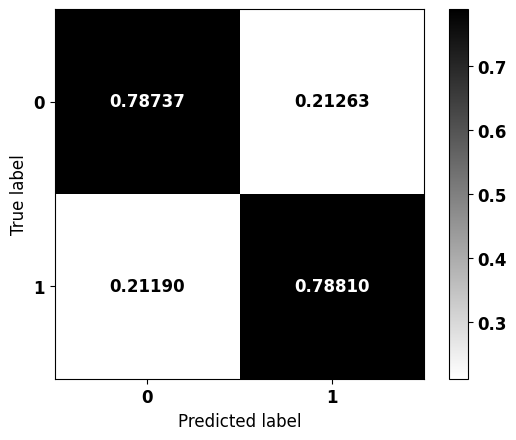


              precision    recall  f1-score   support

           0    0.81352   0.78737   0.80023     11325
           1    0.75944   0.78810   0.77350      9646

    accuracy                        0.78771     20971
   macro avg    0.78648   0.78774   0.78687     20971
weighted avg    0.78865   0.78771   0.78794     20971



In [ ]:
# Create and train the XGBoost classifier
xgb = XGBClassifier(max_depth=5,            # Set maximum tree depth to 5
                    scale_pos_weight=0.96,  # Balance positive and negative classes
                    random_state=seed)      # Ensure reproducibility with a fixed random seed

xgb.fit(X_train, y_train)  # Train the model on the training data

# Plot the confusion matrix to evaluate model performance on the test set
plot_confusion_matrix(xgb, X_test, y_test)

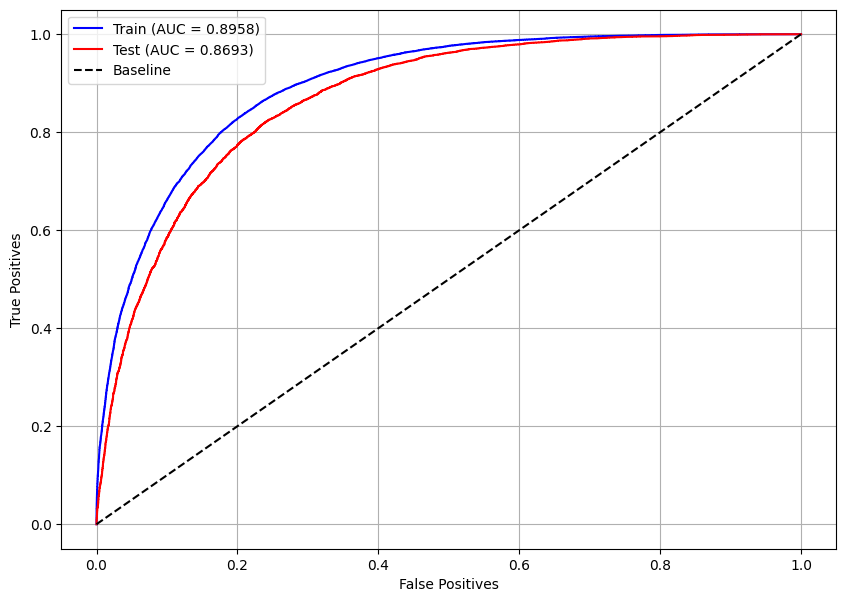

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb, X_train, X_test, y_train, y_test)

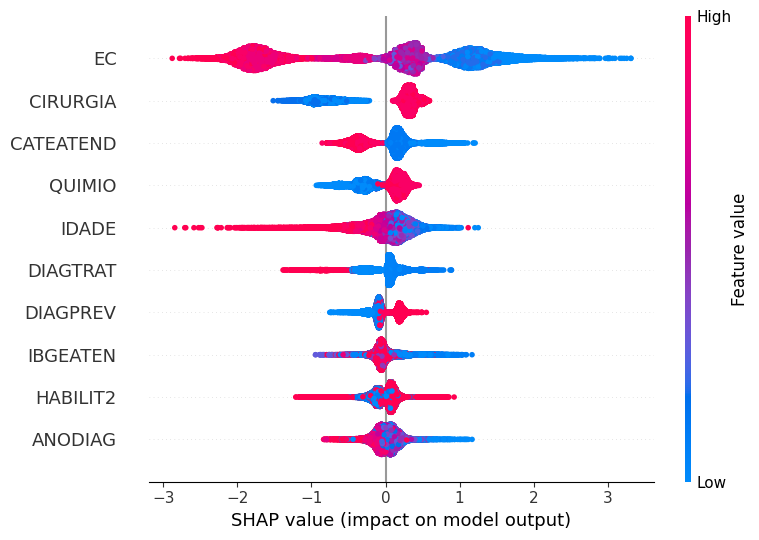

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(xgb, X_train, feat_cols)

#### **Optuna**

In [ ]:
# Create stratified folds to maintain class proportions during cross-validation
skf = StratifiedKFold(10, shuffle=True, random_state=seed)

# Define the objective function for hyperparameter optimization
def objective(trial):
    """
    Objective function for Optuna to optimize an XGBoost classifier.
    Returns the mean accuracy across stratified folds.
    """

    # Suggest values for hyperparameters to be optimized
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Number of boosting rounds
    max_depth = trial.suggest_int('max_depth', 3, 6)  # Maximum tree depth
    learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2, step=0.05)  # Learning rate for updates
    gamma = trial.suggest_float('gamma', 0.0, 0.3, step=0.1)  # Minimum loss reduction for tree splits
    min_child_weight = trial.suggest_int('min_child_weight', 1, 7)  # Minimum sum of instance weight in child nodes
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 0.7, step=0.1)  # Subsample ratio of features per tree

    # Initialize the XGBoost classifier with the suggested hyperparameters
    cls = XGBClassifier(n_estimators=n_estimators,
                        max_depth=max_depth,
                        learning_rate=learning_rate,
                        gamma=gamma,
                        min_child_weight=min_child_weight,
                        colsample_bytree=colsample_bytree,
                        random_state=seed,
                        n_jobs=-1)

    # Perform cross-validation and return the average accuracy
    return cross_val_score(cls, X_train, y_train,
                           cv=skf, scoring='accuracy').mean()

RandomSampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyXGB = optuna.create_study(direction='maximize', sampler=RandomSampler(seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyXGB.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyXGB.best_params

{'n_estimators': 98,
 'max_depth': 6,
 'learning_rate': 0.15000000000000002,
 'gamma': 0.1,
 'min_child_weight': 5,
 'colsample_bytree': 0.4}

In [ ]:
# Generate a range of candidate scale_pos_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(0.93, 0.96, 0.0001), 4)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyXGB.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['scale_pos_weight'] = i  # Update the class weight parameter

    # Initialize a new XGBoost classifier with the updated hyperparameters
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Train the model on the training set
    xgb_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = xgb_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(xgb_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

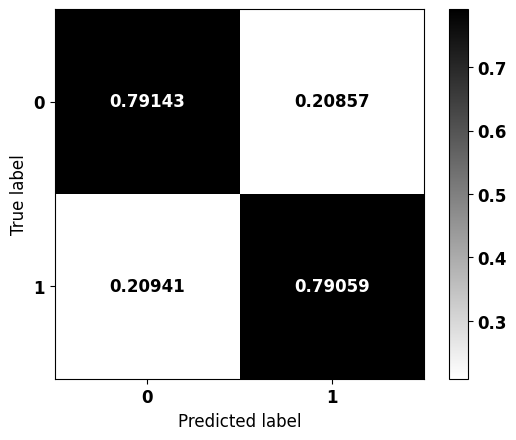


              precision    recall  f1-score   support

           0    0.81608   0.79143   0.80357     11325
           1    0.76352   0.79059   0.77682      9646

    accuracy                        0.79104     20971
   macro avg    0.78980   0.79101   0.79019     20971
weighted avg    0.79190   0.79104   0.79126     20971



In [ ]:
# Configure the final XGBoost model using the best-found hyperparameters
params = studyXGB.best_params           # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed           # Fix the random seed for reproducibility
params['scale_pos_weight'] = 0.9303     # Apply the chosen class imbalance weight

# Instantiate and configure the XGBoost classifier
xgb_rand = XGBClassifier()
xgb_rand.set_params(**params)

# Train the optimized model on the training dataset
xgb_rand.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(xgb_rand, X_test, y_test)

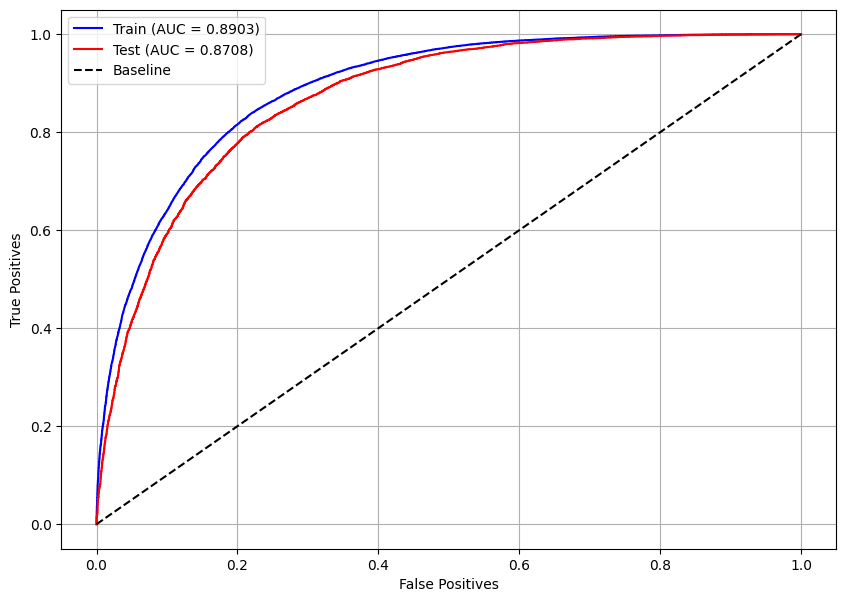

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb_rand, X_train, X_test, y_train, y_test)

TPESampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyXGB = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyXGB.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyXGB.best_params

{'n_estimators': 143,
 'max_depth': 6,
 'learning_rate': 0.15000000000000002,
 'gamma': 0.0,
 'min_child_weight': 2,
 'colsample_bytree': 0.3}

In [ ]:
# Generate a range of candidate scale_pos_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(0.93, 0.96, 0.0001), 4)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyXGB.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['scale_pos_weight'] = i  # Update the class weight parameter

    # Initialize a new XGBoost classifier with the updated hyperparameters
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Train the model on the training set
    xgb_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = xgb_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(xgb_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

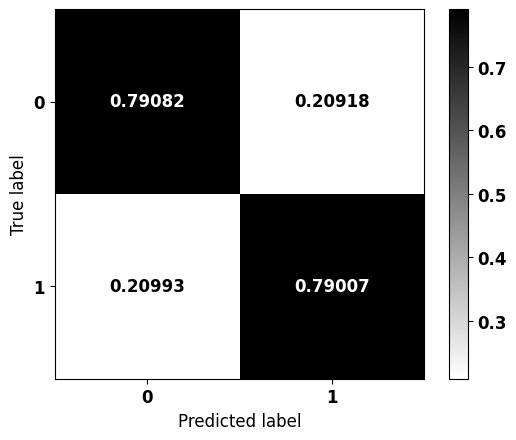


              precision    recall  f1-score   support

           0    0.81559   0.79082   0.80301     11325
           1    0.76286   0.79007   0.77623      9646

    accuracy                        0.79047     20971
   macro avg    0.78923   0.79044   0.78962     20971
weighted avg    0.79134   0.79047   0.79069     20971



In [ ]:
# Configure the final XGBoost model using the best-found hyperparameters
params = studyXGB.best_params           # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed           # Fix the random seed for reproducibility
params['scale_pos_weight'] = 0.9462     # Apply the chosen class imbalance weight

# Instantiate and configure the XGBoost classifier
xgb_tpe = XGBClassifier()
xgb_tpe.set_params(**params)

# Train the optimized model on the training dataset
xgb_tpe.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(xgb_tpe, X_test, y_test)

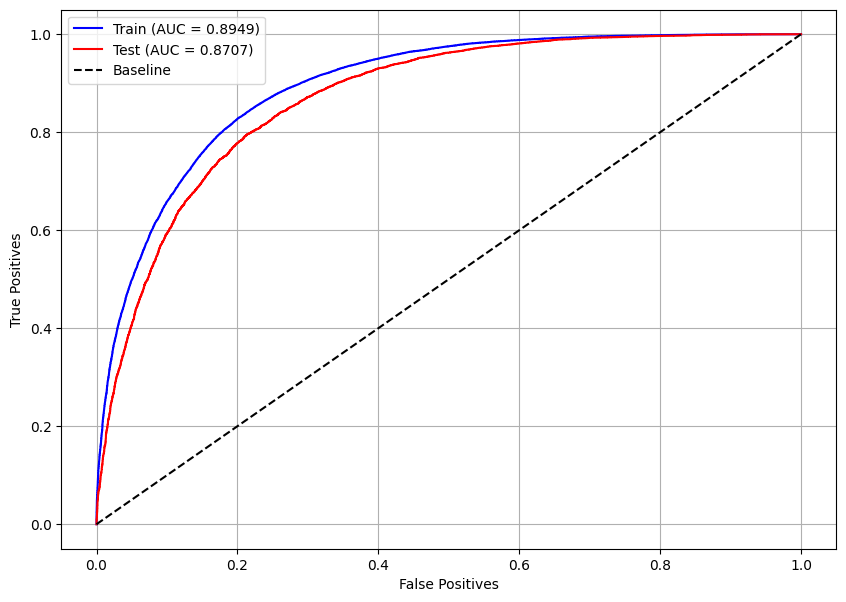

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb_tpe, X_train, X_test, y_train, y_test)

CmaEsSampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyXGB = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyXGB.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyXGB.best_params

{'n_estimators': 140,
 'max_depth': 6,
 'learning_rate': 0.1,
 'gamma': 0.2,
 'min_child_weight': 5,
 'colsample_bytree': 0.5}

In [ ]:
# Generate a range of candidate scale_pos_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(0.93, 0.96, 0.0001), 4)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyXGB.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['scale_pos_weight'] = i  # Update the class weight parameter

    # Initialize a new XGBoost classifier with the updated hyperparameters
    xgb_optuna = XGBClassifier()
    xgb_optuna.set_params(**params)

    # Train the model on the training set
    xgb_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = xgb_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(xgb_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

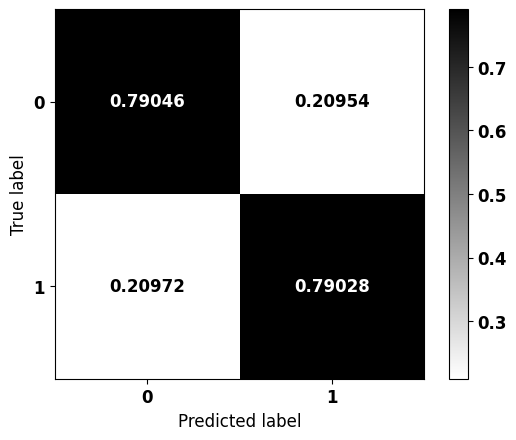


              precision    recall  f1-score   support

           0    0.81567   0.79046   0.80287     11325
           1    0.76261   0.79028   0.77619      9646

    accuracy                        0.79038     20971
   macro avg    0.78914   0.79037   0.78953     20971
weighted avg    0.79126   0.79038   0.79060     20971



In [ ]:
# Configure the final XGBoost model using the best-found hyperparameters
params = studyXGB.best_params           # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed           # Fix the random seed for reproducibility
params['scale_pos_weight'] = 0.9422     # Apply the chosen class imbalance weight

# Instantiate and configure the XGBoost classifier
xgb_cma = XGBClassifier()
xgb_cma.set_params(**params)

# Train the optimized model on the training dataset
xgb_cma.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(xgb_cma, X_test, y_test)

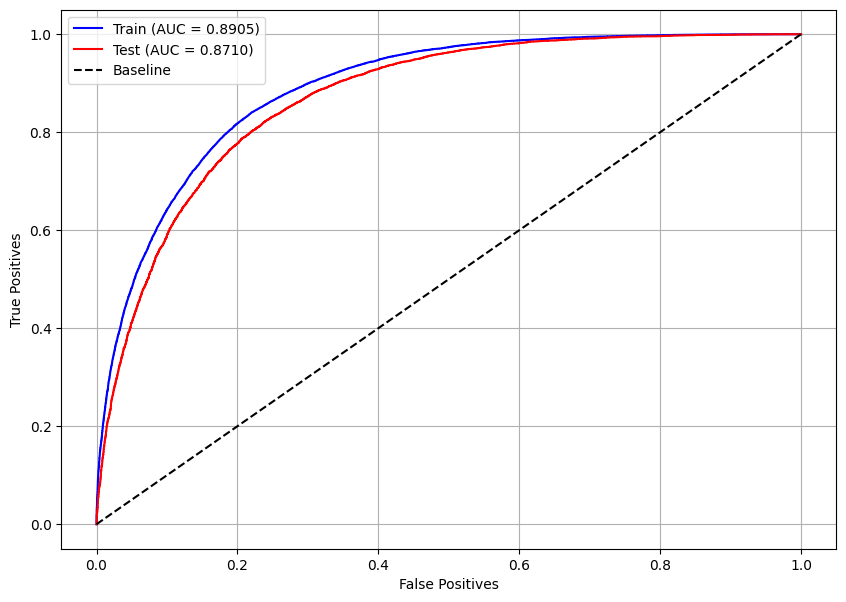

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb_cma, X_train, X_test, y_train, y_test)

**Optimized model**

In [ ]:
# Compare multiple XGBoost models and select the one with the highest test accuracy
models = [xgb_rand, xgb_tpe, xgb_cma]  # List of trained models to evaluate

for i, m in enumerate(models):
    if i == 0:
        best = m  # Initialize the first model as the current best
    else:
        best_score = best.score(X_test, y_test)  # Accuracy of the current best model
        score = m.score(X_test, y_test)          # Accuracy of the model being evaluated
        if score > best_score:
            best = m  # Update 'best' if this model performs better

print(best)  # Output the model with the highest accuracy on the test set

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.4, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.15, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=98, n_jobs=None,
              num_parallel_tree=None, random_state=7, ...)


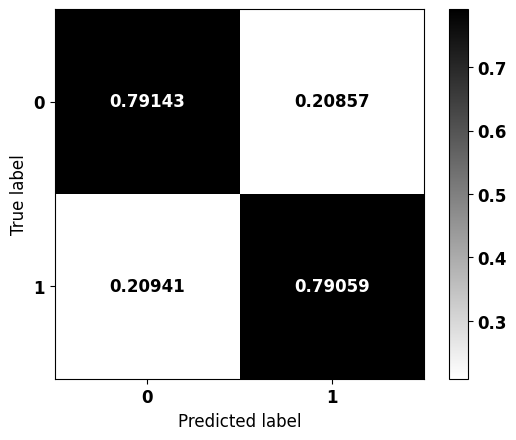


              precision    recall  f1-score   support

           0    0.81608   0.79143   0.80357     11325
           1    0.76352   0.79059   0.77682      9646

    accuracy                        0.79104     20971
   macro avg    0.78980   0.79101   0.79019     20971
weighted avg    0.79190   0.79104   0.79126     20971



In [ ]:
# Retrieve the hyperparameters from the selected best model
params = best.get_params()

# Initialize a new XGBoost classifier with those best hyperparameters
xgb_optuna = XGBClassifier()
xgb_optuna.set_params(**params)

# Train the optimized model on the training data
xgb_optuna.fit(X_train, y_train)

# Plot the confusion matrix to evaluate the optimized model on the test data
plot_confusion_matrix(xgb_optuna, X_test, y_test)

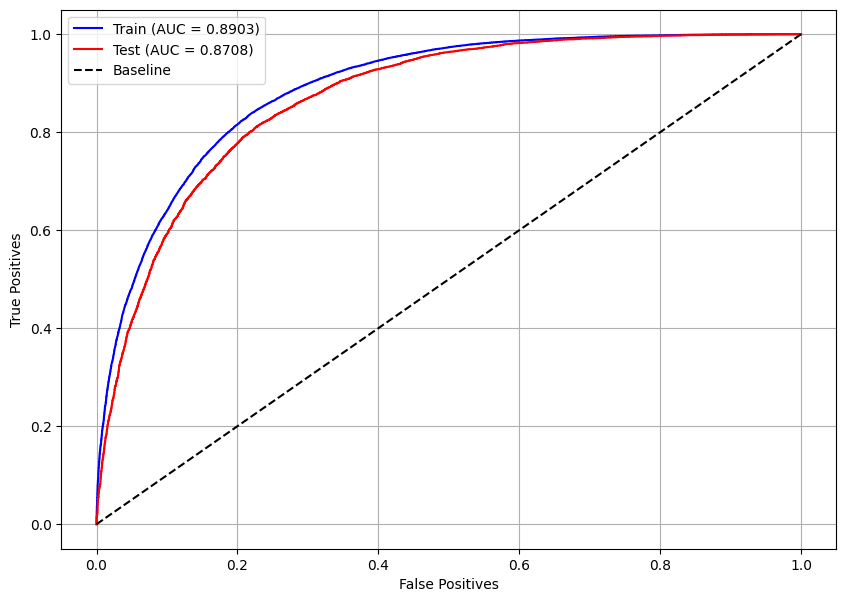

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(xgb_optuna, X_train, X_test, y_train, y_test)

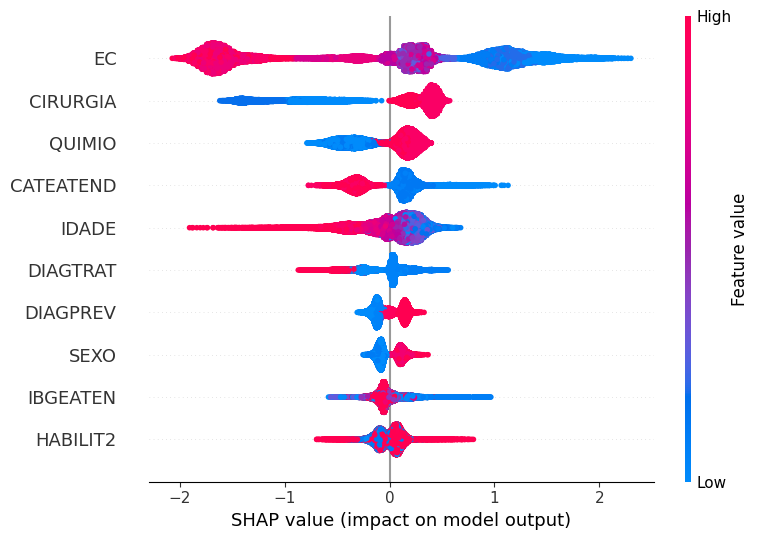

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(xgb_optuna, X_train, feat_cols)

### **LightGBM**


#### **Base model**

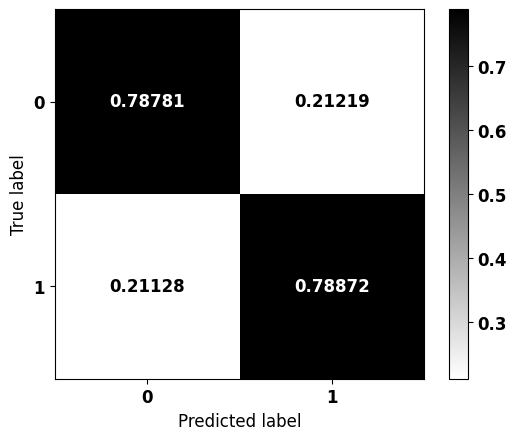


              precision    recall  f1-score   support

           0    0.81405   0.78781   0.80072     11325
           1    0.75996   0.78872   0.77408      9646

    accuracy                        0.78823     20971
   macro avg    0.78701   0.78827   0.78740     20971
weighted avg    0.78917   0.78823   0.78846     20971



In [ ]:
# Create and train the LightGBM classifier
lgbm = LGBMClassifier(max_depth=10,                 # Set maximum tree depth to 10
                      class_weight={0:1.07, 1:1},   # Balance positive and negative classes
                      random_state=seed,            # Ensure reproducibility with a fixed random seed
                      verbose=-1)

lgbm.fit(X_train, y_train)  # Train the model on the training data

# Plot the confusion matrix to evaluate model performance on the test set
plot_confusion_matrix(lgbm, X_test, y_test)

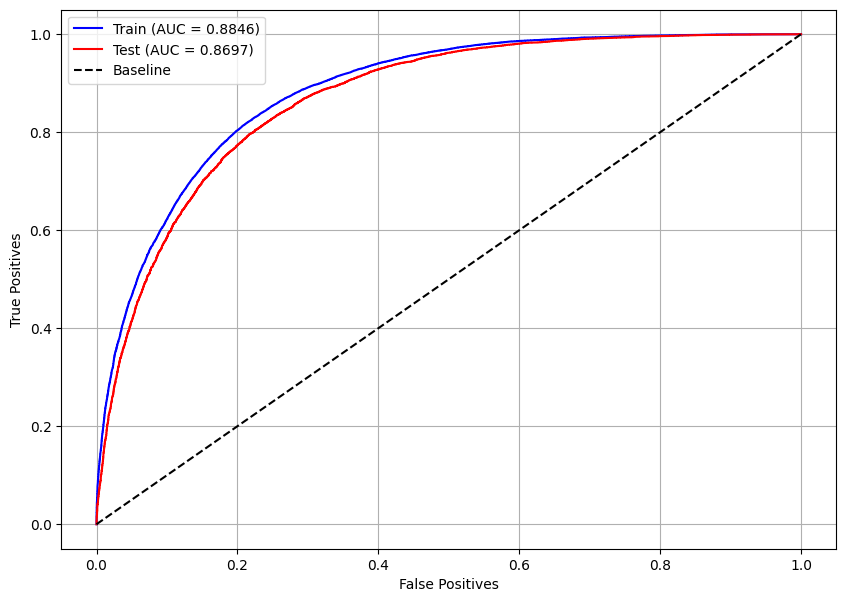

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm, X_train, X_test, y_train, y_test)

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


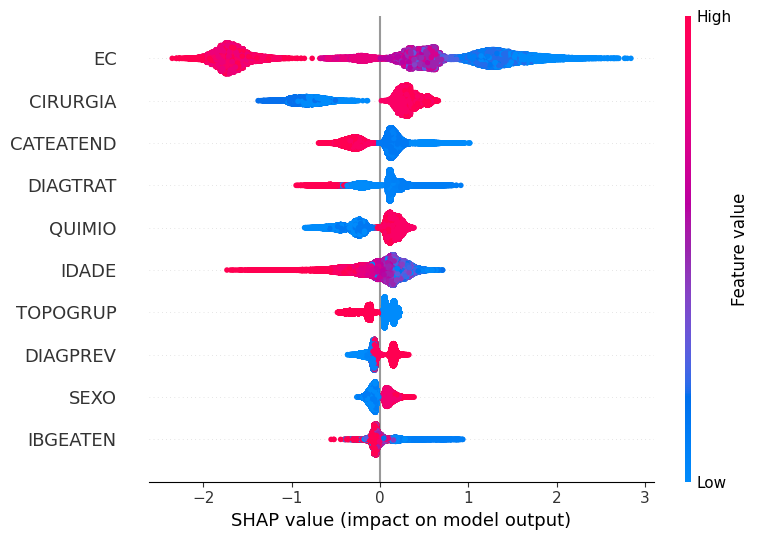

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(lgbm, X_train, feat_cols)

#### **Optuna**

In [ ]:
# Create stratified folds to maintain class proportions during cross-validation
skf = StratifiedKFold(10, shuffle=True, random_state=seed)

# Define the objective function for hyperparameter optimization
def objective(trial):
    """
    Objective function for Optuna to optimize an LightGBM classifier.
    Returns the mean accuracy across stratified folds.
    """

    # Suggest values for hyperparameters to be optimized
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Number of boosting rounds
    max_depth = trial.suggest_int('max_depth', 3, 10)  # Maximum tree depth
    learning_rate = trial.suggest_float('learning_rate', 0.05, 0.2, step=0.01)  # Learning rate for updates
    min_child_weight = trial.suggest_int('min_child_weight', 1, 7)  # Minimum sum of instance weight in child nodes
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 0.7, step=0.1)  # Subsample ratio of features per tree

    # Initialize the LightGBM classifier with the suggested hyperparameters
    cls = LGBMClassifier(n_estimators=n_estimators,
                         max_depth=max_depth,
                         learning_rate=learning_rate,
                         min_child_weight=min_child_weight,
                         colsample_bytree=colsample_bytree,
                         random_state=seed,
                         verbose=-1,
                         n_jobs=-1)

    # Perform cross-validation and return the average accuracy
    return cross_val_score(cls, X_train, y_train,
                           cv=skf, scoring='accuracy').mean()

RandomSampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyLGBM = optuna.create_study(direction='maximize', sampler=RandomSampler(seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyLGBM.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyLGBM.best_params

{'n_estimators': 81,
 'max_depth': 9,
 'learning_rate': 0.19,
 'min_child_weight': 2,
 'colsample_bytree': 0.4}

In [ ]:
# Generate a range of candidate class_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(1, 1.05, 0.0001), 4)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyLGBM.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['class_weight'] = {0:i, 1:1}  # Update the class weight parameter

    # Initialize a new LightGBM classifier with the updated hyperparameters
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Train the model on the training set
    lgbm_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = lgbm_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(lgbm_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

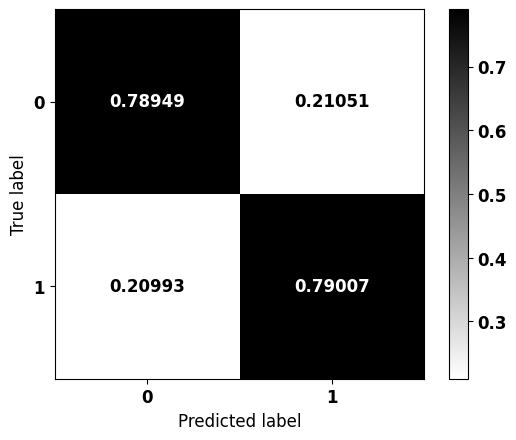


              precision    recall  f1-score   support

           0    0.81534   0.78949   0.80221     11325
           1    0.76172   0.79007   0.77563      9646

    accuracy                        0.78976     20971
   macro avg    0.78853   0.78978   0.78892     20971
weighted avg    0.79068   0.78976   0.78998     20971



In [ ]:
# Configure the final LightGBM model using the best-found hyperparameters
params = studyLGBM.best_params  # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed  # Fix the random seed for reproducibility
params['class_weight'] = {0:1.048, 1:1}  # Apply the chosen class imbalance weight

# Instantiate and configure the LightGBM classifier
lgbm_rand = LGBMClassifier(verbose=-1)
lgbm_rand.set_params(**params)

# Train the optimized model on the training dataset
lgbm_rand.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(lgbm_rand, X_test, y_test)

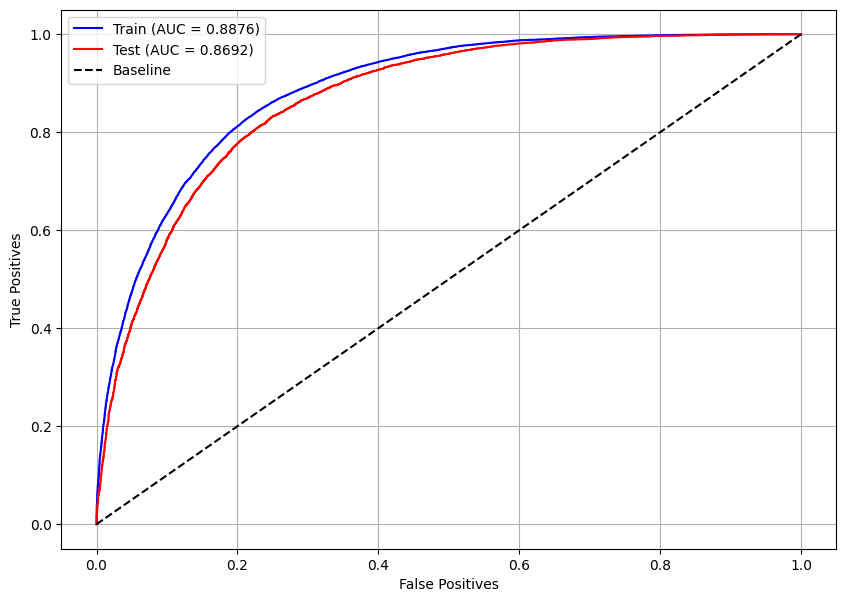

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm_rand, X_train, X_test, y_train, y_test)

TPESampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyLGBM = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyLGBM.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyLGBM.best_params

{'n_estimators': 138,
 'max_depth': 10,
 'learning_rate': 0.15000000000000002,
 'min_child_weight': 2,
 'colsample_bytree': 0.6000000000000001}

In [ ]:
# Generate a range of candidate class_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(1.02, 1.07, 0.0001), 4)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyLGBM.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['class_weight'] = {0:i, 1:1}  # Update the class weight parameter

    # Initialize a new LightGBM classifier with the updated hyperparameters
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Train the model on the training set
    lgbm_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = lgbm_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(lgbm_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

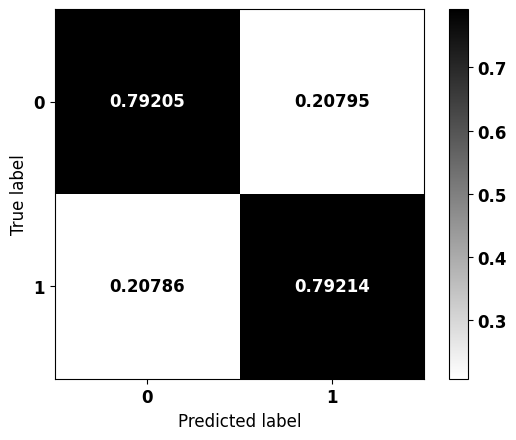


              precision    recall  f1-score   support

           0    0.81731   0.79205   0.80448     11325
           1    0.76441   0.79214   0.77803      9646

    accuracy                        0.79209     20971
   macro avg    0.79086   0.79210   0.79126     20971
weighted avg    0.79298   0.79209   0.79231     20971



In [ ]:
# Configure the final LightGBM model using the best-found hyperparameters
params = studyLGBM.best_params  # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed  # Fix the random seed for reproducibility
params['class_weight'] = {0:1.0528, 1:1}  # Apply the chosen class imbalance weight

# Instantiate and configure the LightGBM classifier
lgbm_tpe = LGBMClassifier(verbose=-1)
lgbm_tpe.set_params(**params)

# Train the optimized model on the training dataset
lgbm_tpe.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(lgbm_tpe, X_test, y_test)

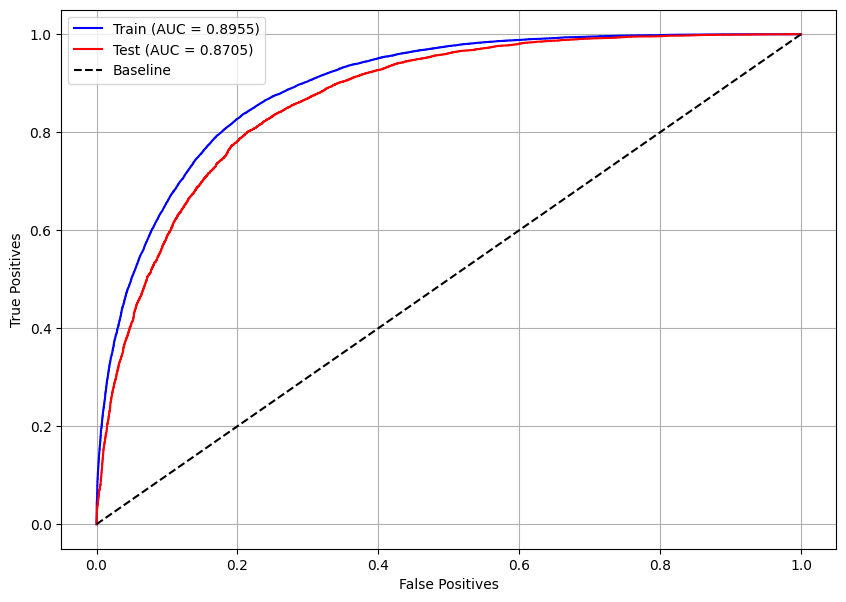

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm_tpe, X_train, X_test, y_train, y_test)

CmaEsSampler

In [ ]:
# Create an Optuna study configured to maximize the objective function
studyLGBM = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed))

# Execute the hyperparameter optimization over 100 trials, running trials in parallel
studyLGBM.optimize(objective, n_trials=100, n_jobs=-1)

In [ ]:
# Display the best hyperparameters
studyLGBM.best_params

{'n_estimators': 127,
 'max_depth': 7,
 'learning_rate': 0.16999999999999998,
 'min_child_weight': 4,
 'colsample_bytree': 0.5}

In [ ]:
# Generate a range of candidate class_weight values to fine-tune class imbalance handling
pesos = np.round(np.arange(1.02, 1.07, 0.0001), 4)

# Retrieve the best hyperparameters from the Optuna study and set a fixed random state
params = studyLGBM.best_params
params['random_state'] = seed

# Iterate over each candidate weight to find the optimal balance between classes
for i in pesos:
    params['class_weight'] = {0:i, 1:1}  # Update the class weight parameter

    # Initialize a new LightGBM classifier with the updated hyperparameters
    lgbm_optuna = LGBMClassifier(verbose=-1)
    lgbm_optuna.set_params(**params)

    # Train the model on the training set
    lgbm_optuna.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = lgbm_optuna.predict(X_test)

    # Compute the normalized confusion matrix and unpack true negatives (tn) and true positives (tp)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, normalize='true').ravel()

    # Check if the difference between true negative rate and true positive rate is within 0.1%
    if abs(tn - tp) <= 0.001:

        print(i)  # Print the weight value that achieved the balanced rates
        plot_confusion_matrix(lgbm_optuna, X_test, y_test)  # Display the confusion matrix for this model
        print()

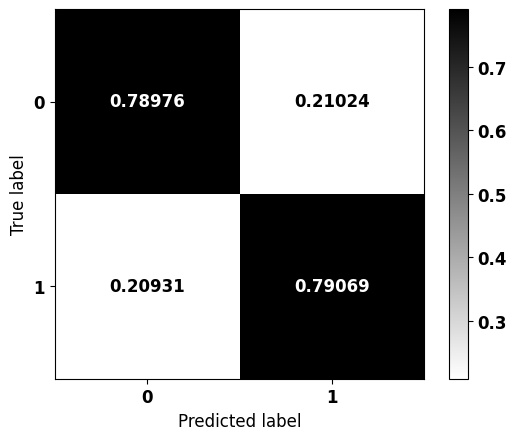


              precision    recall  f1-score   support

           0    0.81584   0.78976   0.80258     11325
           1    0.76209   0.79069   0.77613      9646

    accuracy                        0.79019     20971
   macro avg    0.78896   0.79022   0.78936     20971
weighted avg    0.79111   0.79019   0.79041     20971



In [ ]:
# Configure the final LightGBM model using the best-found hyperparameters
params = studyLGBM.best_params  # Retrieve the optimal hyperparameters from the Optuna study
params['random_state'] = seed  # Fix the random seed for reproducibility
params['class_weight'] = {0:1.0485, 1:1}  # Apply the chosen class imbalance weight

# Instantiate and configure the LightGBM classifier
lgbm_cma = LGBMClassifier(verbose=-1)
lgbm_cma.set_params(**params)

# Train the optimized model on the training dataset
lgbm_cma.fit(X_train, y_train)

# Plot the confusion matrix to assess model performance on the test set
plot_confusion_matrix(lgbm_cma, X_test, y_test)

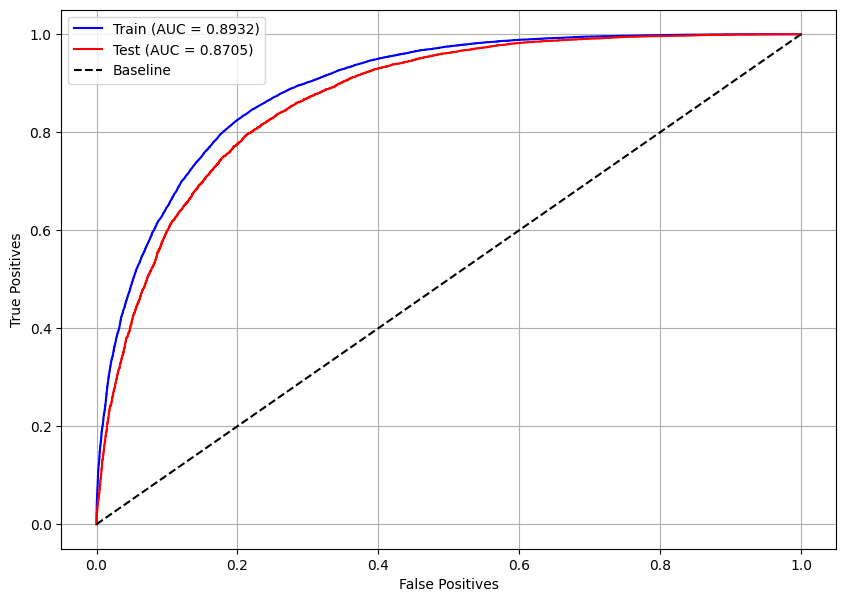

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm_cma, X_train, X_test, y_train, y_test)

**Optimized model**

In [ ]:
# Compare multiple LightGBM models and select the one with the highest test accuracy
models = [lgbm_rand, lgbm_tpe, lgbm_cma]  # List of trained models to evaluate
for i, m in enumerate(models):
    if i == 0:
        best = m  # Initialize the first model as the current best
    else:
        best_score = best.score(X_test, y_test)  # Accuracy of the current best model
        score = m.score(X_test, y_test)  # Accuracy of the model being evaluated
        if score > best_score:
            best = m  # Update 'best' if this model performs better

print(best)  # Output the model with the highest accuracy on the test set

LGBMClassifier(class_weight={0: 1.0528, 1: 1}, colsample_bytree=0.6,
               learning_rate=0.15, max_depth=10, min_child_weight=2,
               n_estimators=138, random_state=7, verbose=-1)


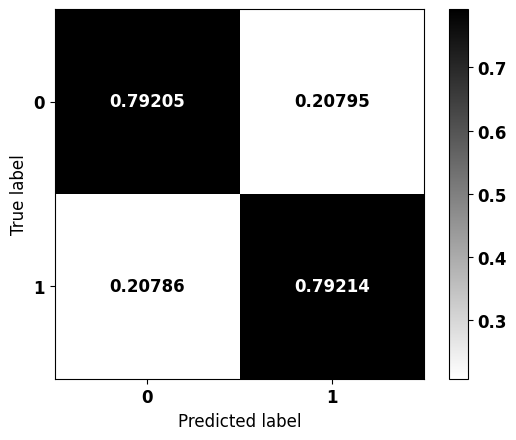


              precision    recall  f1-score   support

           0    0.81731   0.79205   0.80448     11325
           1    0.76441   0.79214   0.77803      9646

    accuracy                        0.79209     20971
   macro avg    0.79086   0.79210   0.79126     20971
weighted avg    0.79298   0.79209   0.79231     20971



In [ ]:
# Retrieve the hyperparameters from the selected best model
params = best.get_params()

# Initialize a new LightGBM classifier with those best hyperparameters
lgbm_optuna = LGBMClassifier(verbose=-1)
lgbm_optuna.set_params(**params)

# Train the optimized model on the training data
lgbm_optuna.fit(X_train, y_train)

# Plot the confusion matrix to evaluate the optimized model on the test data
plot_confusion_matrix(lgbm_optuna, X_test, y_test)

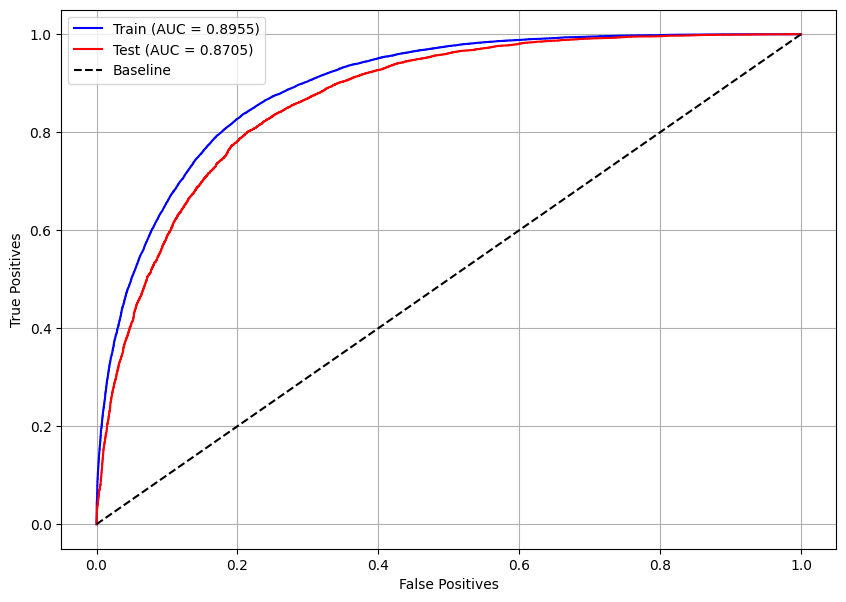

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(lgbm_optuna, X_train, X_test, y_train, y_test)

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


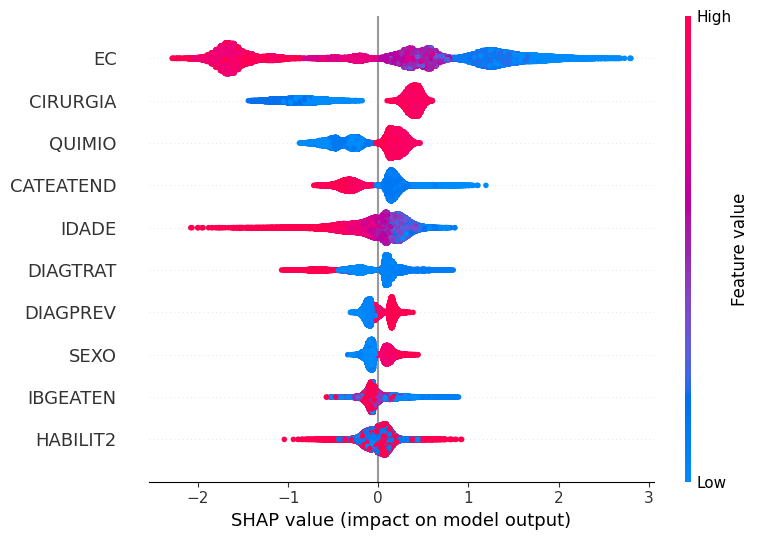

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(lgbm_optuna, X_train, feat_cols)

## **Cross Predictions**

In [ ]:
# Best Model Selection
models = [xgb, xgb_optuna, lgbm, lgbm_optuna]  # List of models to compare (XGBoost, optimized XGBoost, LightGBM, optimized LightGBM)

# Iterating through each model to find the best performing one
for i, m in enumerate(models):
    if i == 0:  # Initialize the best model as the first one
        best = m
    else:
        # Compare the performance of the current best model and the current model
        best_score = best.score(X_test, y_test)  # Get the accuracy of the current best model on the test set
        score = m.score(X_test, y_test)  # Get the accuracy of the current model on the test set
        if score > best_score:  # If the current model performs better, update the best model
            best = m

# Print the best performing model
print(best)

LGBMClassifier(class_weight={0: 1.0528, 1: 1}, colsample_bytree=0.6,
               learning_rate=0.15, max_depth=10, min_child_weight=2,
               n_estimators=138, random_state=7, verbose=-1)


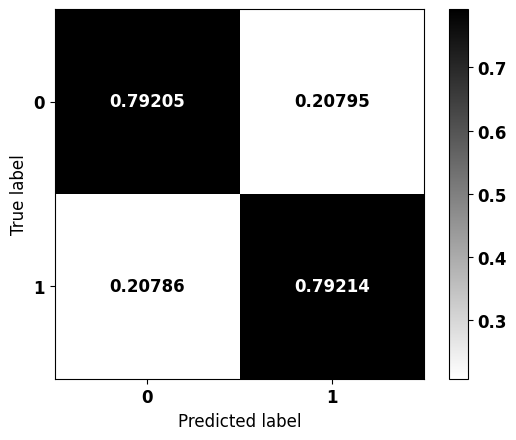


              precision    recall  f1-score   support

           0    0.81731   0.79205   0.80448     11325
           1    0.76441   0.79214   0.77803      9646

    accuracy                        0.79209     20971
   macro avg    0.79086   0.79210   0.79126     20971
weighted avg    0.79298   0.79209   0.79231     20971



In [ ]:
# Confusion Matrix for the Best Model
plot_confusion_matrix(best, X_test, y_test)  # Plot the normalized confusion matrix for the best model

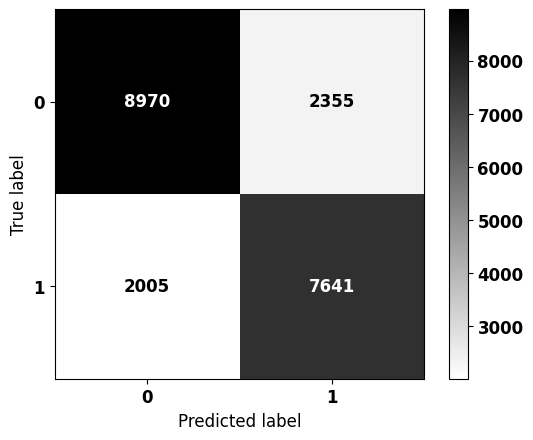


              precision    recall  f1-score   support

           0    0.81731   0.79205   0.80448     11325
           1    0.76441   0.79214   0.77803      9646

    accuracy                        0.79209     20971
   macro avg    0.79086   0.79210   0.79126     20971
weighted avg    0.79298   0.79209   0.79231     20971



In [ ]:
plot_confusion_matrix(best, X_test, y_test, norm=False)  # Plot the unnormalized confusion matrix for the best model

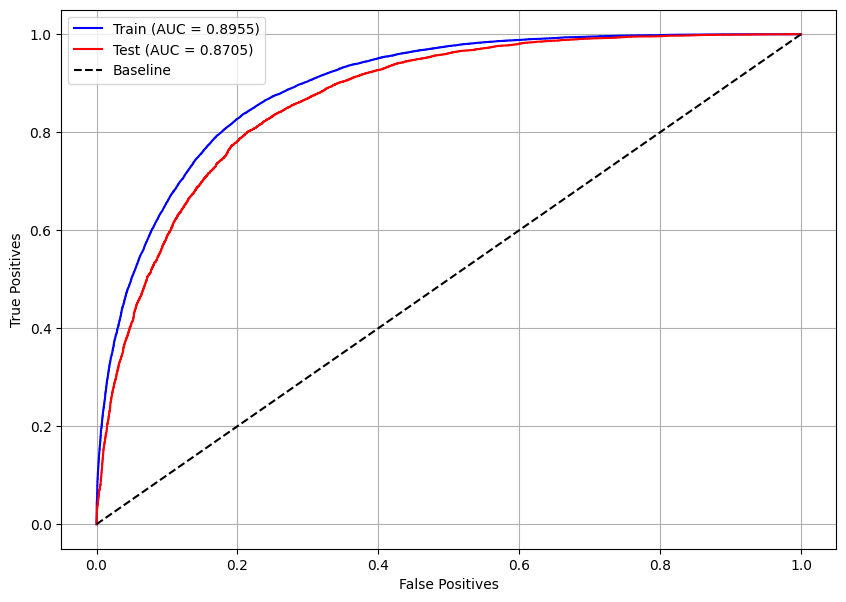

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(best, X_train, X_test, y_train, y_test)

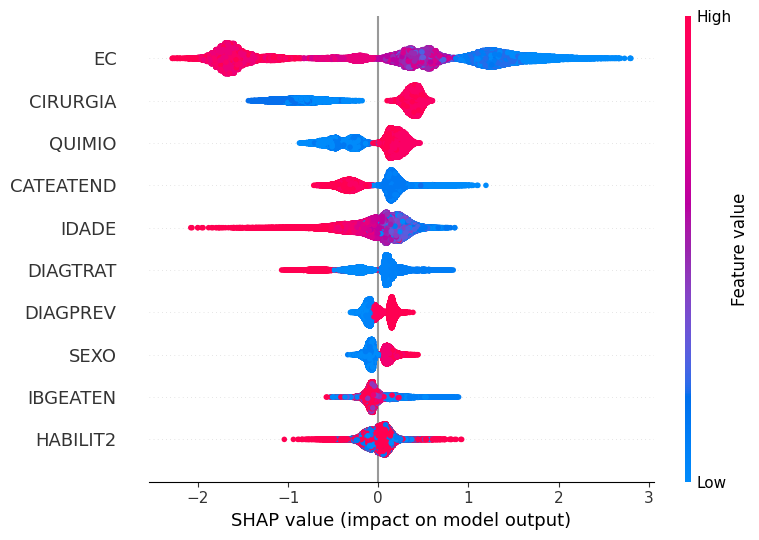

In [ ]:
# Feature importance using SHAP values
# Generate SHAP (SHapley Additive exPlanations) values to interpret
# the contribution of each feature to the XGBoost model’s predictions
plot_shap_values(best, X_train, feat_cols)

In [ ]:
# Prepare test features and target for Stomach Cancer
X_test_esto = esto_teste.drop(columns=list_drop).copy()  # Features for the Stomach cancer test set
y_test_esto = esto_teste.sobrevida_3anos.copy()          # Target variable (3-year survival) for the Stomach cancer test set

# Encode the 'TOPOGRUP' categorical column using the fitted OrdinalEncoder
X_test_esto['TOPOGRUP'] = oe.transform(X_test_esto[['TOPOGRUP']])

# Scale the encoded 'TOPOGRUP' values using the fitted StandardScaler
X_test_esto['TOPOGRUP'] = ss.transform(X_test_esto[['TOPOGRUP']])

# Prepare test features and target for Colorectal Cancer
X_test_colo = colo_teste.drop(columns=list_drop).copy()  # Features for the Colorectal cancer test set
y_test_colo = colo_teste.sobrevida_3anos.copy()          # Target variable (3-year survival) for the Colorectal cancer test set

# Encode the 'TOPOGRUP' categorical column using the fitted OrdinalEncoder
X_test_colo['TOPOGRUP'] = oe.transform(X_test_colo[['TOPOGRUP']])

# Scale the encoded 'TOPOGRUP' values using the fitted StandardScaler
X_test_colo['TOPOGRUP'] = ss.transform(X_test_colo[['TOPOGRUP']])

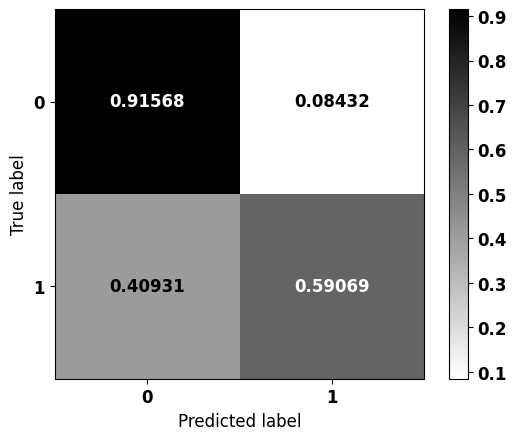


              precision    recall  f1-score   support

           0    0.85667   0.91568   0.88519      5052
           1    0.72391   0.59069   0.65055      1891

    accuracy                        0.82716      6943
   macro avg    0.79029   0.75318   0.76787      6943
weighted avg    0.82051   0.82716   0.82128      6943



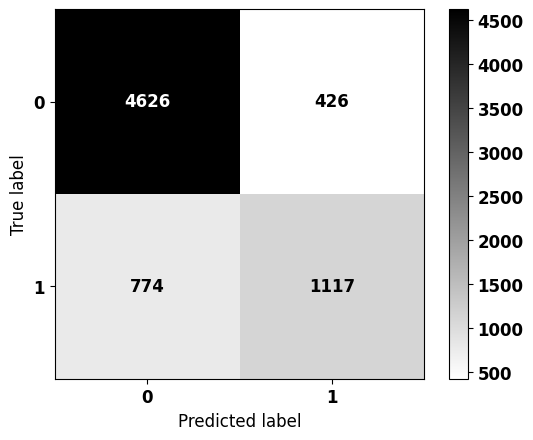


              precision    recall  f1-score   support

           0    0.85667   0.91568   0.88519      5052
           1    0.72391   0.59069   0.65055      1891

    accuracy                        0.82716      6943
   macro avg    0.79029   0.75318   0.76787      6943
weighted avg    0.82051   0.82716   0.82128      6943



In [ ]:
# Plot the normalized confusion matrix for the best model on the Stomach cancer test data
plot_confusion_matrix(best, X_test_esto, y_test_esto)

# Plot the raw (unnormalized) confusion matrix for the best model on the Stomach cancer test data
plot_confusion_matrix(best, X_test_esto, y_test_esto, norm=False)

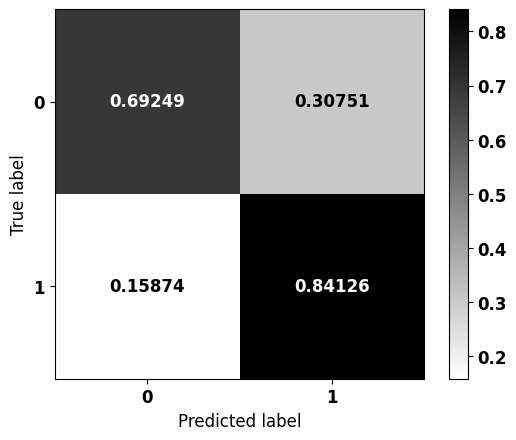


              precision    recall  f1-score   support

           0    0.77919   0.69249   0.73329      6273
           1    0.77180   0.84126   0.80503      7755

    accuracy                        0.77474     14028
   macro avg    0.77549   0.76688   0.76916     14028
weighted avg    0.77510   0.77474   0.77295     14028



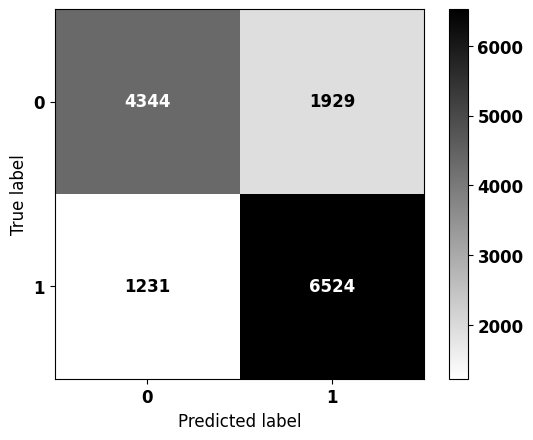


              precision    recall  f1-score   support

           0    0.77919   0.69249   0.73329      6273
           1    0.77180   0.84126   0.80503      7755

    accuracy                        0.77474     14028
   macro avg    0.77549   0.76688   0.76916     14028
weighted avg    0.77510   0.77474   0.77295     14028



In [ ]:
# Plot the normalized confusion matrix for the best model on the Colorectal cancer test data
plot_confusion_matrix(best, X_test_colo, y_test_colo)

# Plot the raw (unnormalized) confusion matrix for the best model on the Colorectal cancer test data
plot_confusion_matrix(best, X_test_colo, y_test_colo, norm=False)

## **Voting Classifier**


In [ ]:
# Comparing the accuracy scores of the initial XGBoost model and the optimized Optuna model
xgb_score = xgb.score(X_test, y_test)
optuna_score = xgb_optuna.score(X_test, y_test)
print(f'Accuracy: XGB = {xgb_score:.4f}, Optuna = {optuna_score:.4f}\n')

# Determine which model performed better
if optuna_score >= xgb_score:
    params_xgb = xgb_optuna.get_params()  # Get the parameters of the optimized model
    print('Optimized model won')
else:
    params_xgb = xgb.get_params()  # Get the parameters of the initial model
    print('Initial model won')

Accuracy: XGB = 0.7877, Optuna = 0.7910

Otimizado venceu


In [ ]:
# Comparing the accuracy scores of the initial LightGBM model and the optimized Optuna model
lgbm_score = lgbm.score(X_test, y_test)
optuna_score = lgbm_optuna.score(X_test, y_test)
print(f'Accuracy: LGBM = {lgbm_score:.4f}, Optuna = {optuna_score:.4f}\n')

# Determine which model performed better
if optuna_score >= lgbm_score:
    params_lgbm = lgbm_optuna.get_params()  # Get the parameters of the optimized model
    print('Optimized model won')
else:
    params_lgbm = lgbm.get_params()  # Get the parameters of the initial model
    print('Initial model won')

Accuracy: LGBM = 0.7882, Optuna = 0.7921

Otimizado venceu


In [ ]:
# Creating the models with the best-performing hyperparameters
# XGBoost Model
best_xgb = XGBClassifier()  # Instantiate the XGBoost classifier
best_xgb.set_params(**params_xgb)  # Set the best hyperparameters for XGBoost

# LightGBM Model
best_lgbm = LGBMClassifier()  # Instantiate the LightGBM classifier
best_lgbm.set_params(**params_lgbm)  # Set the best hyperparameters for LightGBM

LGBMClassifier(class_weight={0: 1.0528, 1: 1}, colsample_bytree=0.6,
               learning_rate=0.15, max_depth=10, min_child_weight=2,
               n_estimators=138, random_state=7, verbose=-1)

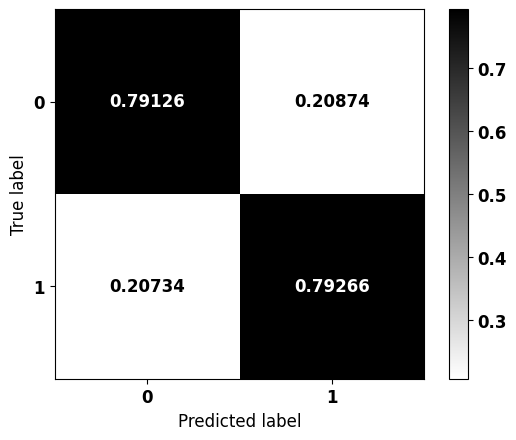


              precision    recall  f1-score   support

           0    0.81753   0.79126   0.80418     11325
           1    0.76384   0.79266   0.77798      9646

    accuracy                        0.79190     20971
   macro avg    0.79069   0.79196   0.79108     20971
weighted avg    0.79284   0.79190   0.79213     20971



In [ ]:
from sklearn.ensemble import VotingClassifier

# Creating and training the voting classifier model
clf = VotingClassifier(
    estimators=[('XGBoost', best_xgb),  # Adding the best XGBoost model
               ('LightGBM', best_lgbm)],  # Adding the best LightGBM model
    voting='soft'  # Using 'soft' voting, which predicts the class label based on predicted probabilities
)

clf.fit(X_train, y_train)  # Train the voting classifier on the training data

# Confusion Matrix
plot_confusion_matrix(clf, X_test, y_test)  # Plot the confusion matrix for the voting classifier on the test data

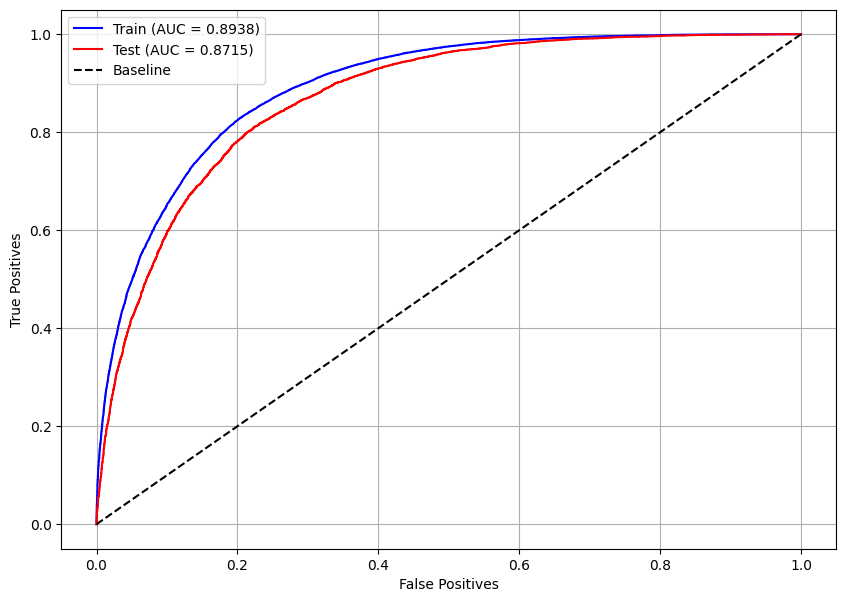

In [ ]:
# Plot the Receiver Operating Characteristic (ROC) curve to evaluate the classifier’s discrimination ability
# using both training and test data
plot_roc_curve(clf, X_train, X_test, y_train, y_test)